In [3]:
pathout = ".."

import sys
sys.path.append(pathout)
from TheModel import *

import functools as functool

## CHAOS ANALYSIS (onset of period doubling cascade)

In [7]:
########### Params for entire Notebook ############
epsi=.005
C=15
s=0.25
###################################################

alpha=.12
tmax=5*360
mmax=0


p = {
        'y0':[1-epsi,0,0,epsi,0,0,0,0,0,0,0],
        'beta': C*alpha,
        'alpha': alpha,
        'gamma': .1,
        'nu': .01,
        'tmin': 0,
        'tmax': tmax,
        'stepsize': 0.1,      
        'maxstep': 10,
        'direction': True,
        's': s,              # seasonality amplitude
        'w': 2*np.pi/360,        # seasonality frequency (repeats after every 360days)
        'seasonalshift': 0,
        'mmax': mmax, #0.845,
        'hthres': 2*1/1000,
        'epsilon_m': 2*0.00025, # =0.0005
        'tau': 36,
        'distinguishable': False,
    }

###############################
InInfComp = 'A and B' ######### 'A and B' or 'AB' Doesnt change much because we start at alpha=0.12 away from the basin boarder. Need lower tolerances though
###############################

In [ ]:
C = 15
epsi = .005

SetInCondfullSIRS(epsi, p, InInfComp)

################################# Endemic and Unstable Equilibrium for different C=15 ################################
#Analytical
alpha_EE, Rinf_unstEq, R_inf_endEq = np.load(pathout+f'/Symmetric Model (+s)/Data/DataSIRS_EE_analytical_C={C}.npy')
R0_EE = alpha_EE/0.1   # kappa = 1 in this data. Later can use this for all kappa, because kappa always cancels in R0 = alpha/gamma.
TheMask = R0_EE <= 1
######################################################################################################################

In [9]:
def SimulatePeaks(Peaks,cut,mmax,mmax_val_idx,p,max_attempts=7, tmax=40*360):
    attempts = 0
    while attempts <= max_attempts:
        try: 
            counter = 0
            m = model(**p)
            times, Data = m.run()
            S,A,B,AB,Ab,aB,a,b,ab,H,H1 = Data[:,cut:]

            if(np.all(np.array(S[-10:-1])==np.full(9,S[-1]))): 
                Peaks[mmax_val_idx, counter, 0] = mmax
                Peaks[mmax_val_idx, counter, 1] = 1-S[-1]
                counter += 1
            else:
                max_idces, _ = scp.signal.find_peaks(1-S)
                Rinf_maxvalues = set([f"{1-S[idx]:.3f}" for idx in max_idces]) # Only keep values that difer by at least 0.001 (if set to .2f) (set eliminates equal values)
                for Rinf in Rinf_maxvalues:
                    Peaks[mmax_val_idx, counter, 0] = mmax # mmax value is only assigned if there is a peak, else it stays at 0 and is not plotted later
                    Peaks[mmax_val_idx, counter, 1] = Rinf
                    counter += 1
            p['tmax'] = tmax
            #print(f"Success after {attempts+1} attempts at mmax={mmax}")
            return counter
        except RuntimeError as errormessage: # try again with 20yrs more if it fails
            attempts += 1
            print("at mmax=",mmax,"ERROR:", errormessage)
            p['tmax'] += 20*360
            print(f"Trying longer tmax={p['tmax']/360} yrs instead...")
            pass
    
    print('at mmax=',mmax,'MAX NUMBER OF TMAX INCREASE REACHED')
    return counter

def FindPDOnsets(fraction, C_values, mmax_values, p, max_attempts=7, tmax=40*360, HeatmapLabel=False):

    for k in range(len(fraction)):
        Peakcounter = np.zeros((len(C_values),len(mmax_values)))
        for i,C in enumerate(C_values):


            ############### check if already have Data for this kappa,C combination:#############
            try:
                Peaks_trimmed = np.load(f'Data_PDOnset/DataSIRSsm_Peaks_kappa={fraction[k]}_C={C}_thresh=e-3_tmax={int(tmax/360)}yrs.npy')
                Peakcounter[i,:] = np.count_nonzero(Peaks_trimmed[:,:,0], axis=1)
                print('Found existing data for kappa=',fraction[k],', C=',C)
            except FileNotFoundError:
                # if not done already simulate:
                Peaks = np.zeros((len(mmax_values),200,2))
                
                p['gamma'] = .1/fraction[k]
                p['alpha'] = .12/fraction[k]
                p['nu'] = .01/fraction[k]
                p['beta'] = C*.12/fraction[k]
                p['tmax'] = tmax
                cut = int(p['tmax']/p['stepsize']*7/10)

                for mmax_val_idx, mmax in enumerate(mmax_values):
                    p['mmax'] = mmax

                    SetTolerances_for_kappa_mmax(mmax, fraction[k], p)
                    
                    counter = SimulatePeaks(Peaks,cut,mmax,mmax_val_idx,p,max_attempts=max_attempts, tmax=tmax)
                    Peakcounter[i,mmax_val_idx] = counter
                    p['tolerances'] = [1e-10,1e-13]
                #if(counter>Counter_Max): Counter_Max = counter
                #if(mmax_val_idx % 10 == 0): print(mmax_val_idx//10+1,'/',10)
                mask = np.any(Peaks[:,:,0] != 0, axis=0) #search if any values in first dim are nonzero 
                max_idx = np.max(np.where(mask)) + 1 # the max index in the second dim where this is true 
                Peaks_trimmed = Peaks[:, :max_idx, :]                                                  
                np.save(f'Data_PDOnset/DataSIRSsm_Peaks_kappa={fraction[k]}_C={C}_thresh=e-3_tmax={int(tmax/360)}yrs.npy', Peaks_trimmed)
            ###############################################################################################################################
            print(i+1,'/',len(C_values))
        if HeatmapLabel: HeatmapLabel = 'Heatmap'
        else: HeatmapLabel = ''
        np.save(f'Data_PDOnset/DataSIRSsm_Peakcounter{HeatmapLabel}_kappa={fraction[k]}_thresh=e-3_tmax={int(tmax/360)}yrs.npy', Peakcounter)
        print('>>>',k+1,'/',len(fraction))
    return Peakcounter, Peaks_trimmed # return last arrays in case simulation broke down and these were not saved

# # check that the trimming works as intended
# Peaks = np.array([[[1,1],[1,1],[1,1],[1,1],[0,0],[0,0]],[[1,1],[1,1],[1,1],[0,0],[0,0],[0,0]],[[1,1],[1,1],[1,1],[0,0],[0,0],[0,0]],[[1,1],[1,1],[1,1],[1,1],[0,0],[0,0]],[[1,1],[1,1],[1,1],[0,0],[0,0],[0,0]]])

# mask = np.any(Peaks[:,:,0] != 0, axis=0) #search if any values in first dim are nonzero 
# print(mask)
# max_idx = np.max(np.where(mask)) + 1 # the max index in the second dim where this is true 
# print(max_idx)
# Peaks_trimmed = Peaks[:, :max_idx, :]
# print(Peaks_trimmed)
    
    # NEXT: MAKE SIMUL STOP AFTER IT FOUND THE ONSET

In [20]:
# check trajectories themselves

def PlotTrajectories(ax, p, mmax_list, kappa, C, tmax=None, LEGEND=True, cut_input=None, COL_list=None):

    ZOrderParamList = [[0.2,2,0.6], [0.2,5,0.98], [0.2,15,0.85], [0.2,25,0.75], [0.35,2,.9]] # ParamComb (kappa, C, mmax) showing chaos so we want to plot at low zorder to not cover the other traj

    alpha_EE, Rinf_unstEq, R_inf_endEq = np.load(pathout+f'/Symmetric Model (+s)/Data/DataSIRS_EE_analytical_C={C}.npy')
    R0_EE = alpha_EE/0.1   # kappa = 1 in this data. Later can use this for all kappa, because kappa always cancels in R0 = alpha/gamma.
    TheMask = R0_EE <= 1

    ax.plot(R0_EE, R_inf_endEq, ls='-', c='k', label='stab. EE')
    ax.plot(R0_EE[TheMask], Rinf_unstEq[TheMask], ls='--', c='r', label='unst. EE')

    for mmax_idx, mmax in enumerate(mmax_list): # plot the chaotic ones first (take more space in the plot)
        if(mmax==None): continue

        p['gamma'] = .1/kappa
        p['alpha'] = .12/kappa # alpha_crit/kappa
        p['nu'] = .01/kappa
        p['beta'] = C*.12/kappa # C*alpha_crit/kappa
        p['mmax'] = mmax

        
        if(isinstance(tmax, int)): p['tmax'] = tmax
        elif(isinstance(tmax, list)): p['tmax'] = tmax[mmax_idx]
        elif(tmax == None): p['tmax'] = 40*360
        else: raise ValueError("tmax must be None, int or list")

        if(isinstance(cut_input, int) or isinstance(cut_input, float)): cut = int(cut_input)
        elif(isinstance(cut_input, np.ndarray)): cut = int(cut_input[mmax_idx])
        elif(cut_input == None): cut = int(p['tmax']/p['stepsize']*7/10)
        else: raise ValueError("cut_input must be None, int, float or ndarray")

        SetTolerances_for_kappa_mmax(mmax, kappa, p)
        
        while True:
            try:
                m = model(**p)
                times, Data = m.run()
                times = times[cut:]
                S,A,B,AB,Ab,aB,a,b,ab,H,H1 = Data[:,cut:]
                SF = m.seasonalforcing(times)
                SoftPlus = 1 - mmax * m.m_normalized(H)   

                ax.plot(p['alpha'] * SoftPlus*SF/p['gamma'], 1 - S, label=r'$m_{\rm max}=$'+f'{mmax}', zorder = 0 if [kappa, C, mmax] in ZOrderParamList else 1, lw = 1.5, c=COL_list[mmax_idx] if COL_list is not None else None)

                p['tmax'] = 40*360 #reset
                break
            except RuntimeError as errormessage: # try again with 20yrs more if it fails
                print("at mmax=",mmax,"ERROR:", errormessage)
                p['tmax'] += 20*360
                print(f"Trying longer tmax={p['tmax']/360} yrs instead...")
                pass

        print(f"Finished mmax={mmax}")

    # plt.ylim(-.02,max(R_inf_PT)+.02)
    ax.scatter(p['alpha']/p['gamma'], epsi, marker='x', c='k', label=r'($R_0^{\rm ref}$,$\epsilon$)')
    ax.set_xlabel(r'$R_t$') # = R_0 \cdot (1-m(H))\Gamma(t)$')
    if(LEGEND == True): ax.legend()
    #ax.set_title('Phase space trajectories') #rf'$\kappa={kappa}$, $C={C}$')
    ax.set_ylim(0,1)
    ax.set_xlim(0,1.7)
    ax.set_xticks([0.5,1,1.5])
    ax.set_yticks([0,0.2,0.4,0.6,0.8,1])
    p['tmax'] = 40*360

### Check some C values to optimize thresh=1e-3, $t_{\rm max}=$200yrs and Chaosthresh=20,33

In [11]:
########## Fixed Lists for entire section ! ############
mmax_values = np.linspace(0.1,1,100)
C_values = [1,2,5,8,10,15,25,50,100] # important to leave as is, because its how Data of Peakcounter[i,:] was generated. Only then i,C in enumerate(C_values) gives correct values

In [13]:
fraction = [0.2,0.3,0.35,0.4,1]
_ = FindPDOnsets(fraction, C_values, mmax_values, p, tmax=200*360)
# if plots show mismatch between peaknumber and bifurcation curve: Run this again

Found existing data for kappa= 0.2 , C= 1
1 / 7
Found existing data for kappa= 0.2 , C= 2
2 / 7
Found existing data for kappa= 0.2 , C= 5
3 / 7
Found existing data for kappa= 0.2 , C= 15
4 / 7
Found existing data for kappa= 0.2 , C= 25
5 / 7
Found existing data for kappa= 0.2 , C= 50
6 / 7
Found existing data for kappa= 0.2 , C= 100
7 / 7
>>> 1 / 5
Found existing data for kappa= 0.3 , C= 1
1 / 7
Found existing data for kappa= 0.3 , C= 2
2 / 7
Found existing data for kappa= 0.3 , C= 5
3 / 7
Found existing data for kappa= 0.3 , C= 15
4 / 7
Found existing data for kappa= 0.3 , C= 25
5 / 7
Found existing data for kappa= 0.3 , C= 50
6 / 7
Found existing data for kappa= 0.3 , C= 100
7 / 7
>>> 2 / 5
Found existing data for kappa= 0.35 , C= 1
1 / 7
Found existing data for kappa= 0.35 , C= 2
2 / 7
Found existing data for kappa= 0.35 , C= 5
3 / 7
Found existing data for kappa= 0.35 , C= 15
4 / 7
Found existing data for kappa= 0.35 , C= 25
5 / 7
Found existing data for kappa= 0.35 , C= 50
6 / 7
F

Finished mmax=0.2
Finished mmax=0.5
Finished mmax=0.61
tolerances lowered for kappa = 0.2 and mmax = 0.9


C:\Users\Rodrigo Amaral Lind\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\integrate\_ivp\ivp.py:621: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


Finished mmax=0.9


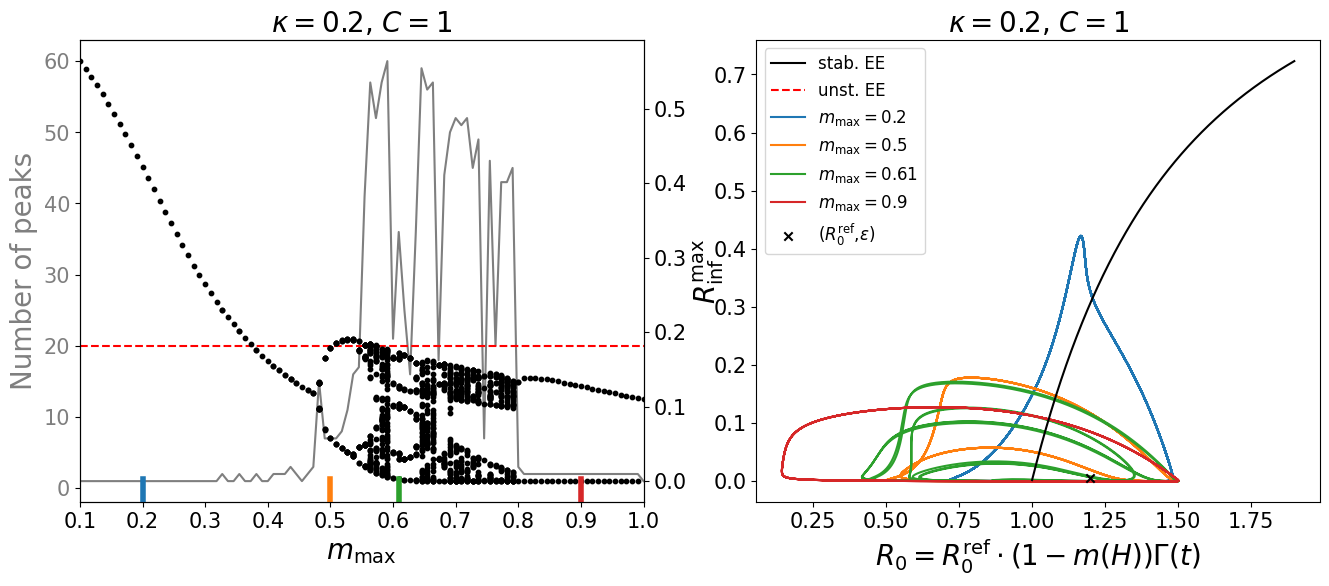

Finished mmax=0.2
Finished mmax=0.5
Finished mmax=0.6
tolerances lowered for kappa = 0.2 and mmax = 0.9
Finished mmax=0.9


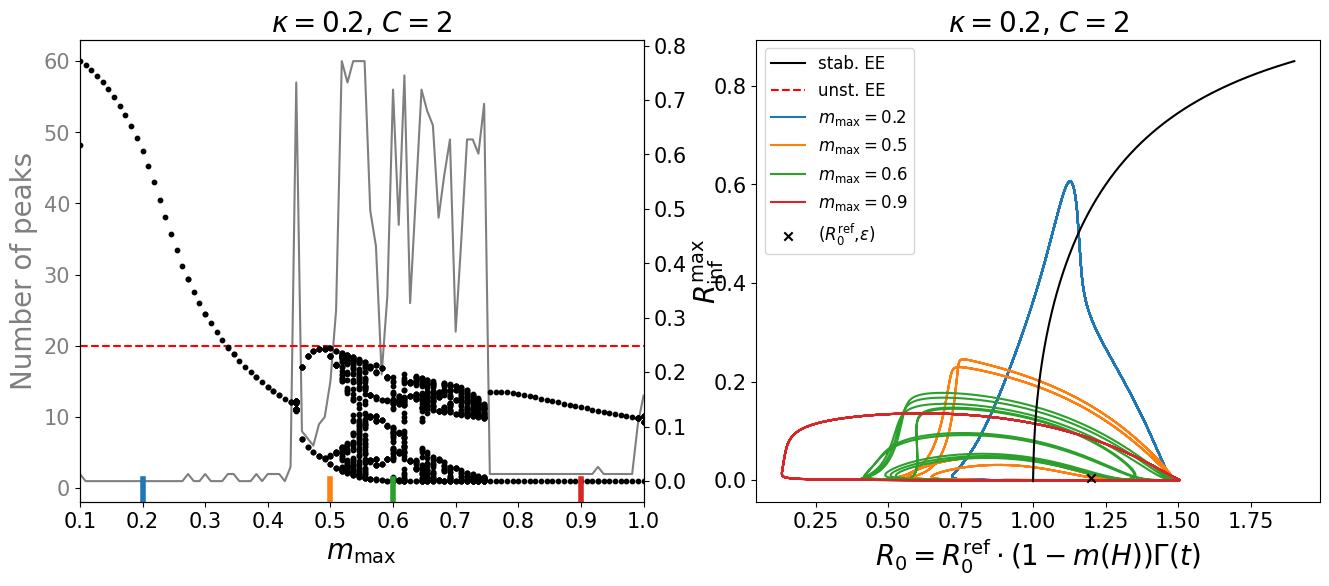

Finished mmax=0.2
Finished mmax=0.4
Finished mmax=0.55
Finished mmax=0.7
tolerances lowered for kappa = 0.2 and mmax = 1
at mmax= 1 ERROR: Solver stopped due to negative population.
Trying longer tmax=60.0 yrs instead...
at mmax= 1 ERROR: Solver stopped due to negative population.
Trying longer tmax=80.0 yrs instead...
at mmax= 1 ERROR: Solver stopped due to negative population.
Trying longer tmax=100.0 yrs instead...
Finished mmax=1


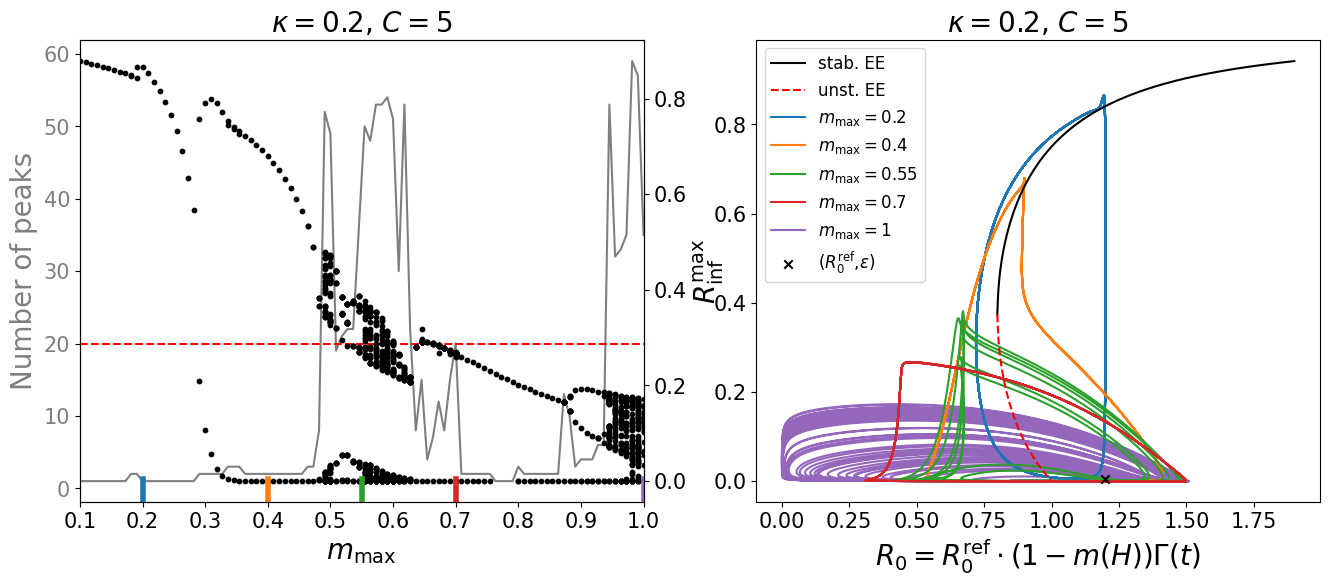

Finished mmax=0.4
Finished mmax=0.6
at mmax= 0.7 ERROR: Solver stopped due to negative population.
Trying longer tmax=60.0 yrs instead...
at mmax= 0.7 ERROR: Solver stopped due to negative population.
Trying longer tmax=80.0 yrs instead...
Finished mmax=0.7
tolerances lowered for kappa = 0.2 and mmax = 0.9
Finished mmax=0.9


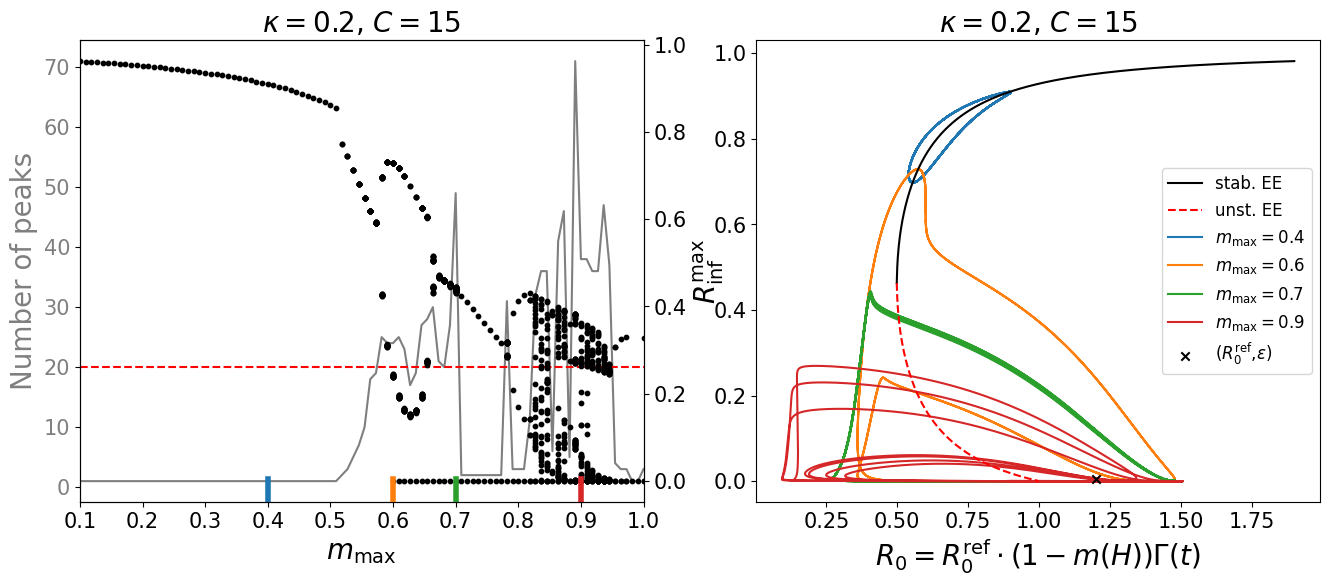

Finished mmax=0.4
tolerances lowered for kappa = 0.2 and mmax = 0.75
Finished mmax=0.75
tolerances lowered for kappa = 0.2 and mmax = 0.89
at mmax= 0.89 ERROR: Solver stopped due to negative population.
Trying longer tmax=60.0 yrs instead...
Finished mmax=0.89
tolerances lowered for kappa = 0.2 and mmax = 0.95
Finished mmax=0.95


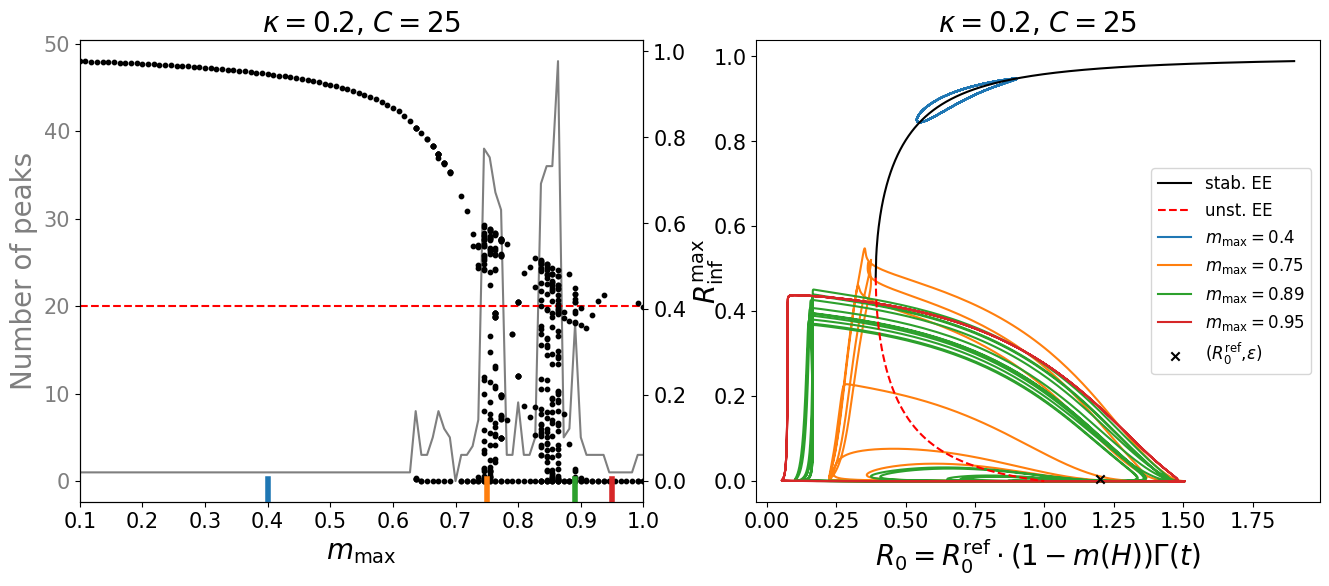

Finished mmax=0.6
tolerances lowered for kappa = 0.2 and mmax = 0.85
at mmax= 0.85 ERROR: Solver stopped due to negative population.
Trying longer tmax=60.0 yrs instead...
Finished mmax=0.85
tolerances lowered for kappa = 0.2 and mmax = 0.95
Finished mmax=0.95


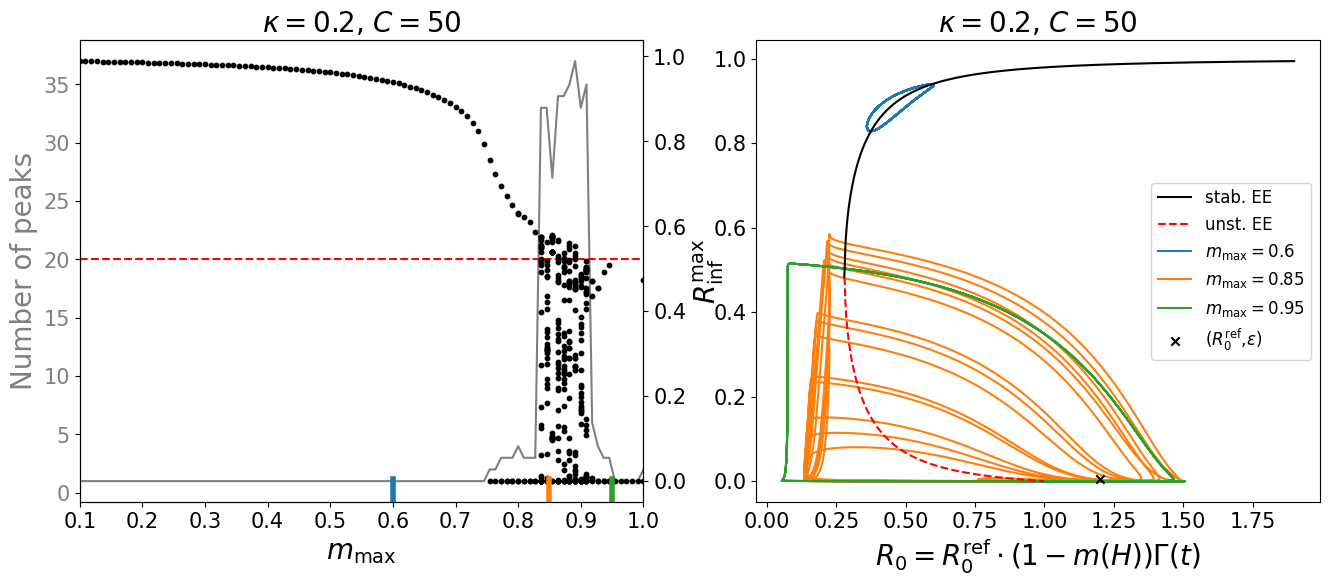

Finished mmax=0.6
tolerances lowered for kappa = 0.2 and mmax = 0.85
Finished mmax=0.85
tolerances lowered for kappa = 0.2 and mmax = 0.9
Finished mmax=0.9
tolerances lowered for kappa = 0.2 and mmax = 0.92
Finished mmax=0.92


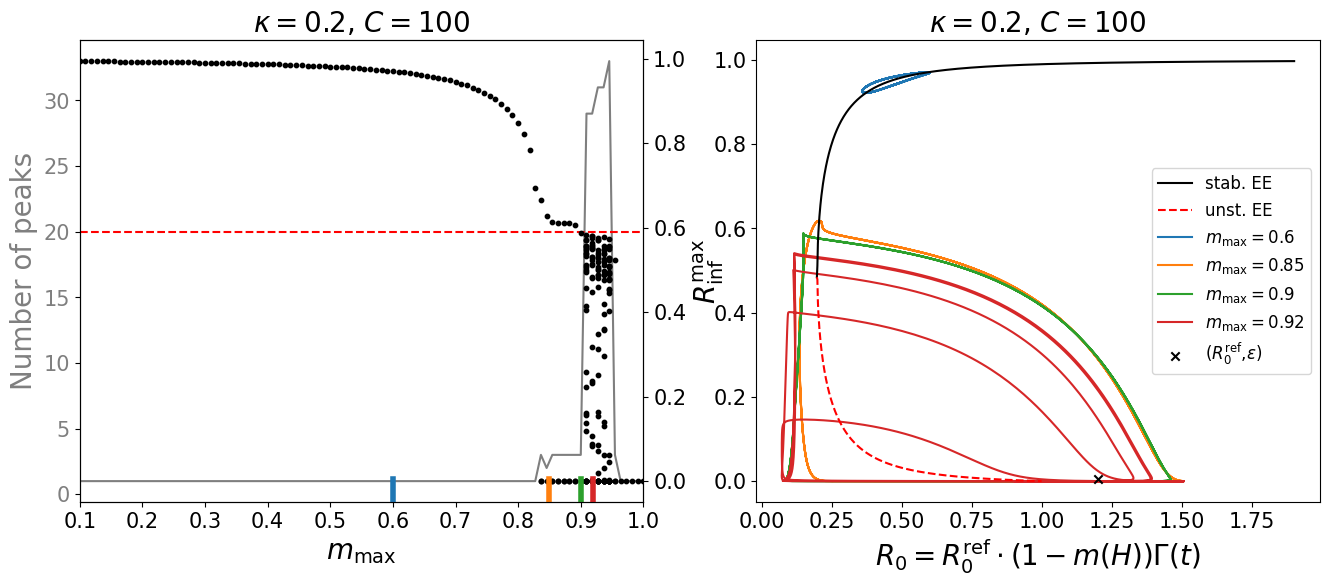

Finished mmax=0.2
Finished mmax=0.5
Finished mmax=0.7
Finished mmax=0.9


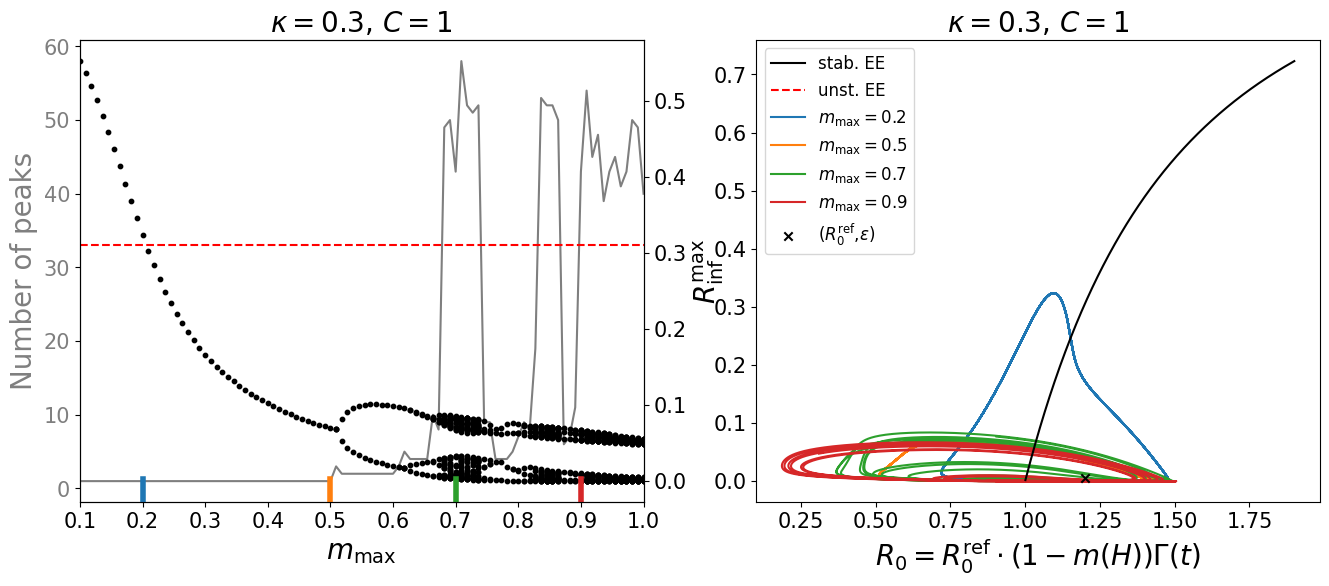

Finished mmax=0.2
Finished mmax=0.5
Finished mmax=0.7
Finished mmax=0.87
Finished mmax=0.9


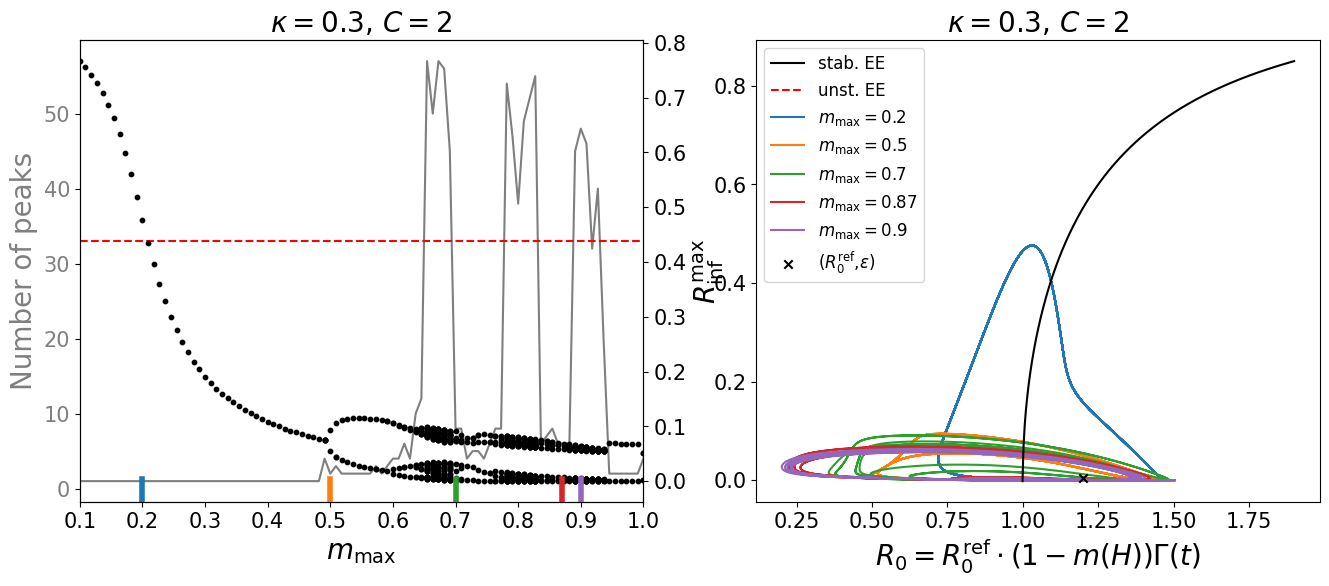

Finished mmax=0.2
Finished mmax=0.4
Finished mmax=0.58
Finished mmax=0.64
tolerances lowered for kappa = 0.3 and mmax = 1
Finished mmax=1


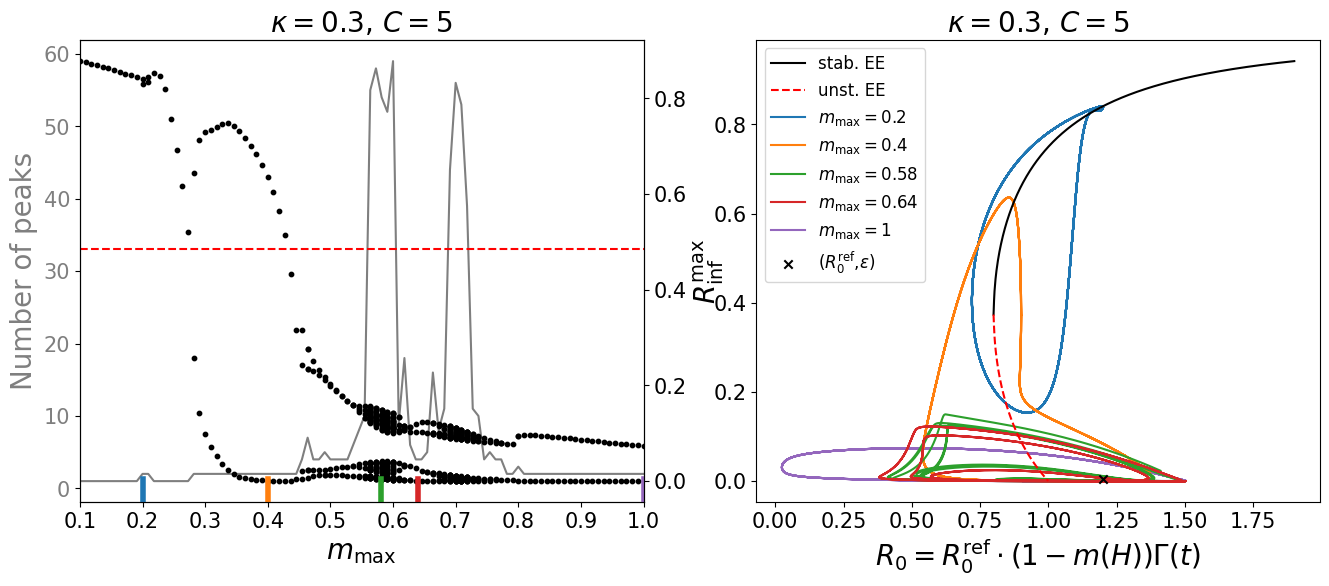

Finished mmax=0.4
Finished mmax=0.6
Finished mmax=0.7
tolerances lowered for kappa = 0.3 and mmax = 0.97
Finished mmax=0.97


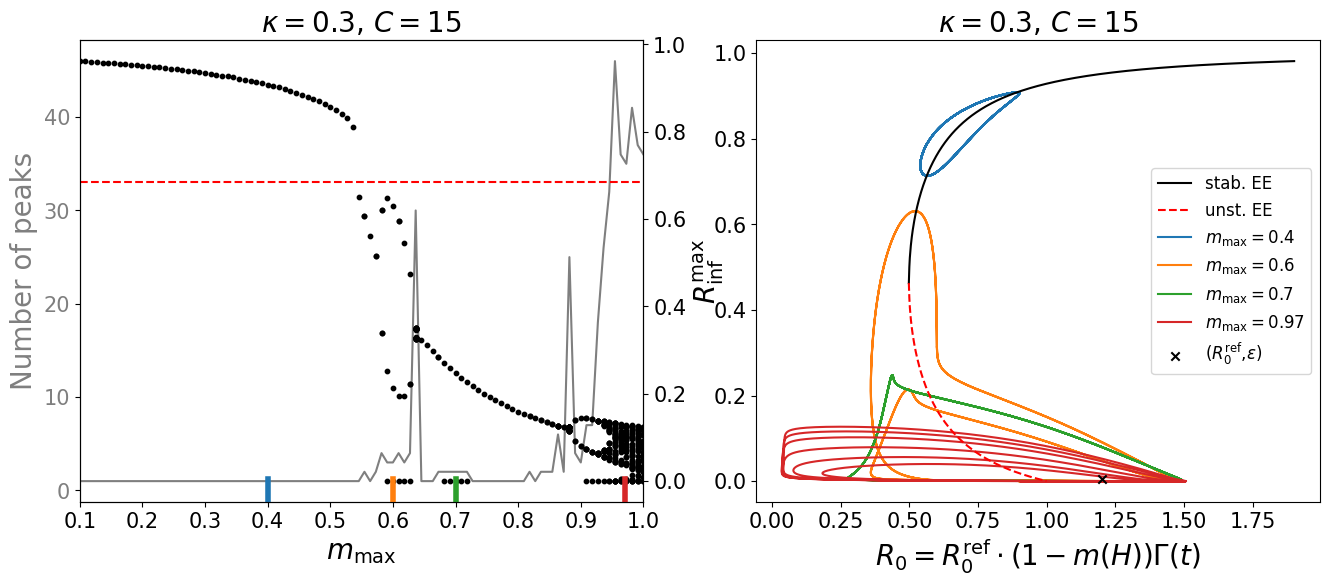

Finished mmax=0.4
Finished mmax=0.67
Finished mmax=0.8
Finished mmax=0.9


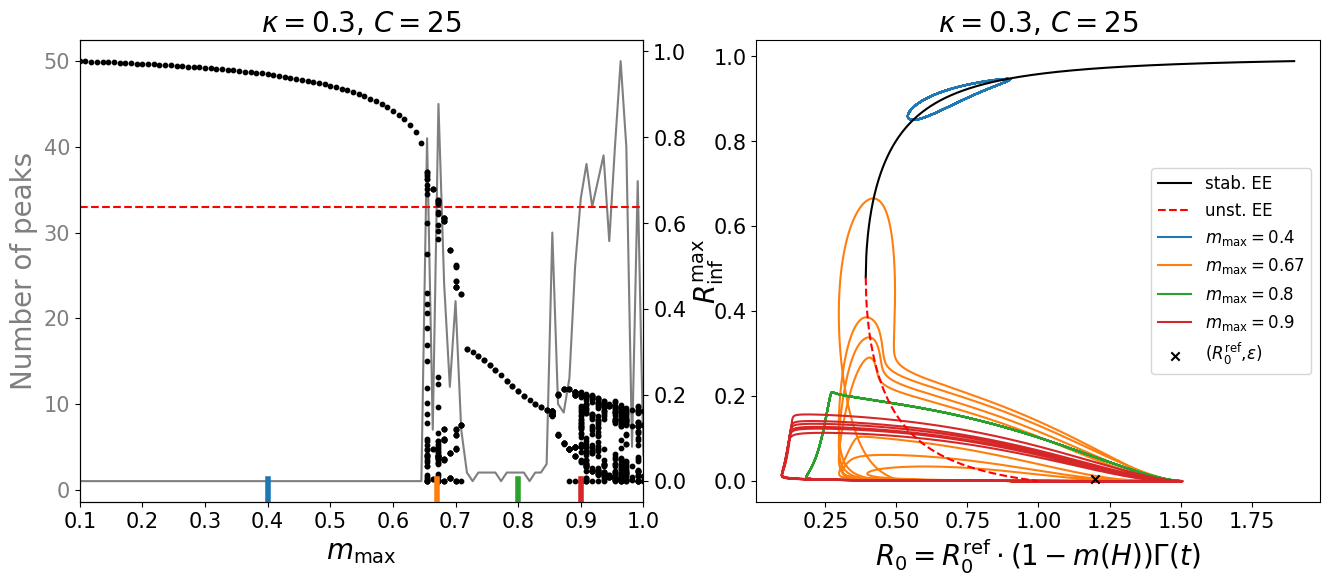

Finished mmax=0.6
Finished mmax=0.78
Finished mmax=0.95


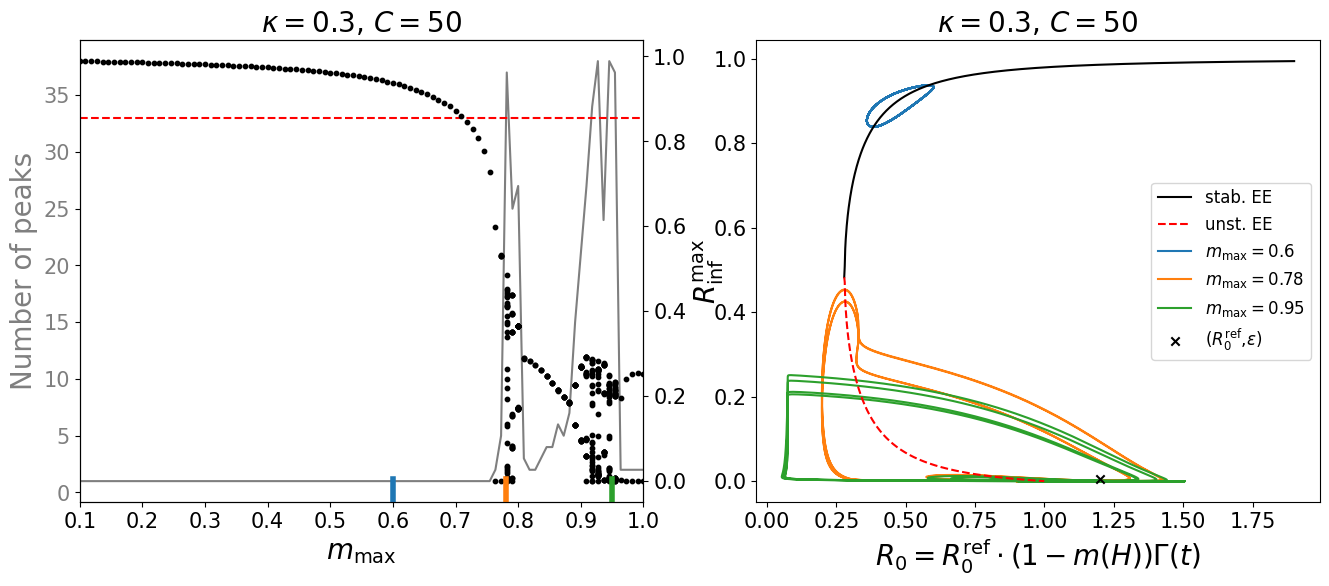

Finished mmax=0.6
Finished mmax=0.86
Finished mmax=0.9
tolerances lowered for kappa = 0.3 and mmax = 1
Finished mmax=1


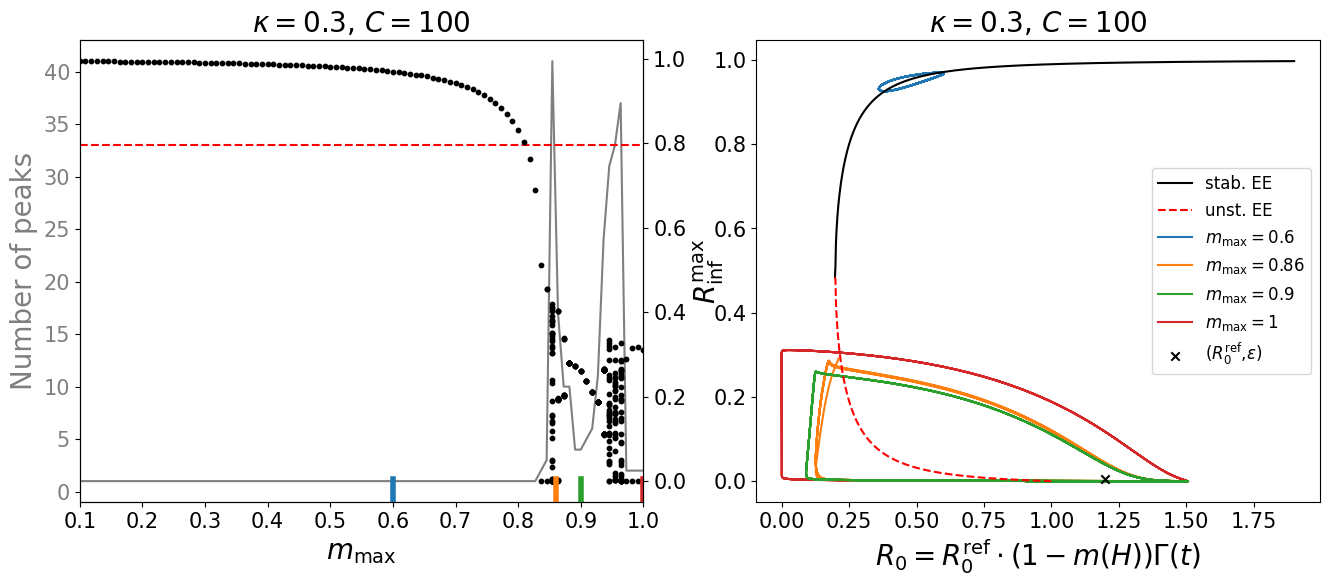

Finished mmax=0.2
Finished mmax=0.8


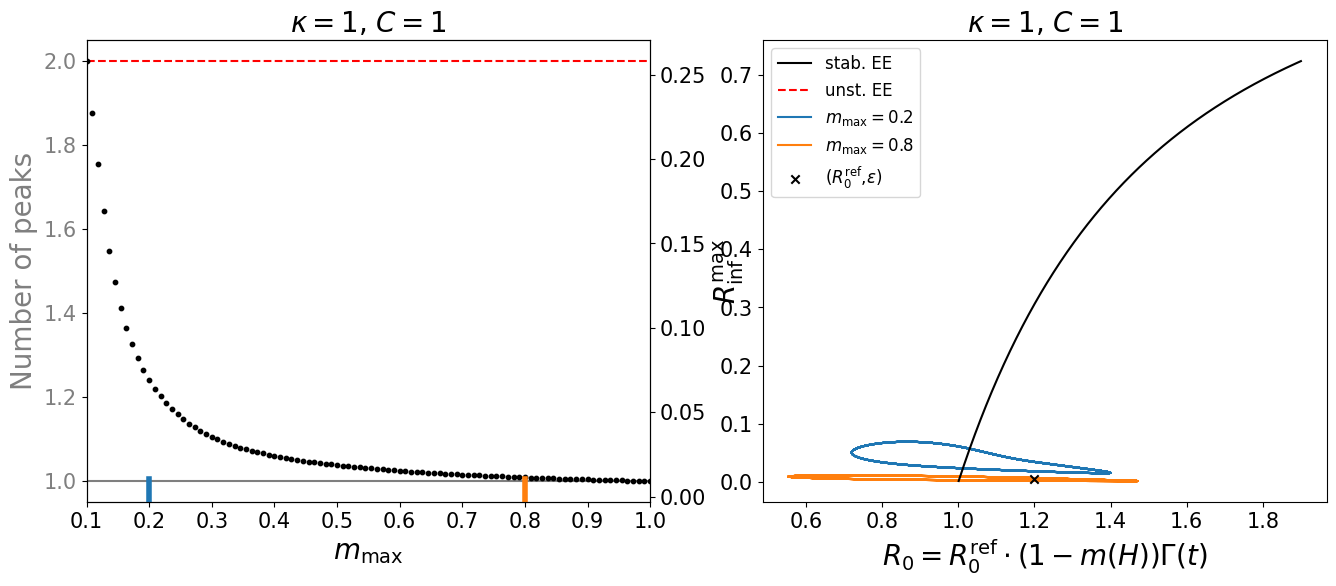

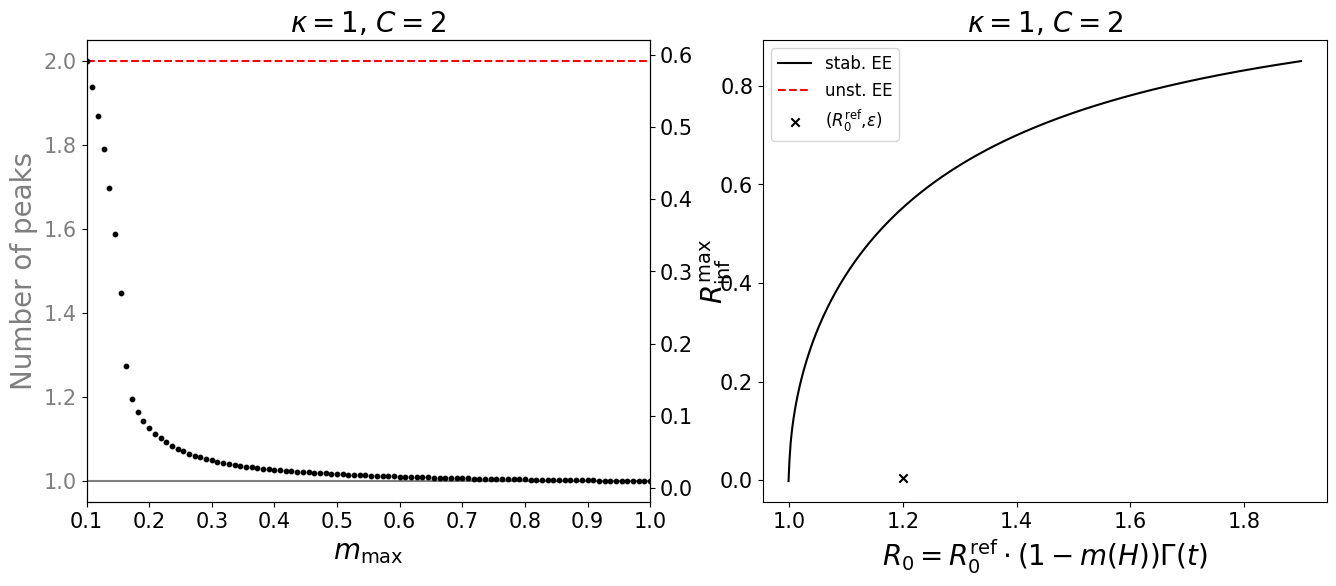

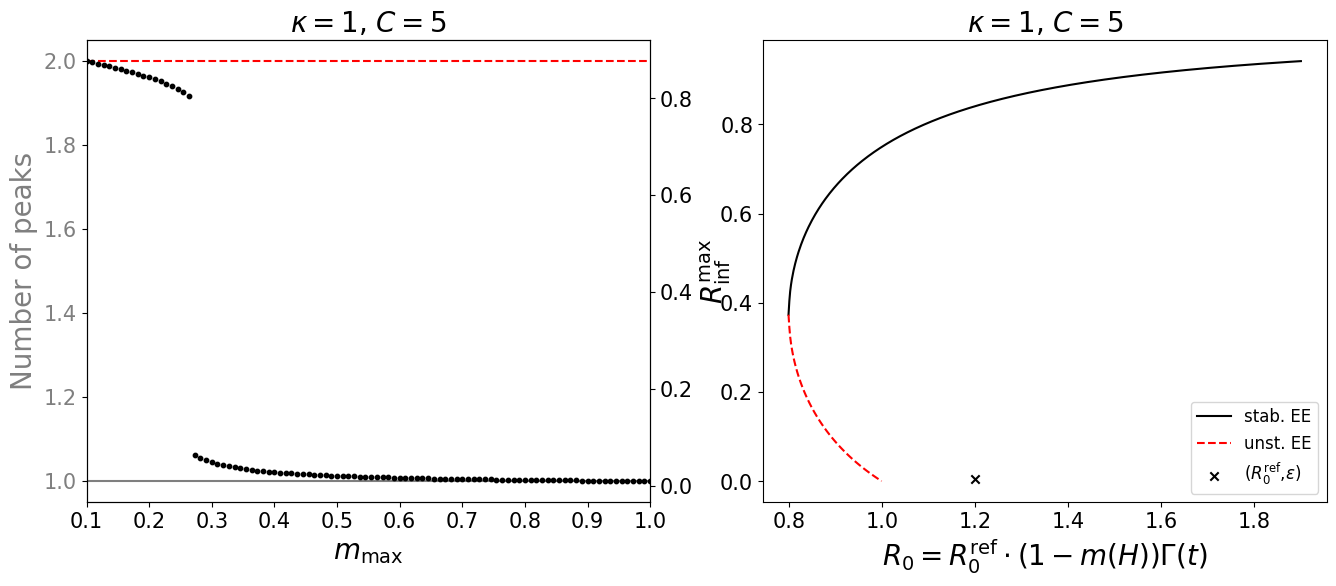

Finished mmax=0.2
Finished mmax=0.8


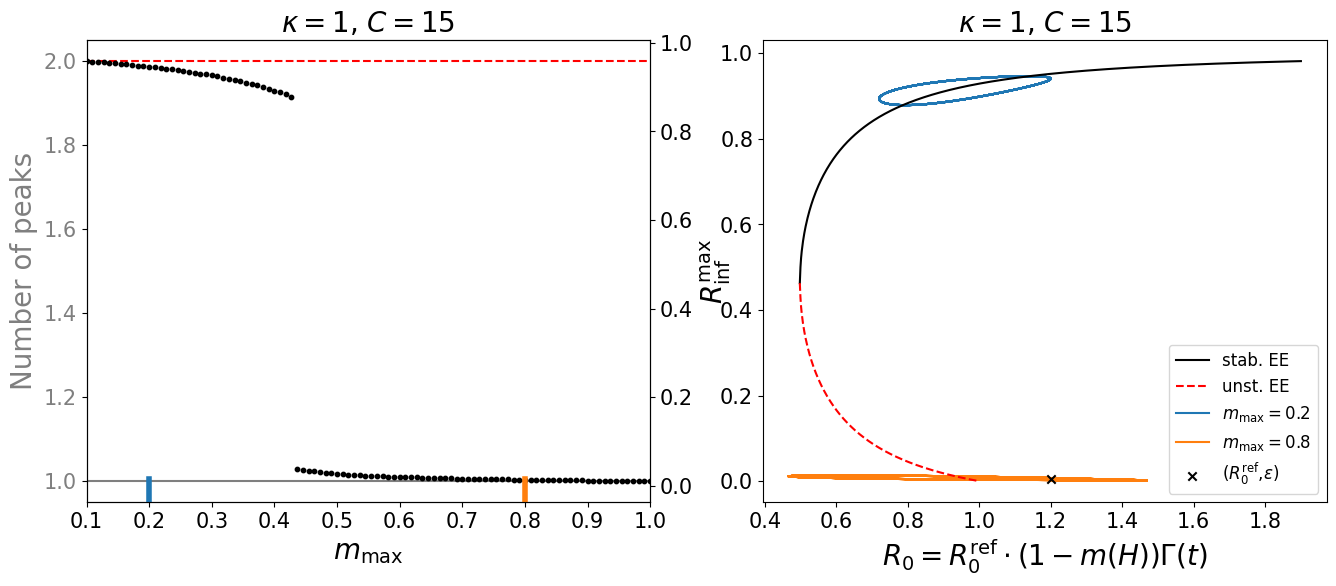

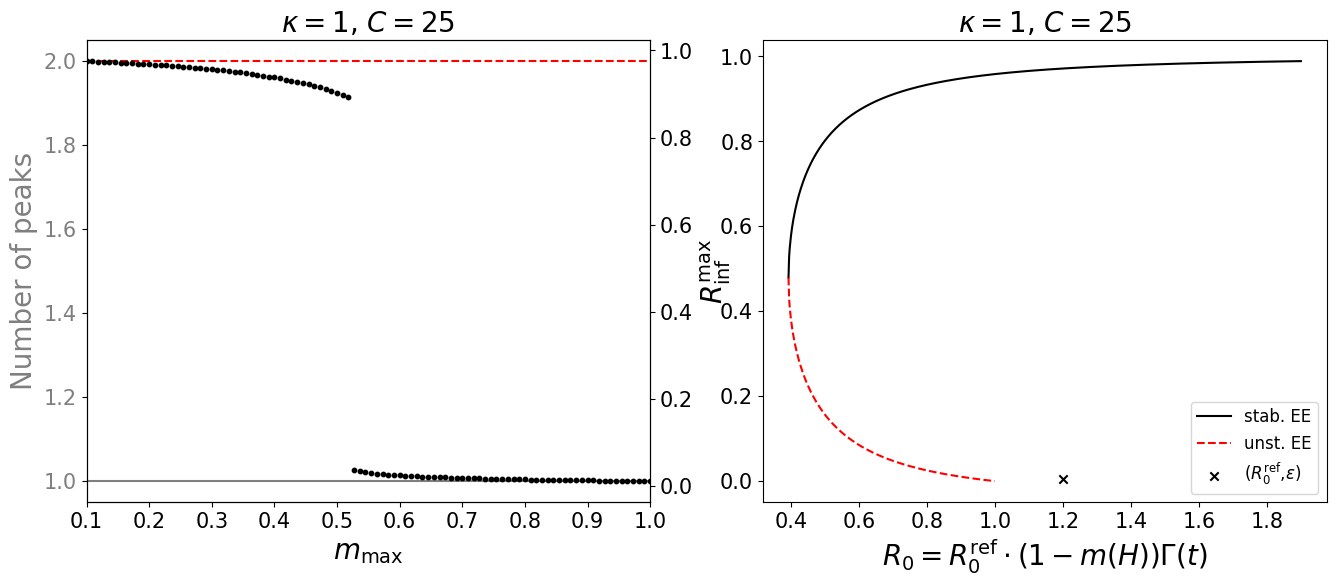

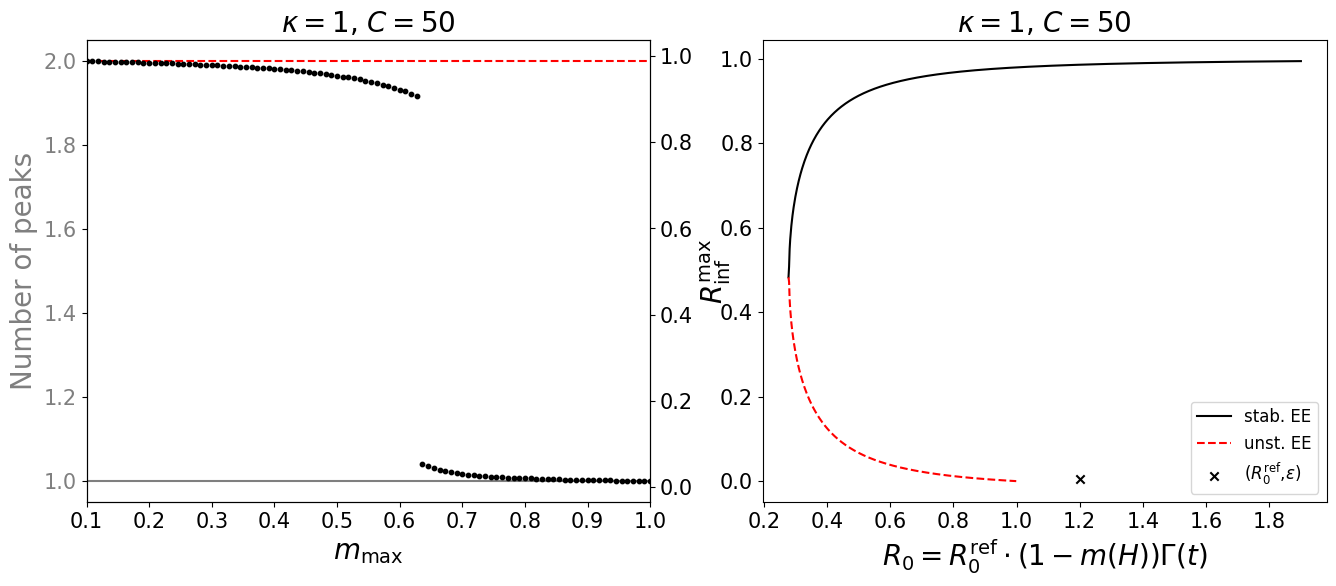

Finished mmax=0.2
Finished mmax=0.8


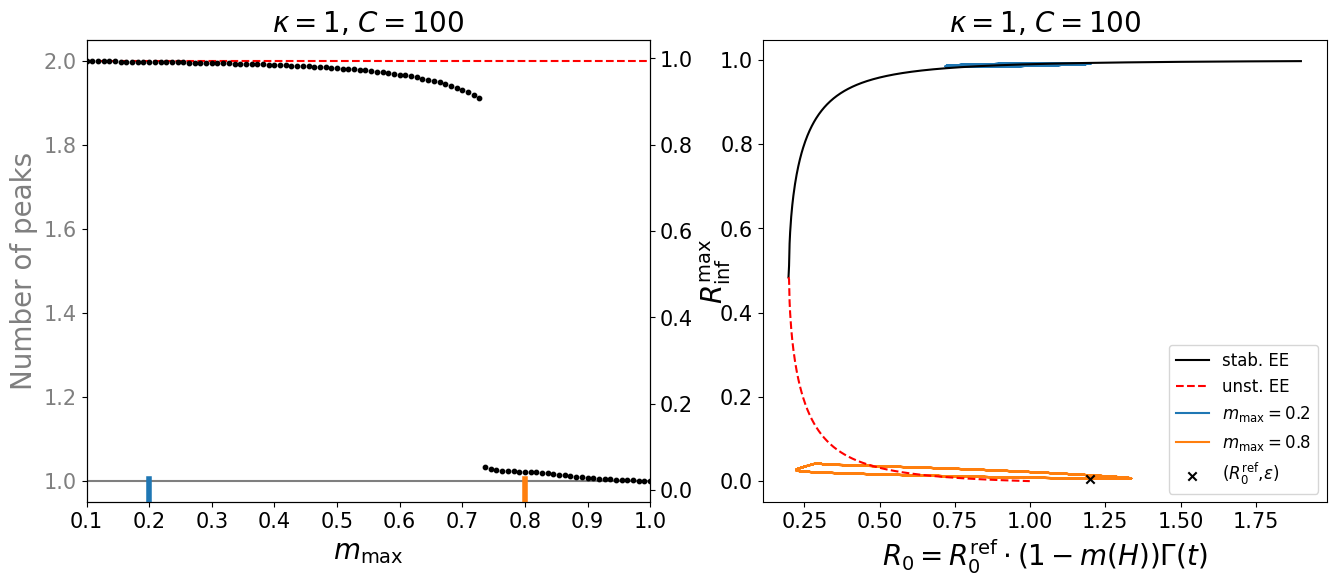

In [ ]:
# Old: thresh=e-4

fraction = [0.2,0.3,1] # add fractions after they have been simulated
C_values_old = [1,2,5,15,25,50,100]

mmax_list = [[[.2,.5,.61,.9], [.2,.5,.6,.9], [0.2,0.4,0.55,0.7,1], [.4,.6,.7,.9], [.4,.75,.89,.95], [.6,.85,.95], [.6,.85,.9,.92]],
            [[.2,.5,.7,.9], [.2,.5,.7,.87,.9], [0.2,0.4,0.58,0.64,1], [.4,.6,.7,.97], [.4,.67,.8,.9], [.6,.78,.95], [.6,.86,.9,1]],
            [[.2,.8], [None,None], [None,None], [.2,.8], [None,None], [None,None], [.2,.8]]
             ]

ChaosThresh = [20,33,2]

COL = plt.rcParams['axes.prop_cycle'].by_key()['color'][:]
color_leftaxis = 'tab:grey'

for k in range(len(fraction)):
    Peakcounter = np.load(f'Data_PDOnset/DataSIRSsm_Peakcounter_kappa={fraction[k]}_thresh=e-4_tmax=200yrs.npy')
    
    for i,C in enumerate(C_values_old):
        fig, ax = plt.subplots(1, 2, figsize=(16, 6))

        Peaks = np.load(f'Data_PDOnset/DataSIRSsm_Peaks_kappa={fraction[k]}_C={C}_thresh=e-4_tmax=200yrs.npy')
        ax[0].plot(mmax_values, Peakcounter[i,:], label=f'C={C}',c=color_leftaxis)
        ax[0].axhline(y=ChaosThresh[k],c='r', ls='--')
        ax[0].set_title(rf'$\kappa=${fraction[k]}, $C=${C}')
        ax[0].set_xlabel(r'$m_{\rm max}$')
        ax[0].set_ylabel('Number of peaks', c=color_leftaxis)
        ax[0].tick_params(axis='y', labelcolor=color_leftaxis)
        ax[0].set_xlim(mmax_values[0], mmax_values[-1])

        ax2 = ax[0].twinx()
        ax2.scatter(Peaks[:,:,0], Peaks[:,:,1], label=f'C={C}', c='k', s=10)
        ax2.set_ylabel(r'$R_{\rm inf}^{\rm max}$')

        for mmax_idx, mmax in enumerate(mmax_list[k][i]): 
            if(mmax!=None): ax2.axvline(x=mmax, ymin=-.05, ymax=.05, c=COL[mmax_idx], lw=4)
        PlotTrajectories(ax[1], p, mmax_list[k][i], fraction[k], C)
        plt.show()

Finished mmax=0.2
Finished mmax=0.5
Finished mmax=0.61
tolerances lowered for kappa = 0.2 and mmax = 0.9


c:\Users\PCUser\miniconda3\envs\MYENV\Lib\site-packages\scipy\integrate\_ivp\ivp.py:623: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


Finished mmax=0.9


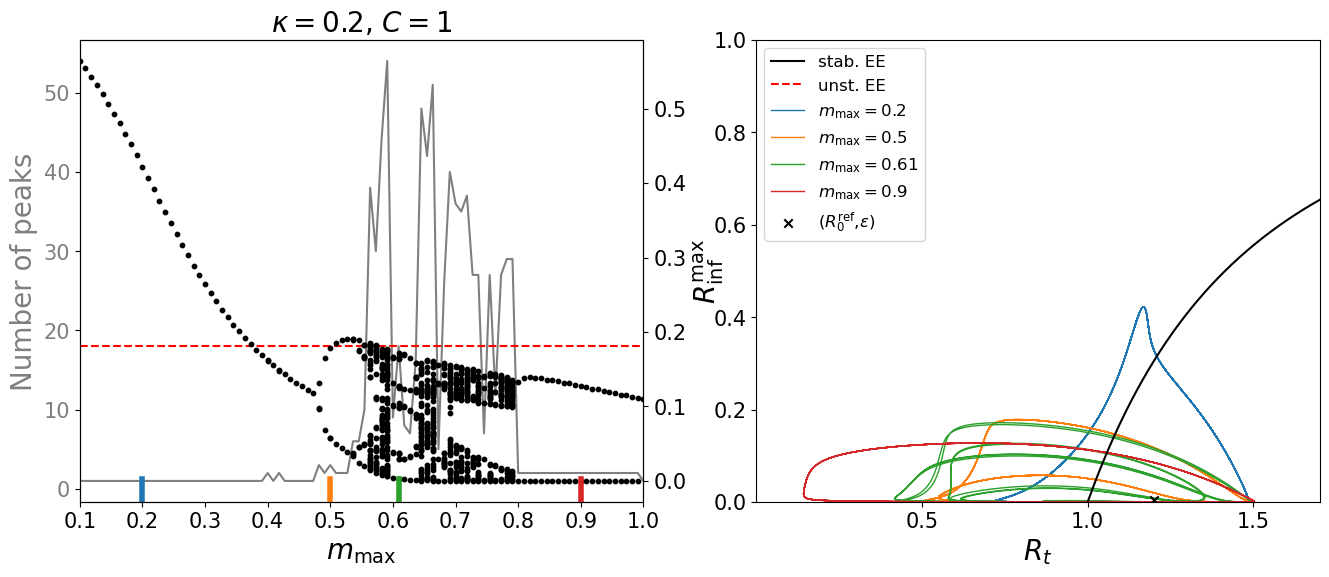

Finished mmax=0.2
Finished mmax=0.5
Finished mmax=0.6
tolerances lowered for kappa = 0.2 and mmax = 0.9
Finished mmax=0.9


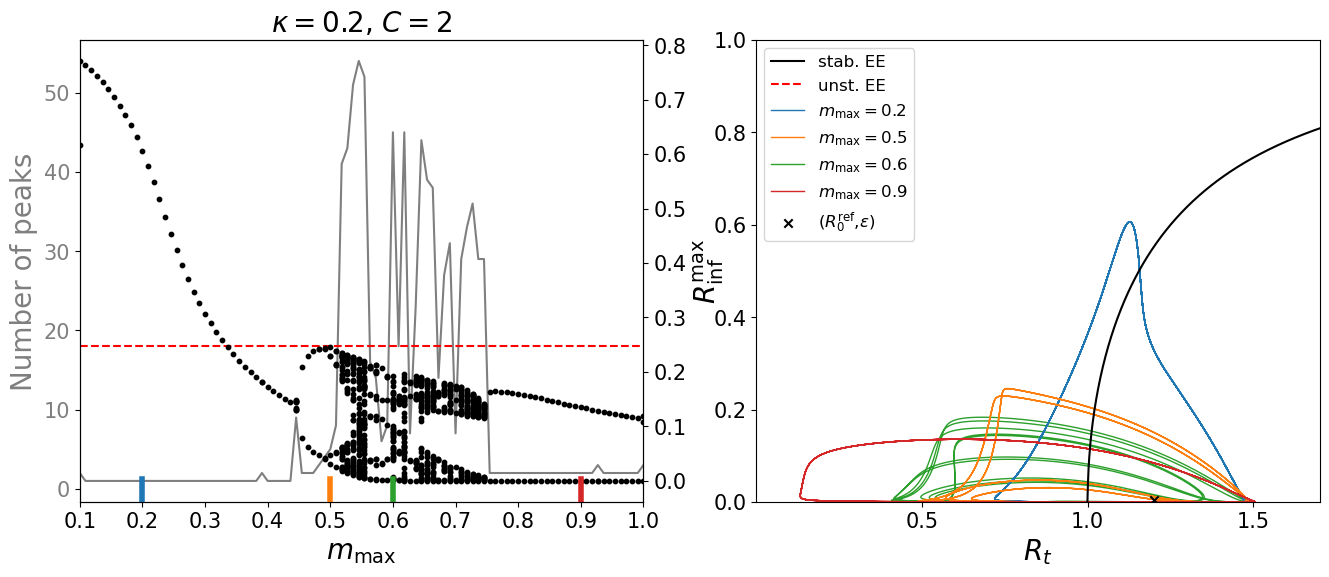

Finished mmax=0.2
Finished mmax=0.4
Finished mmax=0.55
at mmax= 0.7 ERROR: Solver stopped due to negative population.
Trying longer tmax=60.0 yrs instead...
Finished mmax=0.7
tolerances lowered for kappa = 0.2 and mmax = 1
at mmax= 1 ERROR: Solver stopped due to negative population.
Trying longer tmax=60.0 yrs instead...
at mmax= 1 ERROR: Solver stopped due to negative population.
Trying longer tmax=80.0 yrs instead...
at mmax= 1 ERROR: Solver stopped due to negative population.
Trying longer tmax=100.0 yrs instead...
Finished mmax=1


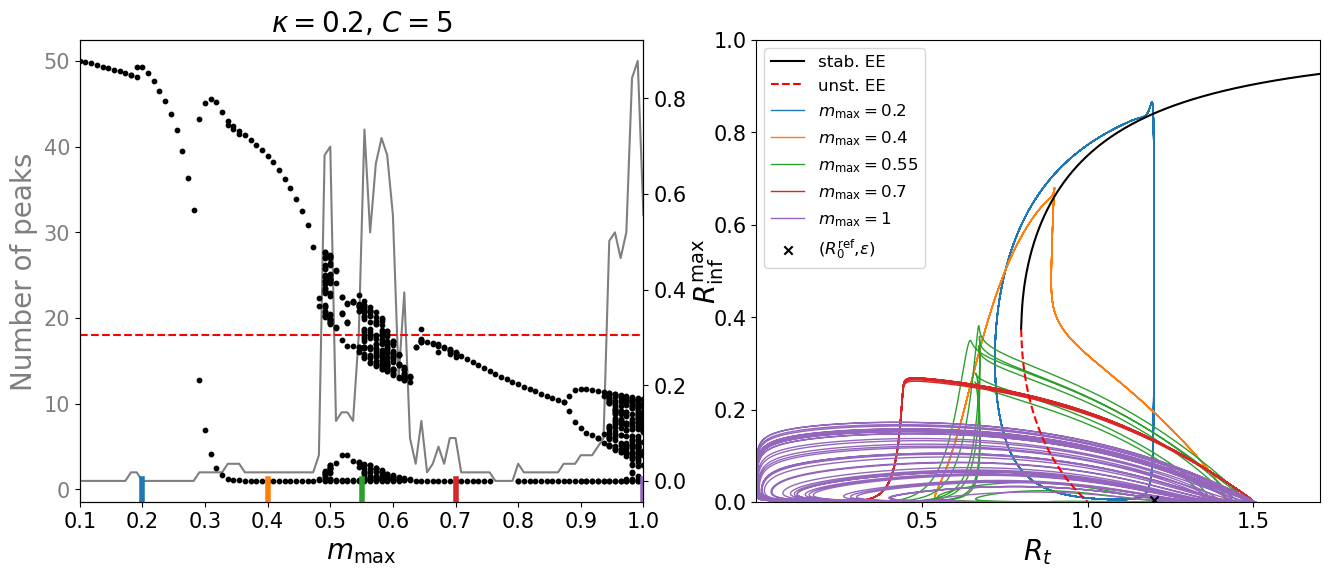

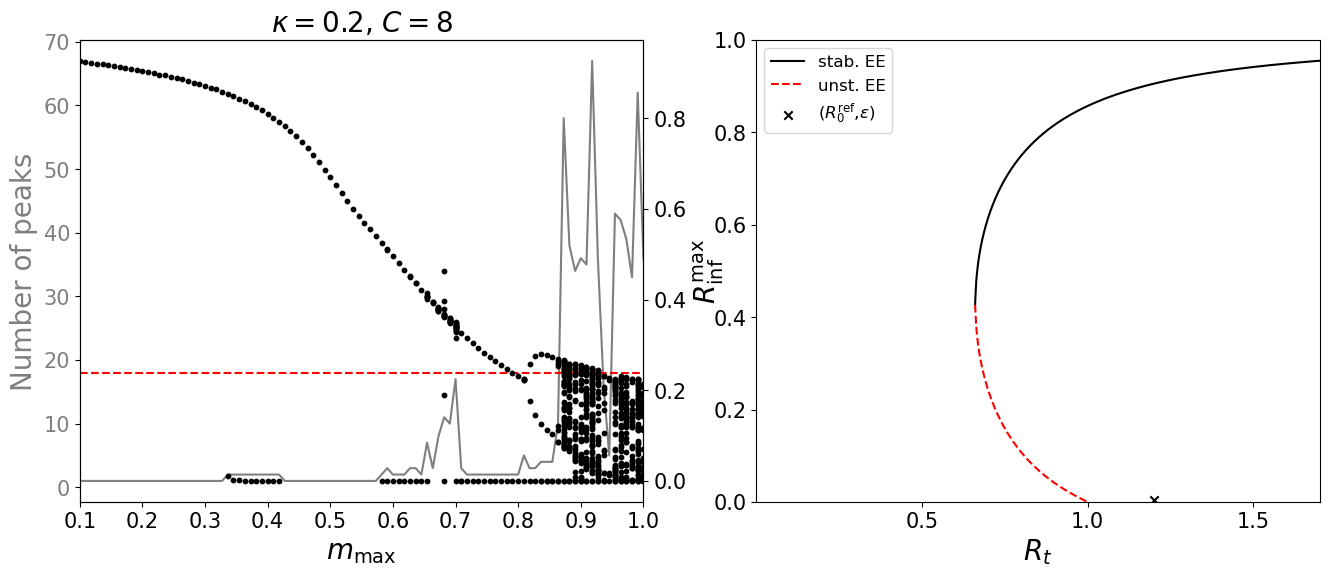

Finished mmax=0.2
Finished mmax=0.5
Finished mmax=0.7


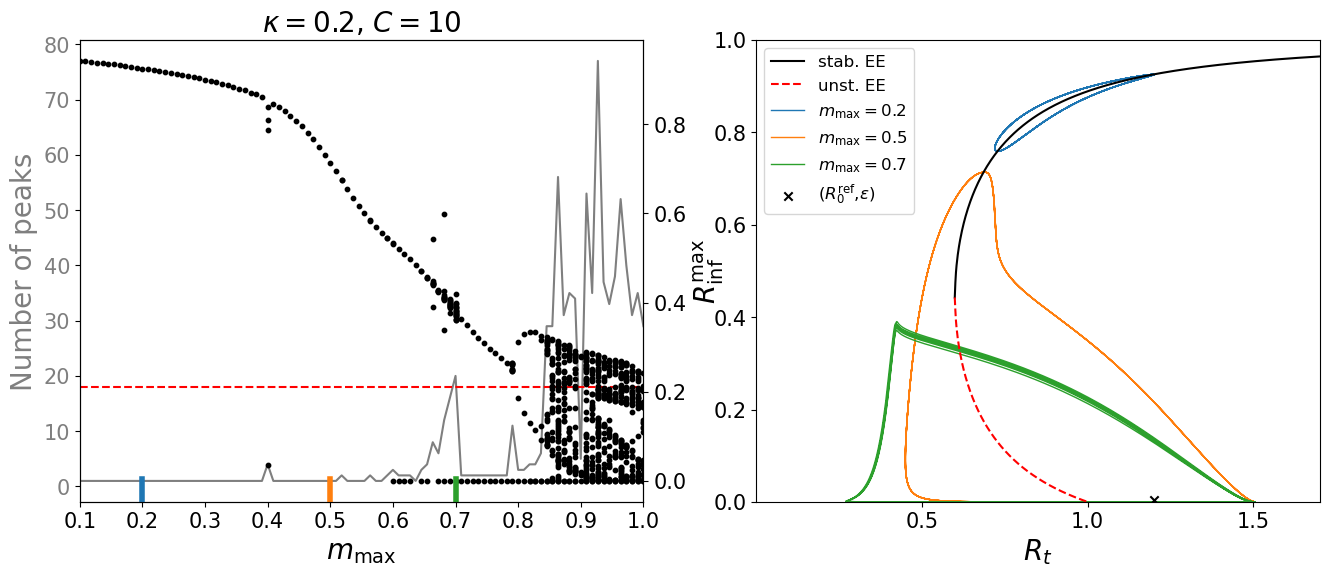

Finished mmax=0.4
Finished mmax=0.6
Finished mmax=0.7
tolerances lowered for kappa = 0.2 and mmax = 0.9
Finished mmax=0.9


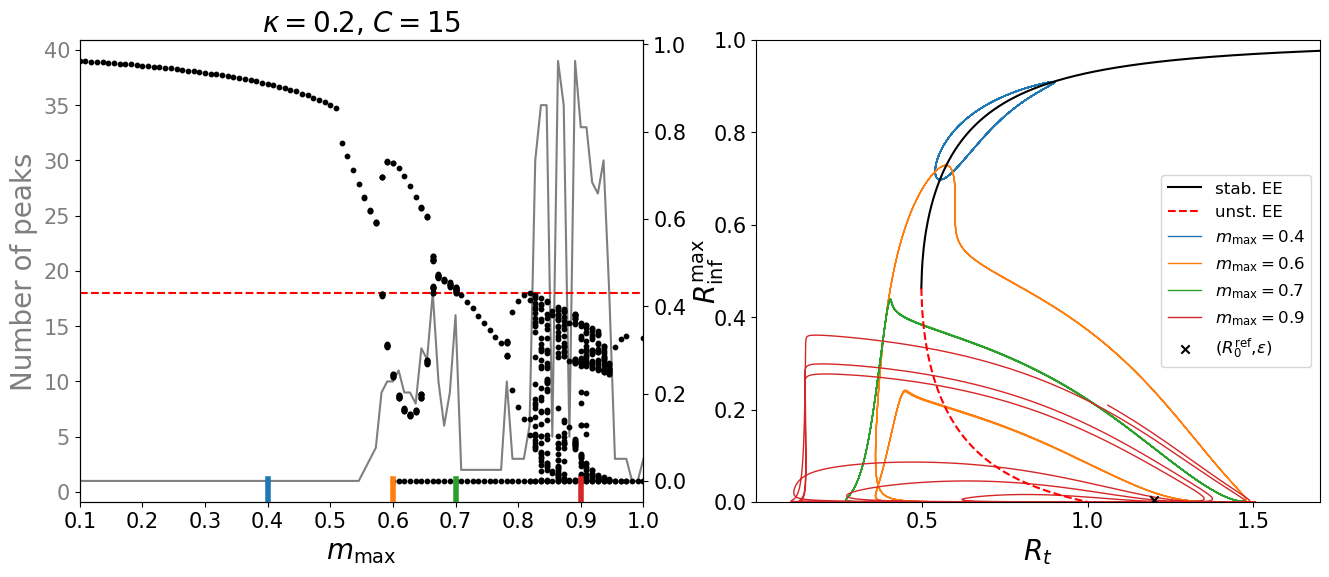

Finished mmax=0.4
tolerances lowered for kappa = 0.2 and mmax = 0.75
Finished mmax=0.75
tolerances lowered for kappa = 0.2 and mmax = 0.9
Finished mmax=0.9
tolerances lowered for kappa = 0.2 and mmax = 0.95
Finished mmax=0.95


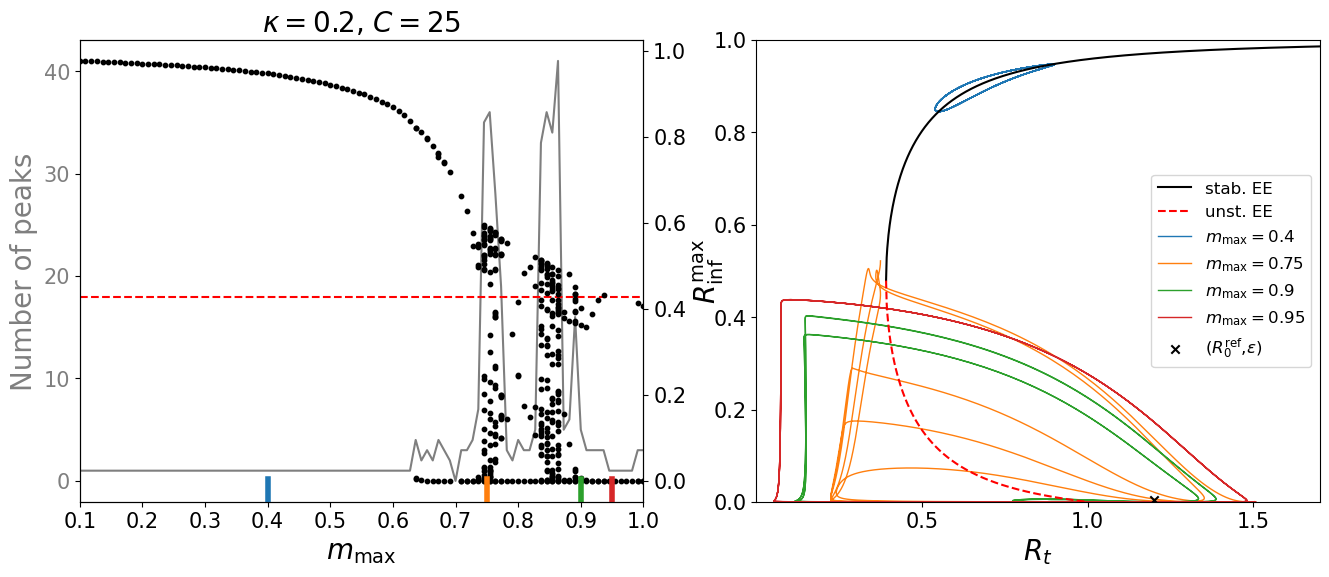

Finished mmax=0.6
tolerances lowered for kappa = 0.2 and mmax = 0.85
Finished mmax=0.85
tolerances lowered for kappa = 0.2 and mmax = 0.95
Finished mmax=0.95


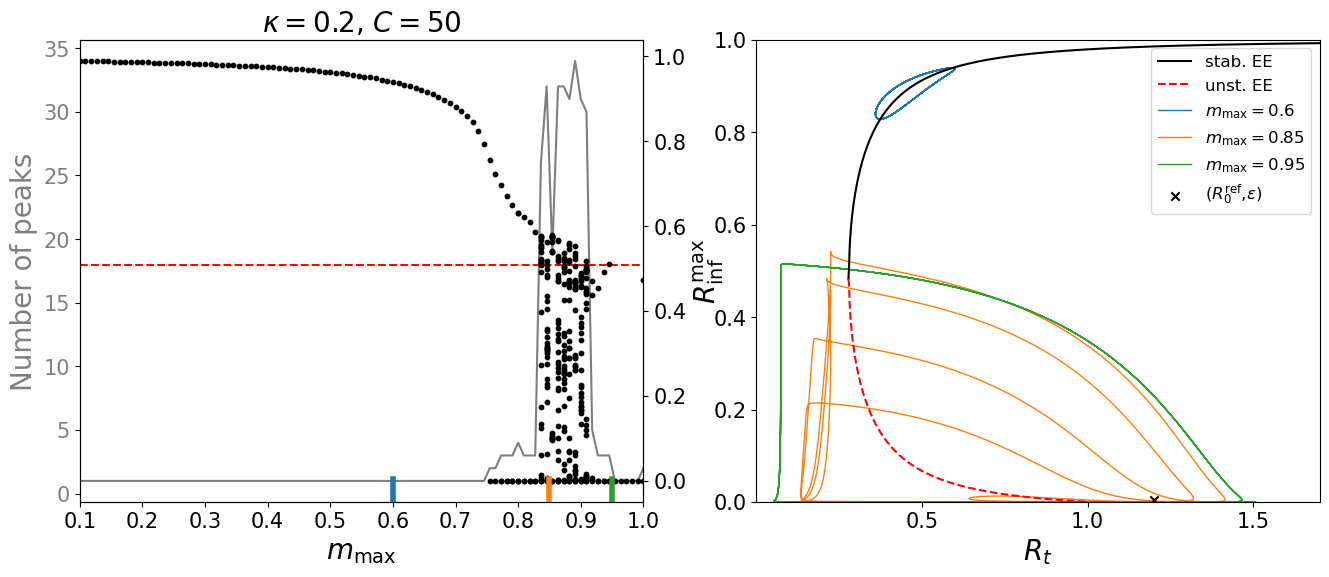

Finished mmax=0.6
tolerances lowered for kappa = 0.2 and mmax = 0.85
Finished mmax=0.85
tolerances lowered for kappa = 0.2 and mmax = 0.9
Finished mmax=0.9
tolerances lowered for kappa = 0.2 and mmax = 0.92
Finished mmax=0.92


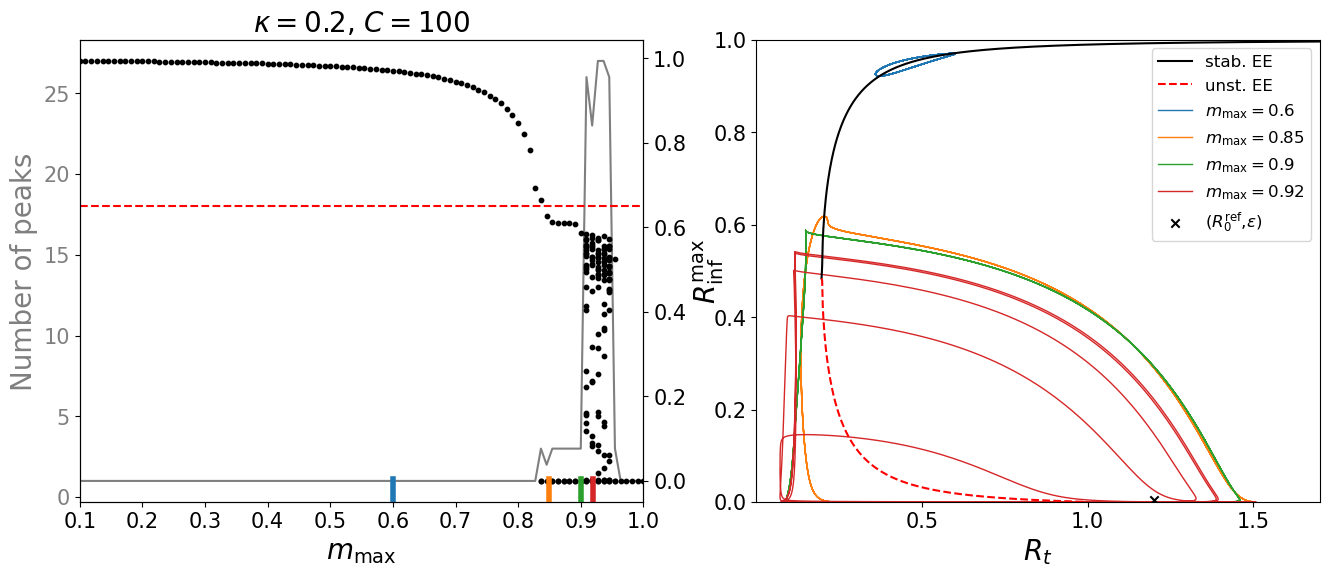

Finished mmax=0.2
Finished mmax=0.7
Finished mmax=0.9


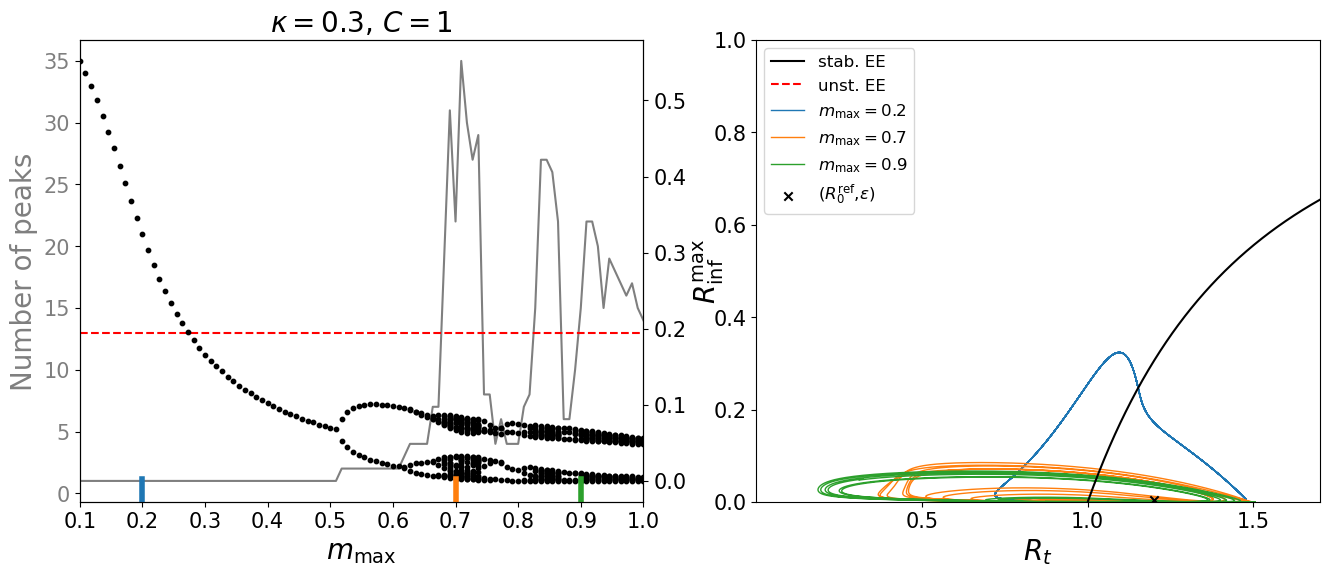

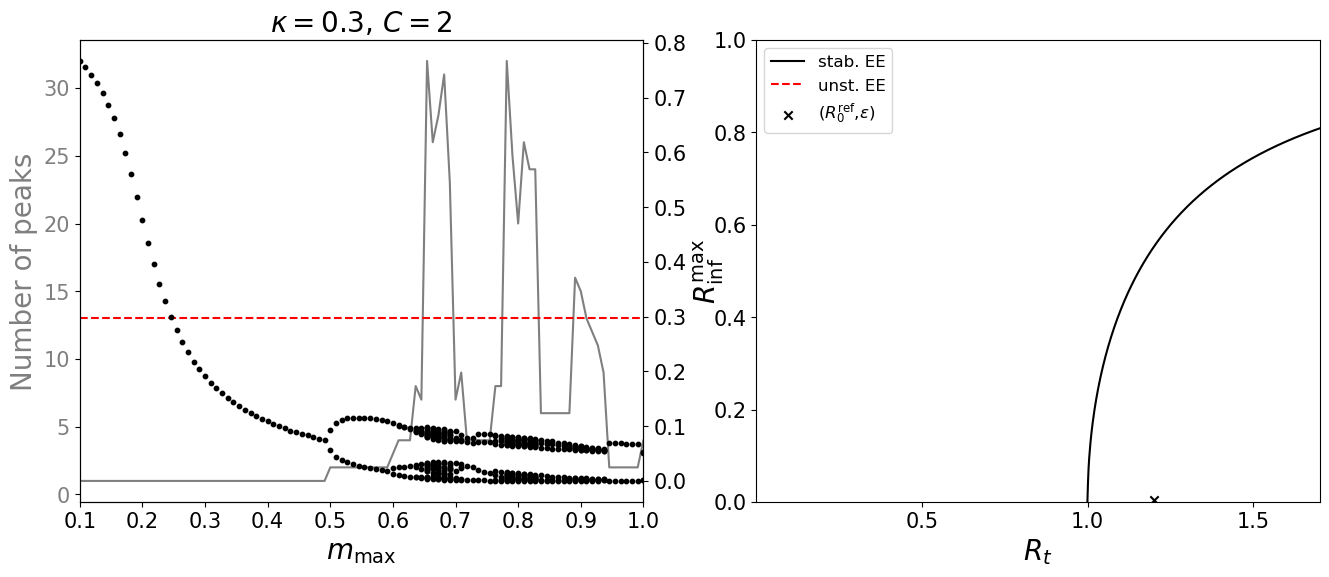

Finished mmax=0.2
Finished mmax=0.4
Finished mmax=0.58
Finished mmax=0.64
tolerances lowered for kappa = 0.3 and mmax = 1
Finished mmax=1


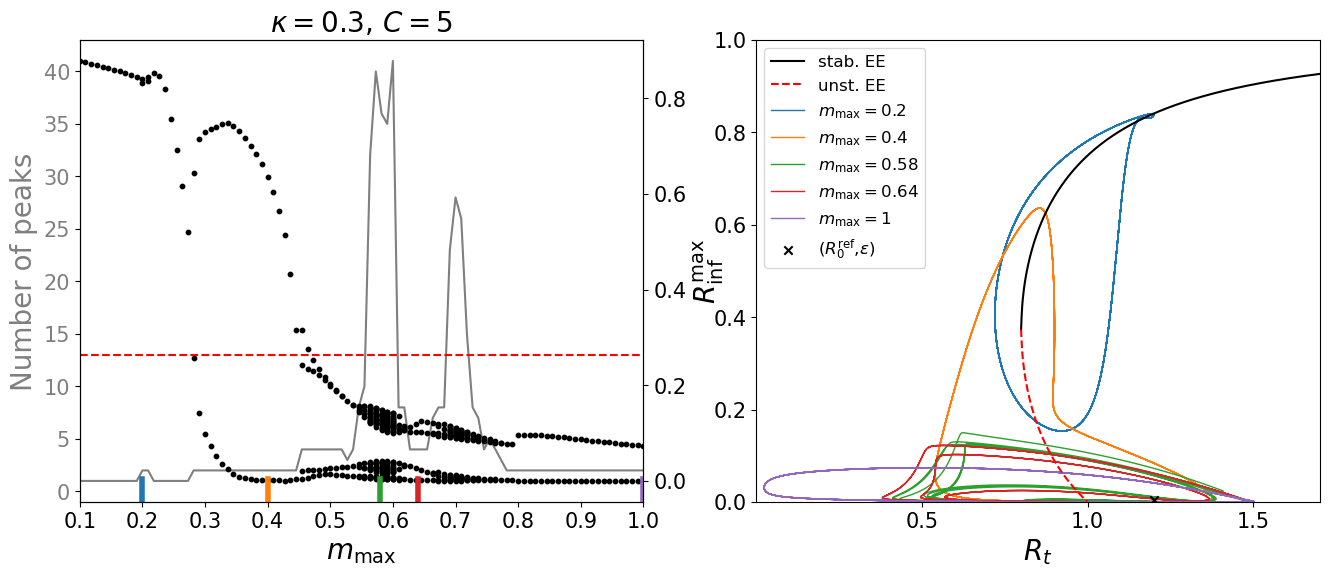

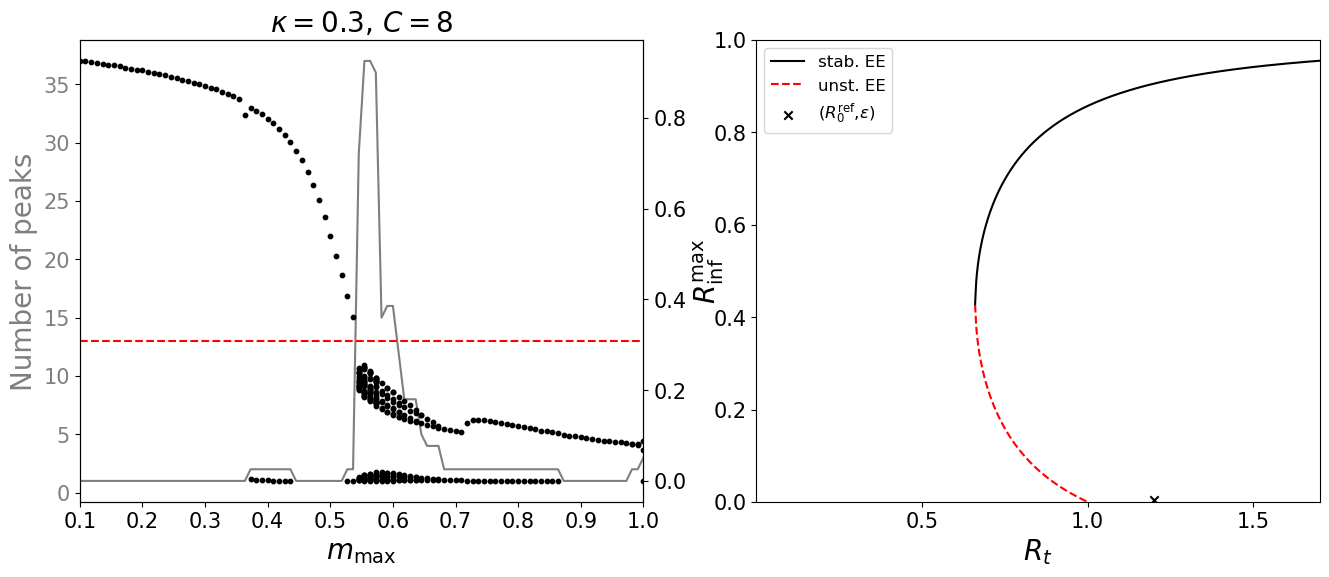

Finished mmax=0.3
Finished mmax=0.5
Finished mmax=0.6
Finished mmax=0.7


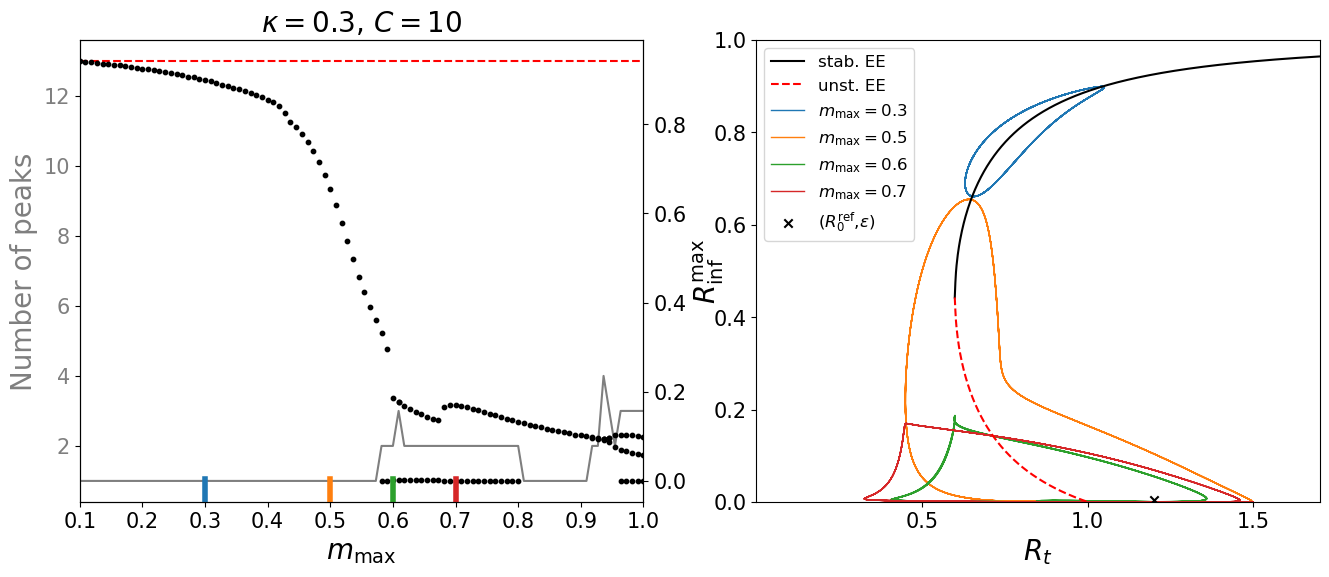

Finished mmax=0.4
Finished mmax=0.6
Finished mmax=0.7
tolerances lowered for kappa = 0.3 and mmax = 0.97
Finished mmax=0.97


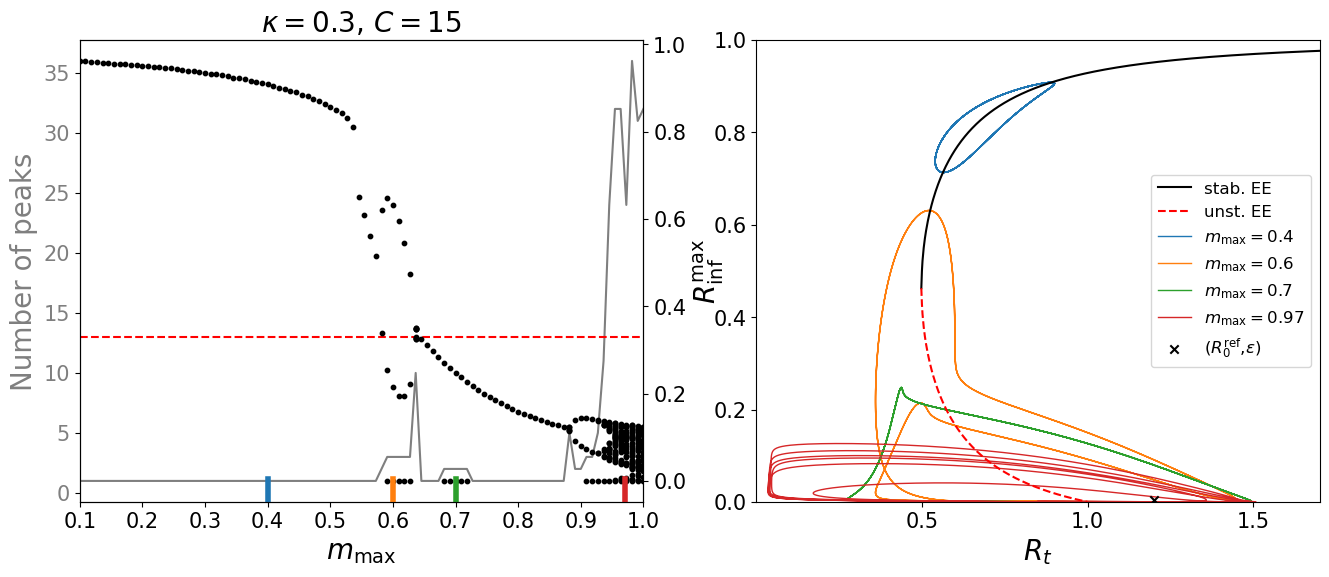

Finished mmax=0.4
Finished mmax=0.67
Finished mmax=0.8
Finished mmax=0.9


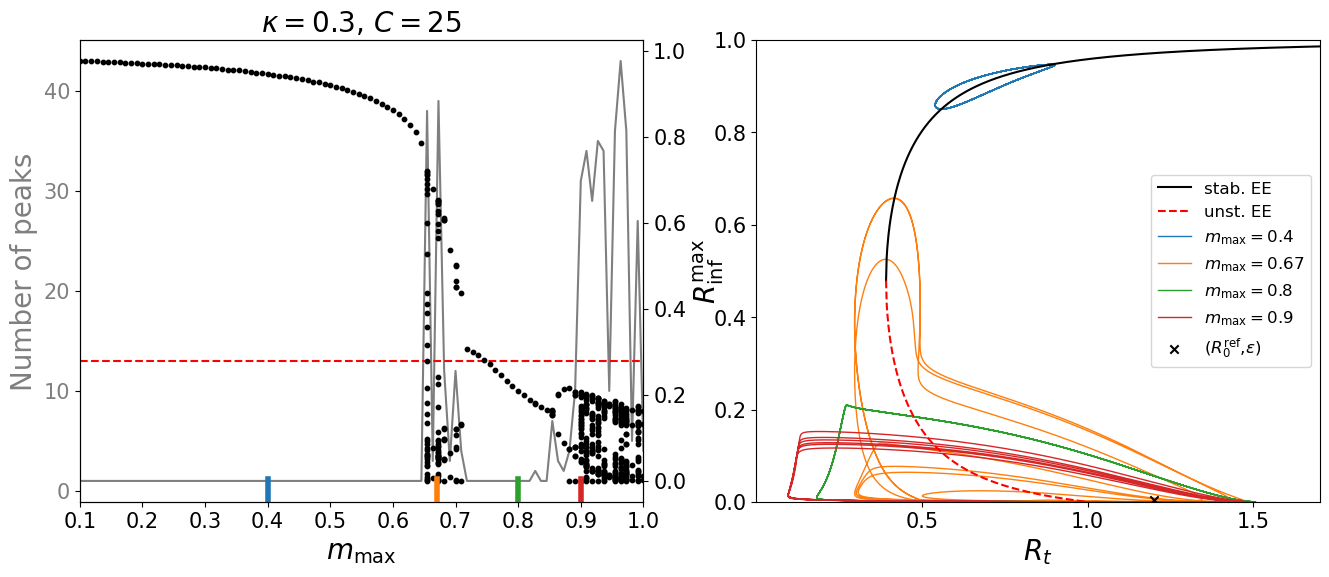

Finished mmax=0.78
Finished mmax=0.95


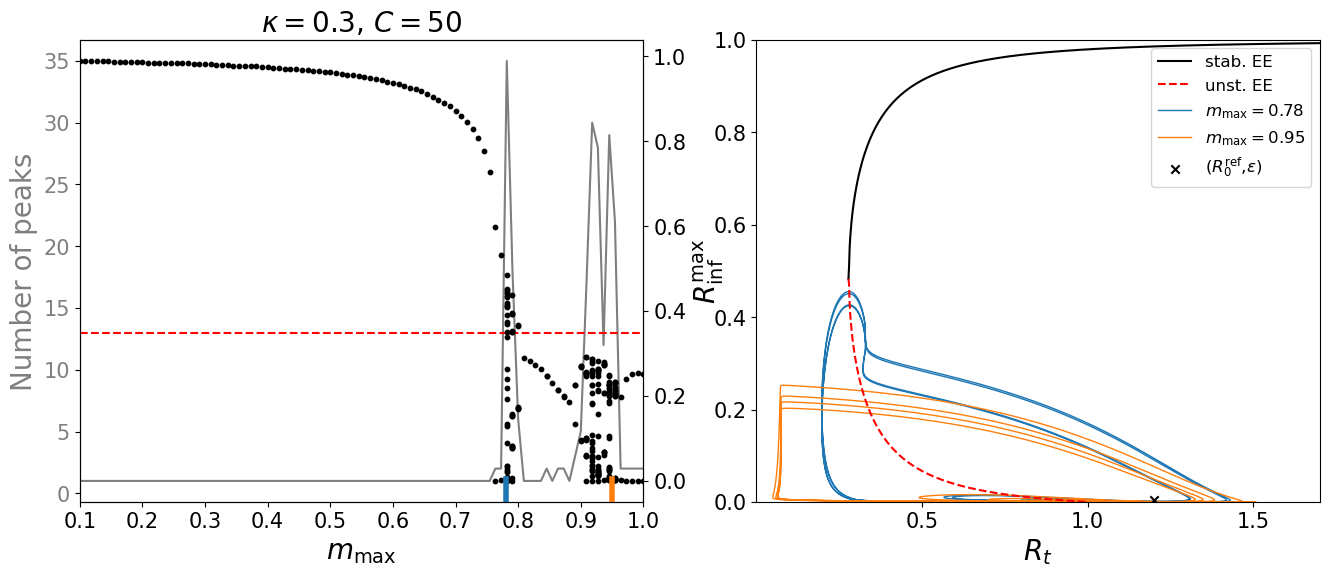

Finished mmax=0.86
Finished mmax=0.9
tolerances lowered for kappa = 0.3 and mmax = 1
Finished mmax=1


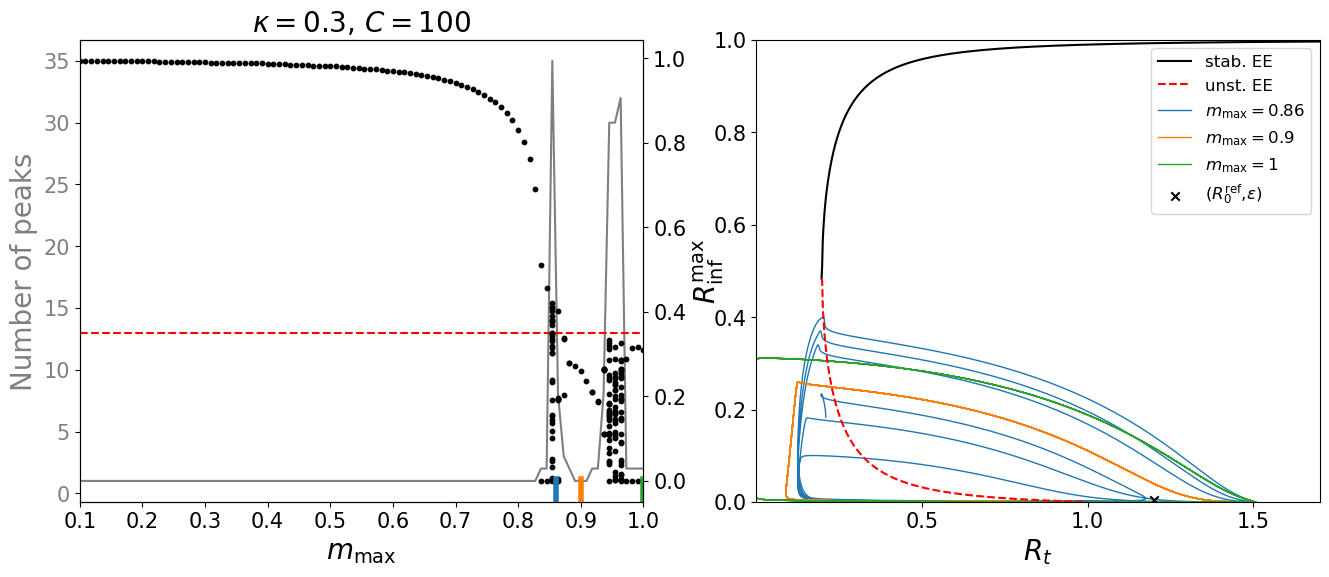

Finished mmax=0.2
Finished mmax=0.7
Finished mmax=0.9


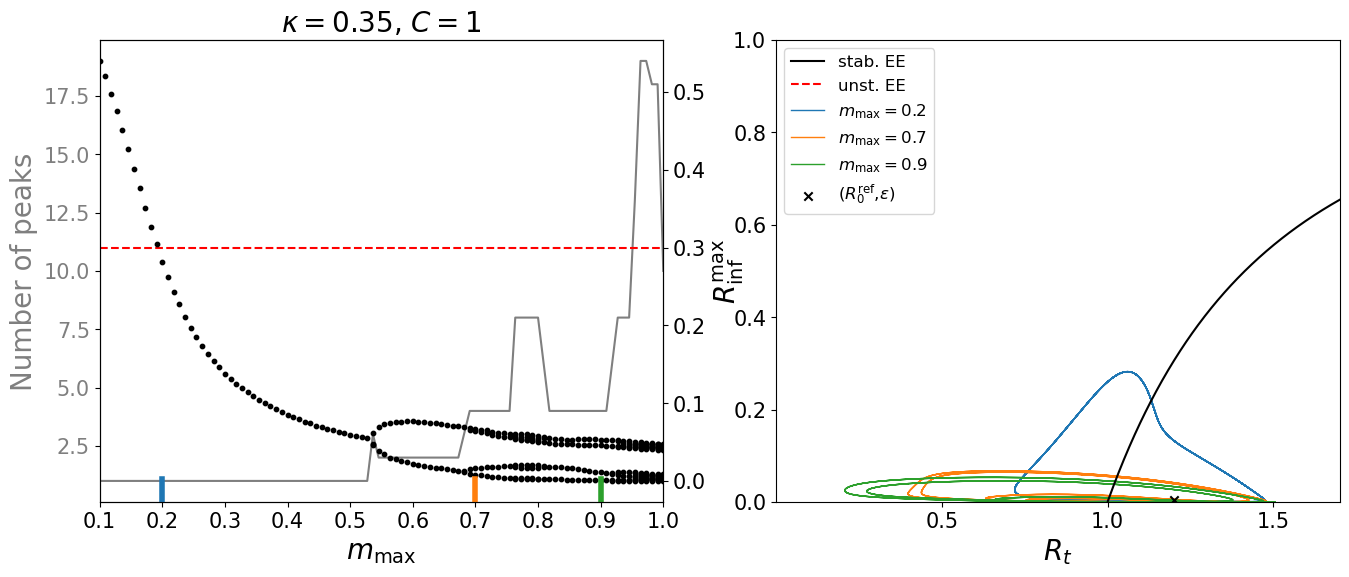

Finished mmax=0.9


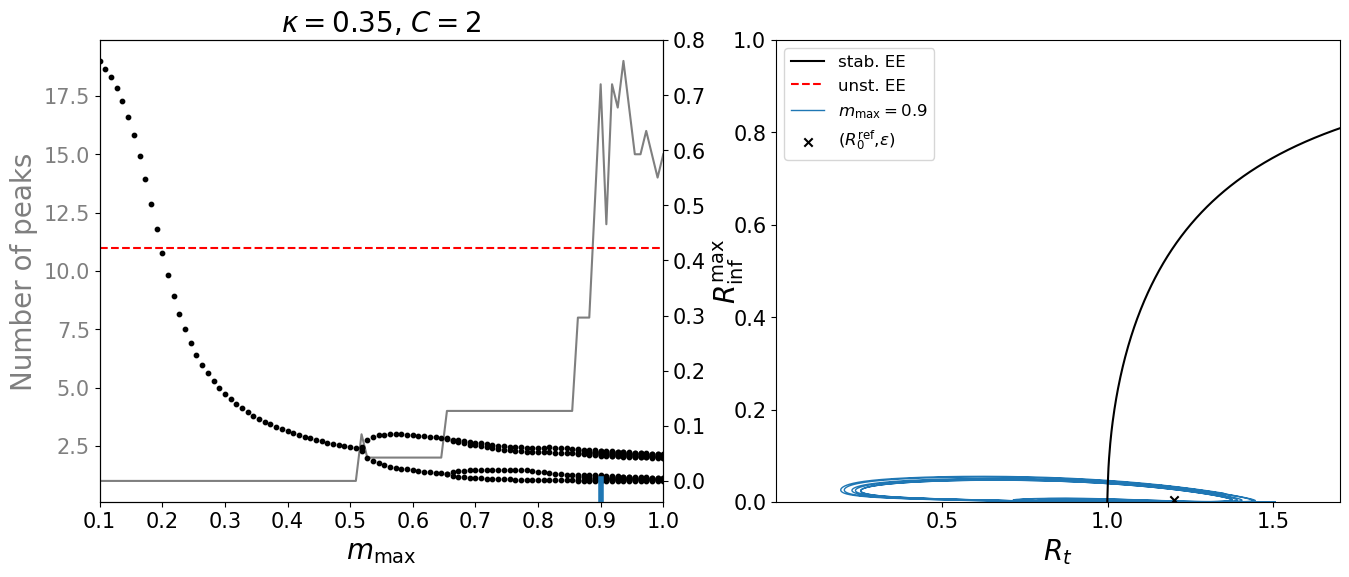

Finished mmax=0.2
Finished mmax=0.23
Finished mmax=0.3
Finished mmax=0.4


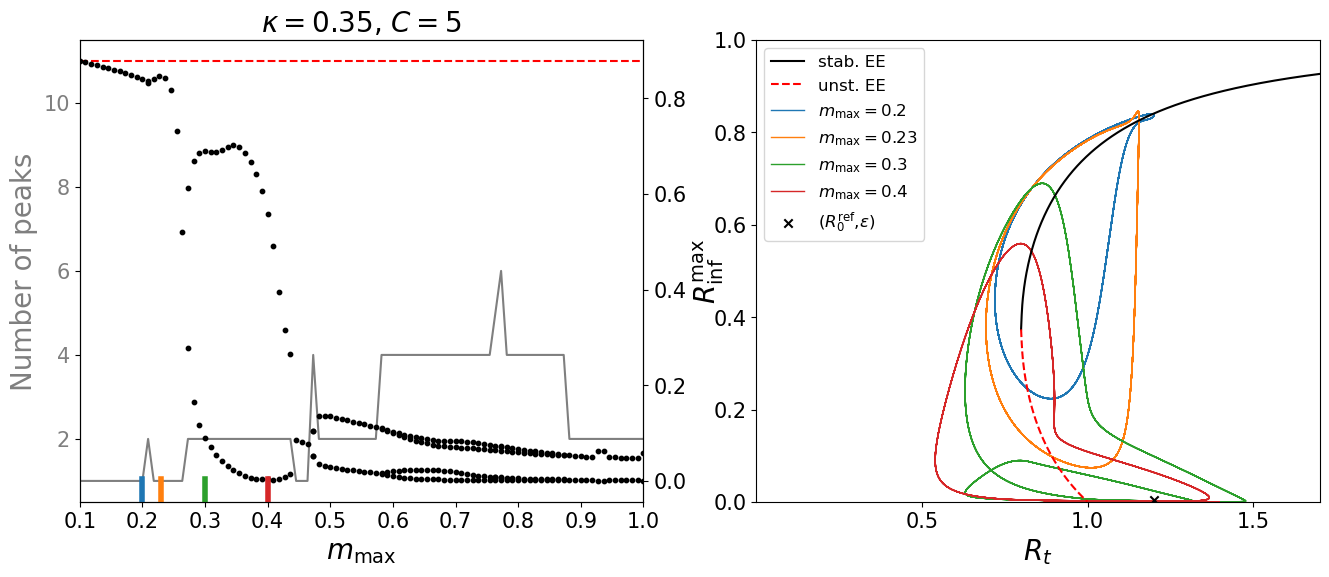

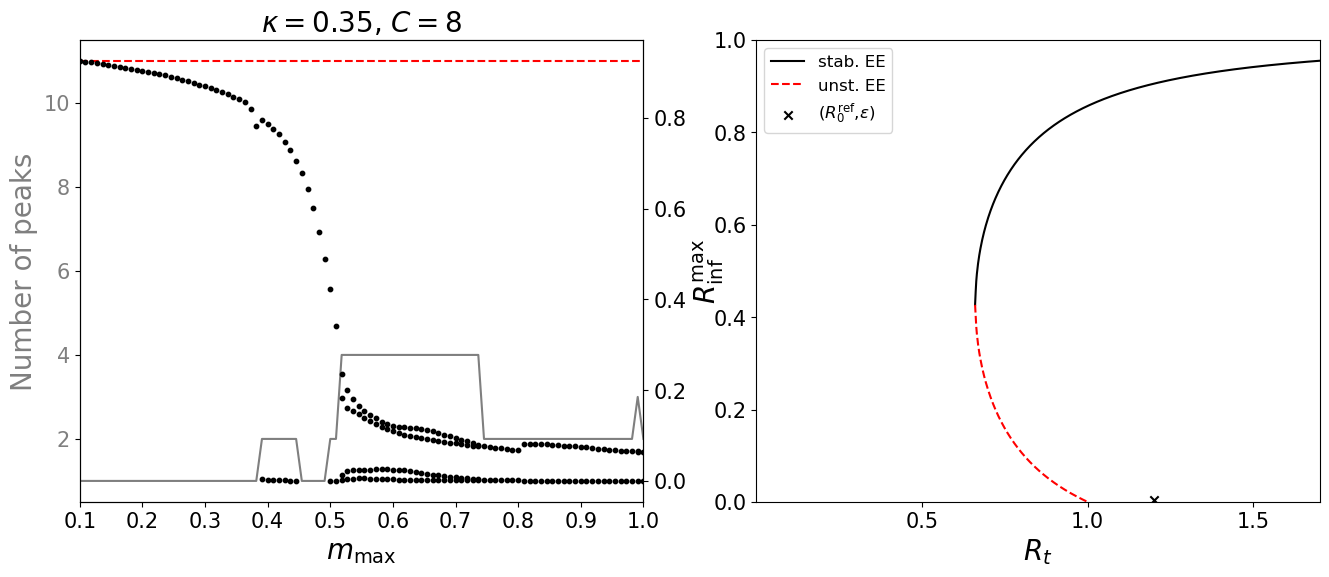

Finished mmax=0.6
Finished mmax=0.8


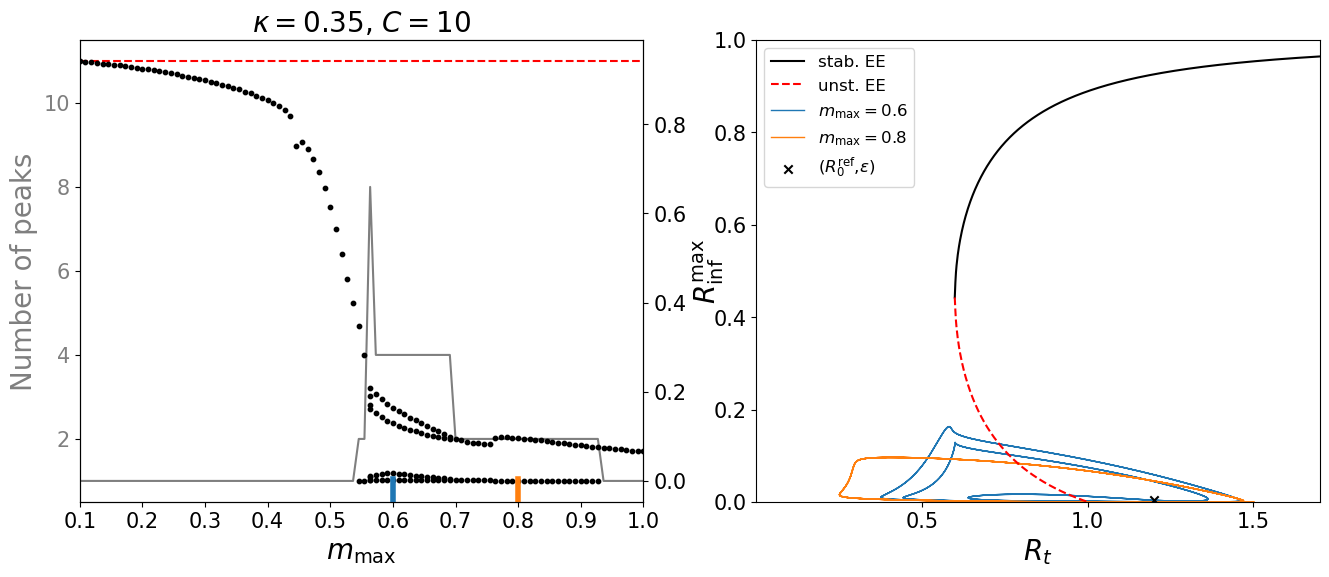

Finished mmax=0.4
Finished mmax=0.6
Finished mmax=0.7
Finished mmax=0.97


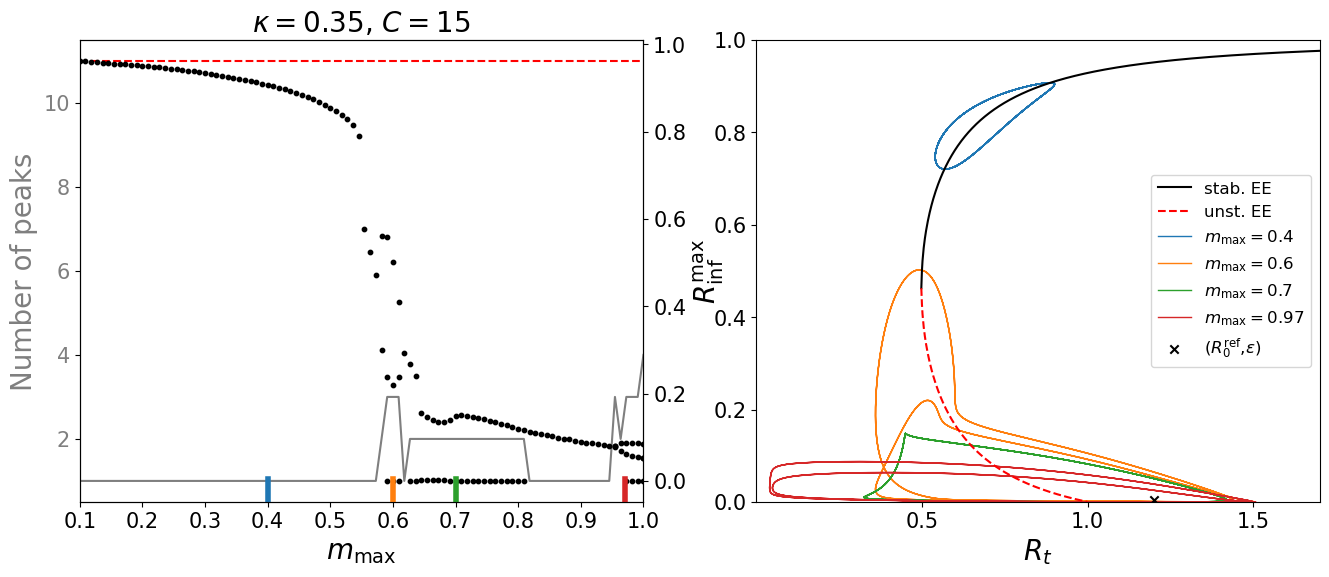

Finished mmax=0.4
Finished mmax=0.67
Finished mmax=0.8
Finished mmax=0.9


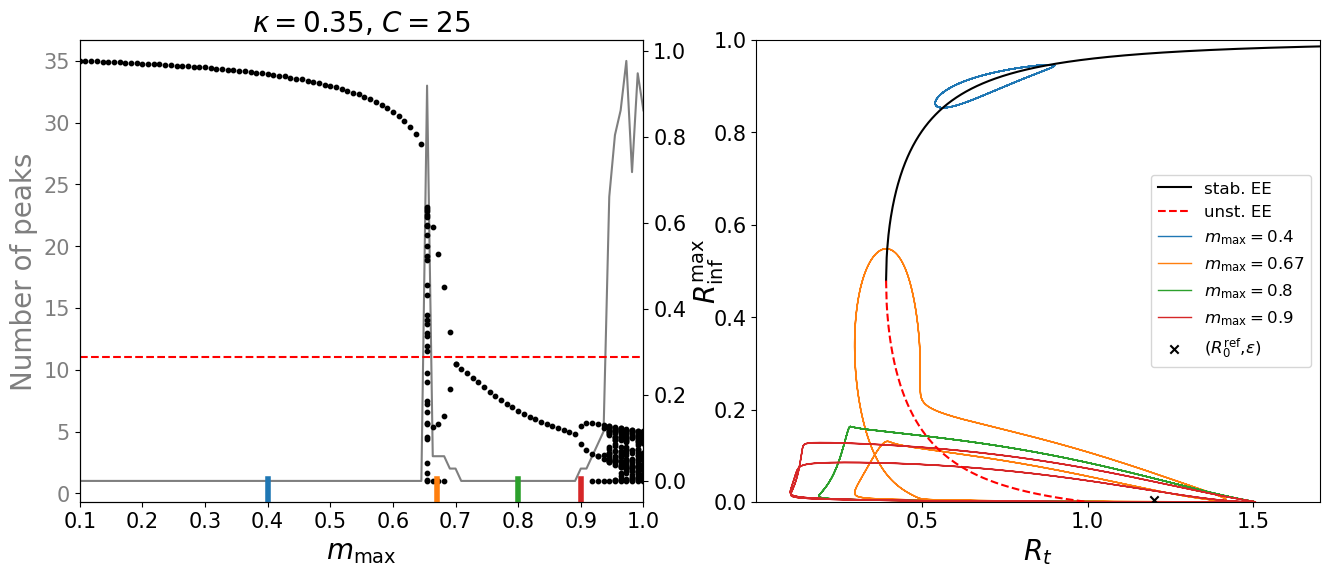

Finished mmax=0.6
Finished mmax=0.78
Finished mmax=0.95


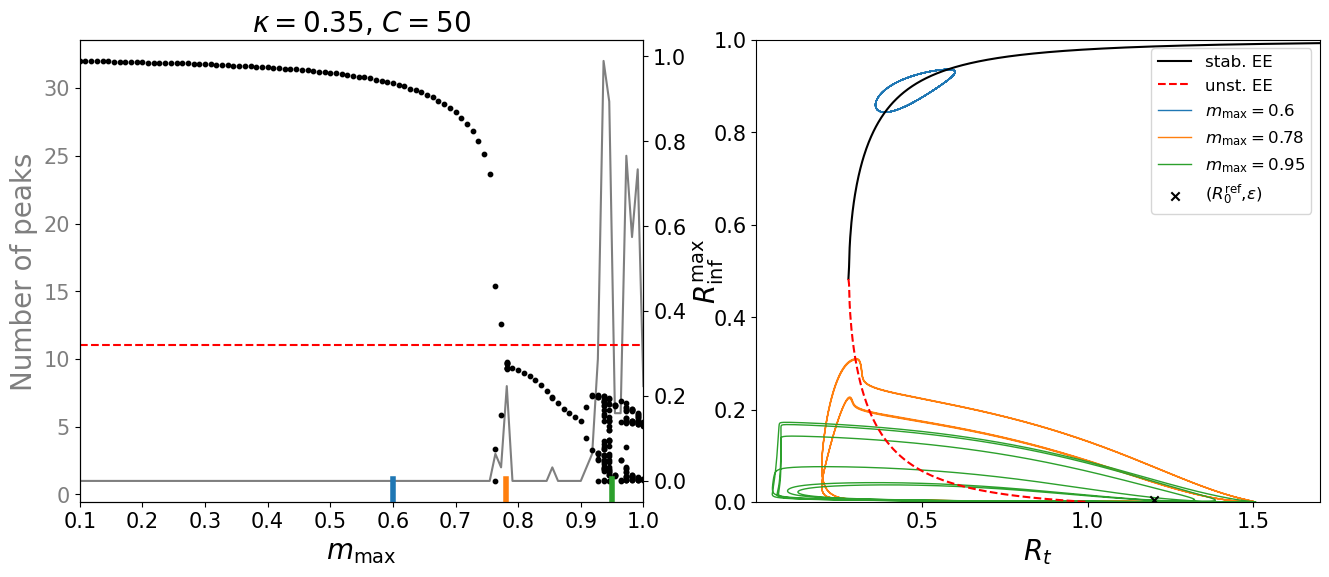

Finished mmax=0.6
Finished mmax=0.86
Finished mmax=0.9
Finished mmax=1


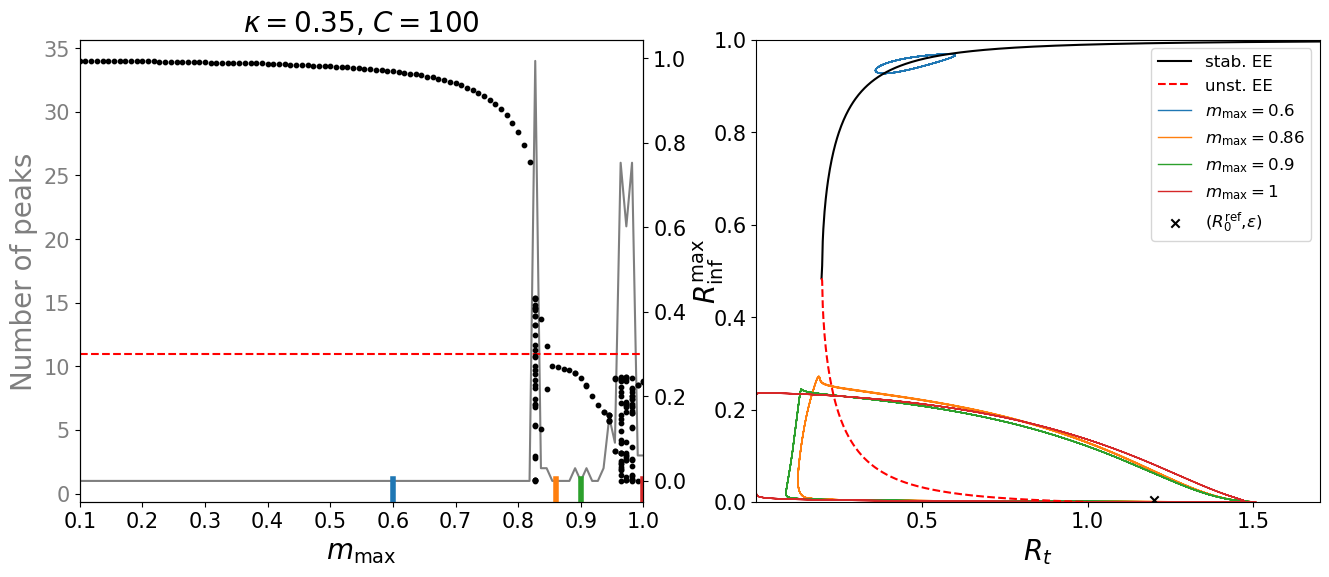

Finished mmax=0.2
Finished mmax=0.5
Finished mmax=0.7
Finished mmax=0.9


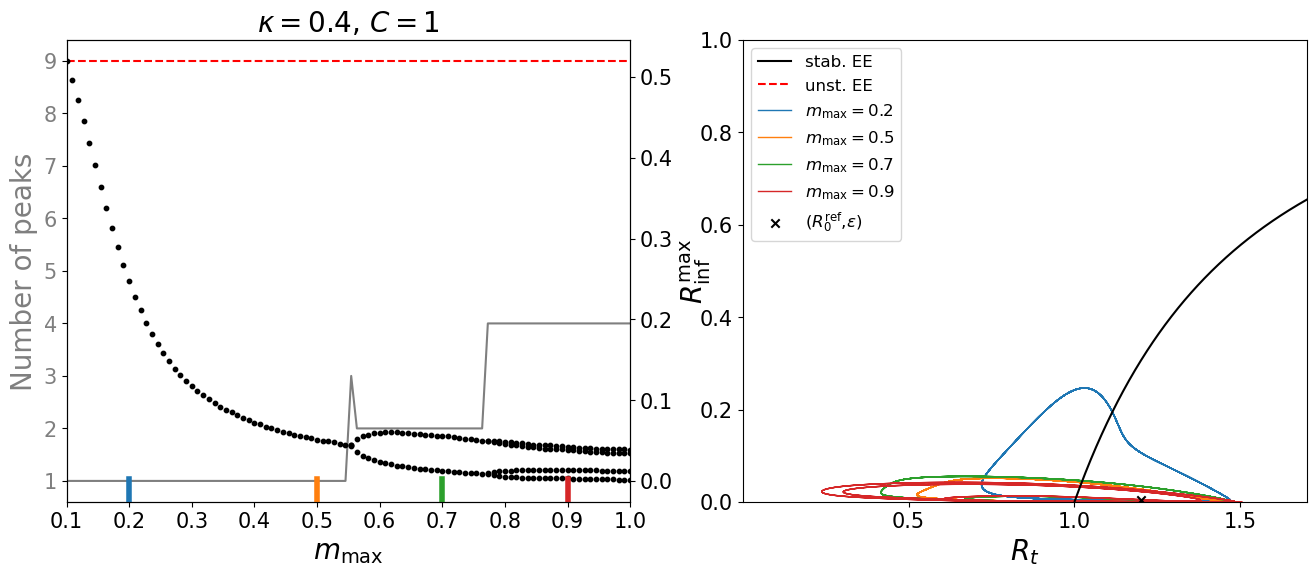

Finished mmax=0.2
Finished mmax=0.5
Finished mmax=0.7
Finished mmax=0.87
Finished mmax=0.9


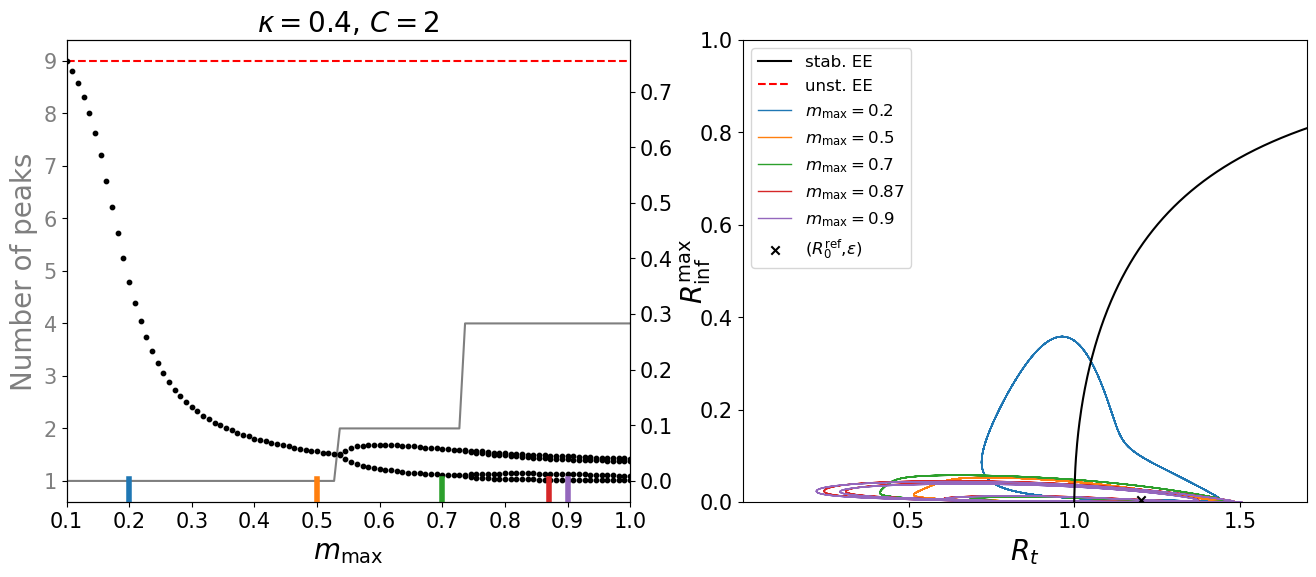

Finished mmax=0.2
Finished mmax=0.4
Finished mmax=0.58
Finished mmax=0.64
Finished mmax=1


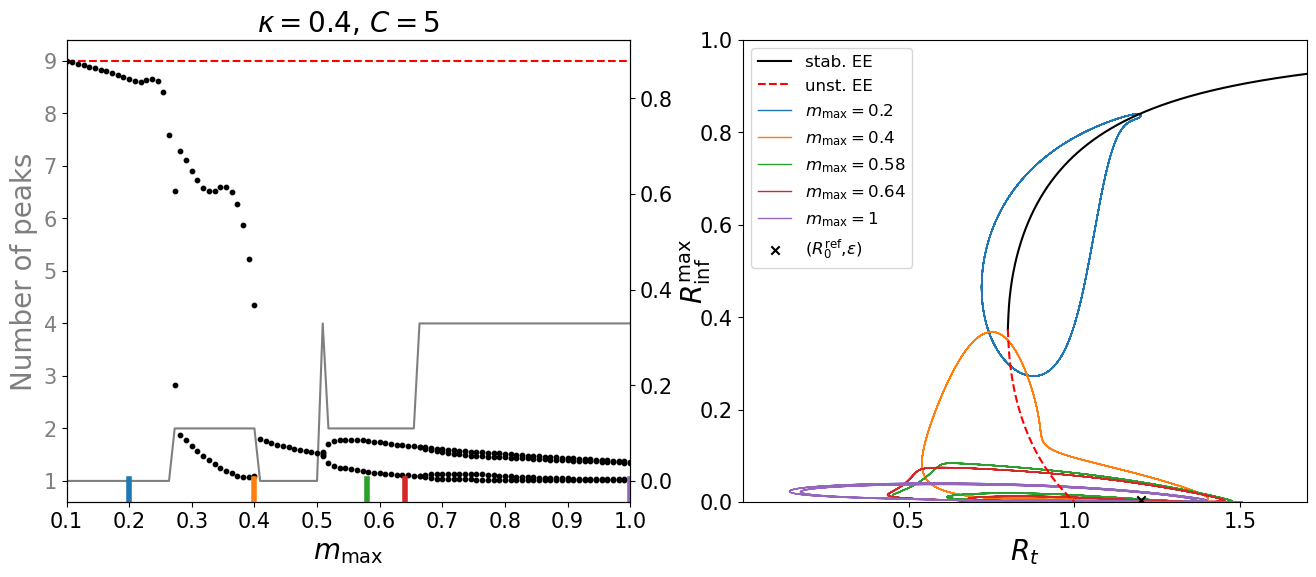

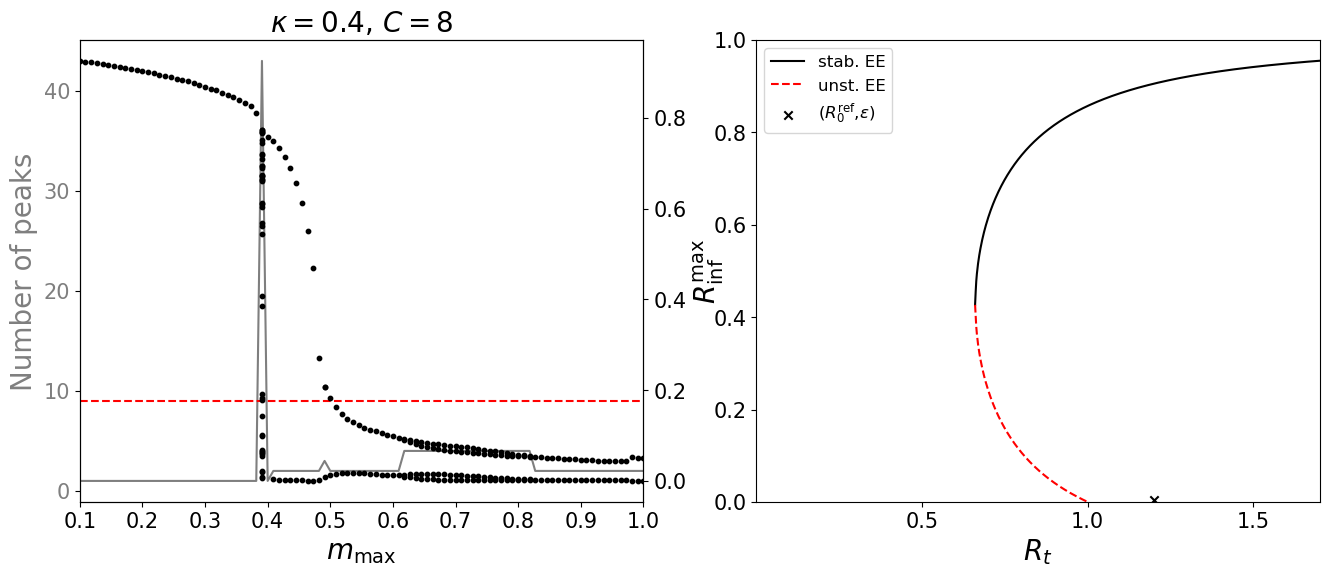

Finished mmax=0.4
Finished mmax=0.46
Finished mmax=0.5
Finished mmax=0.55


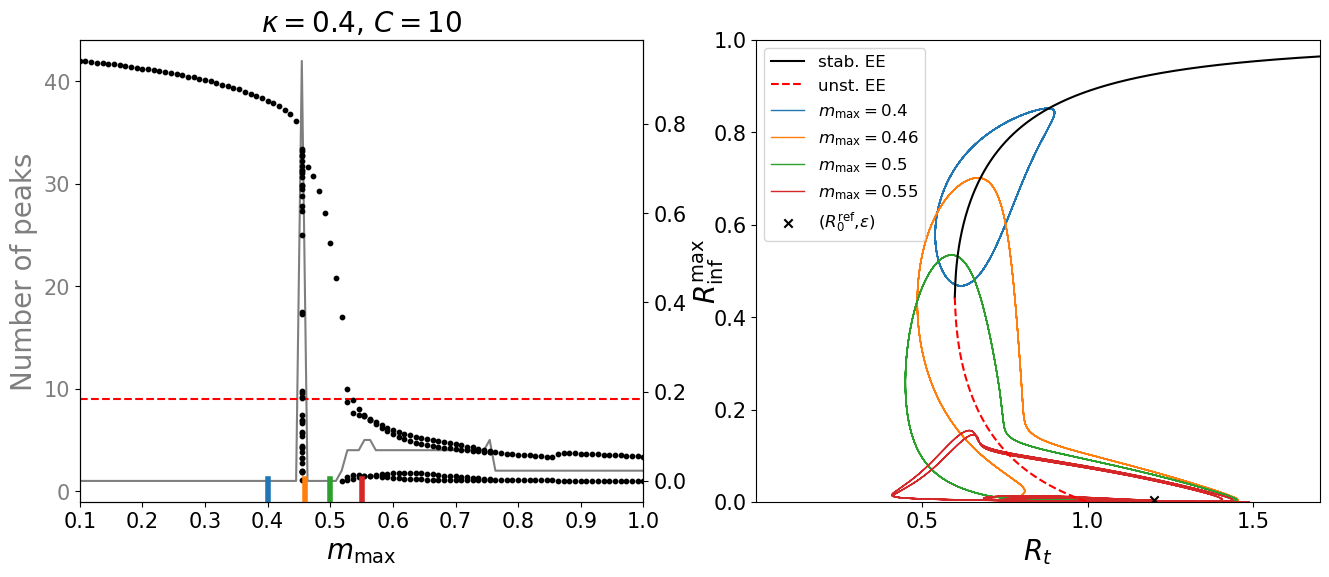

Finished mmax=0.4
Finished mmax=0.6
Finished mmax=0.7
Finished mmax=0.97


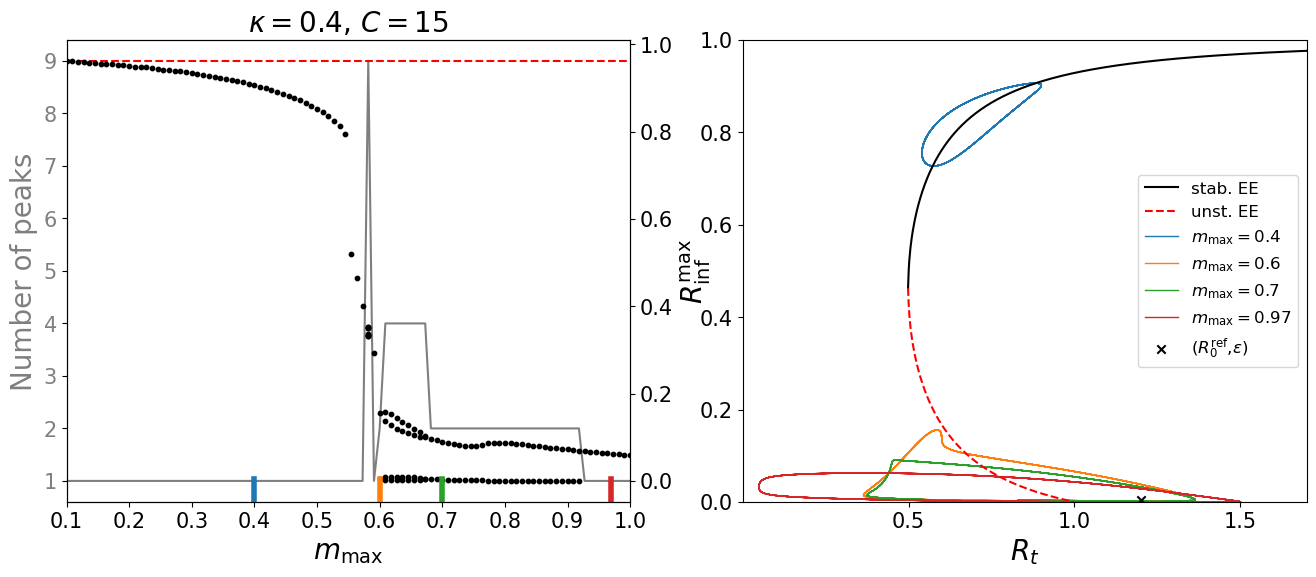

Finished mmax=0.4
Finished mmax=0.67
Finished mmax=0.8
Finished mmax=0.9


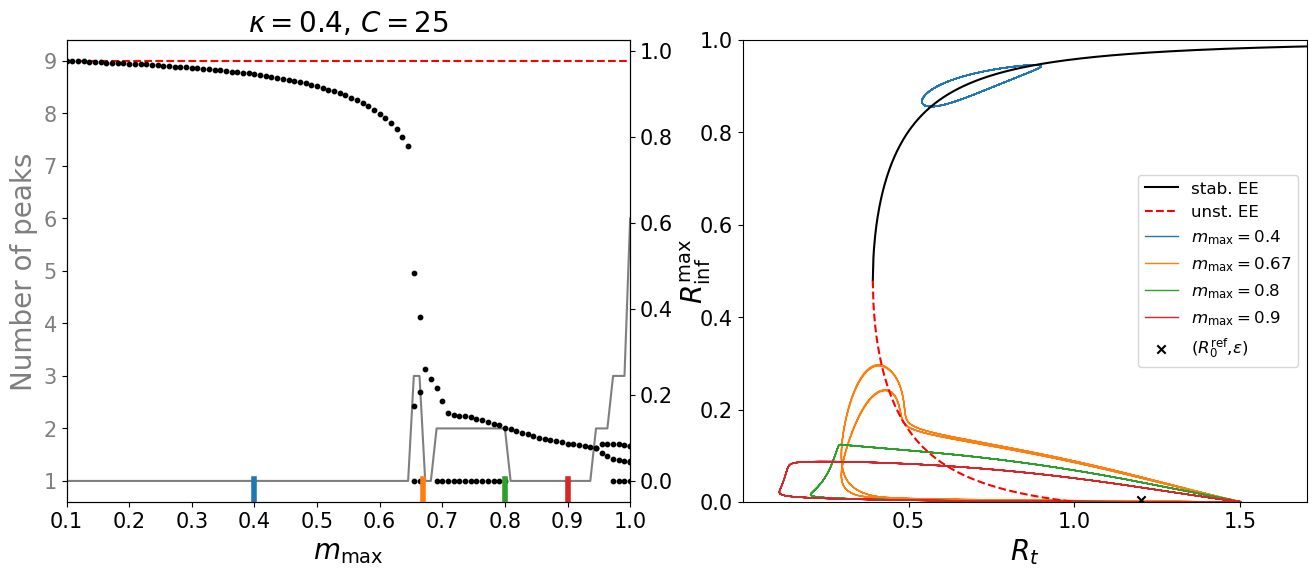

Finished mmax=0.6
Finished mmax=0.78
Finished mmax=0.95


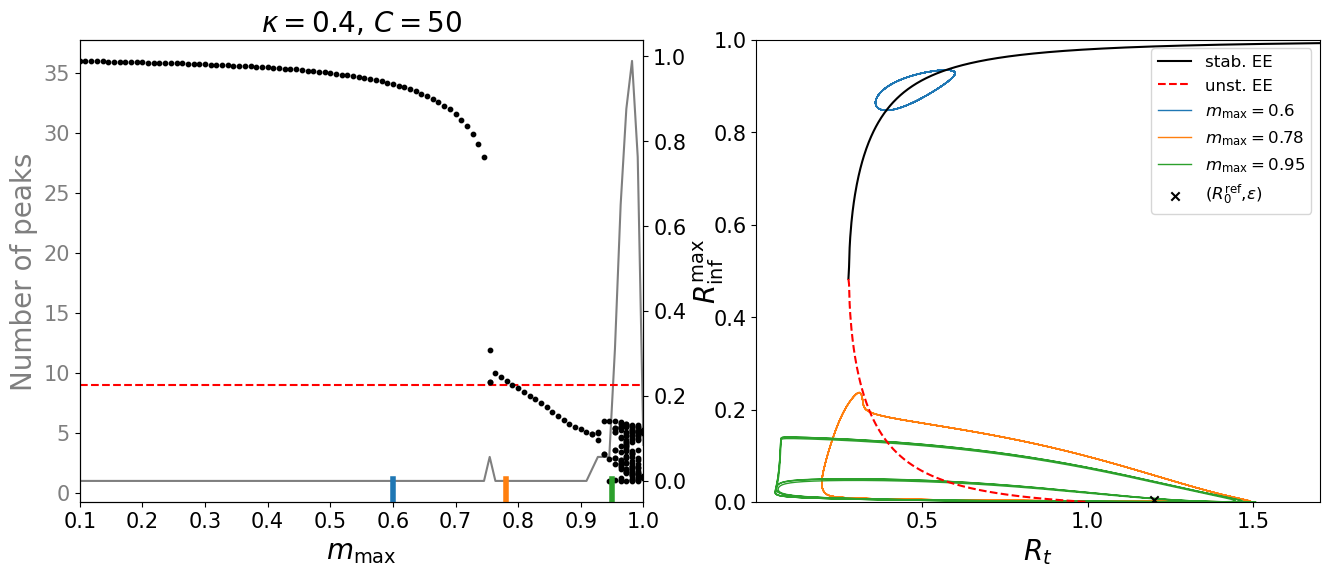

Finished mmax=0.6
Finished mmax=0.86
Finished mmax=0.9
Finished mmax=1


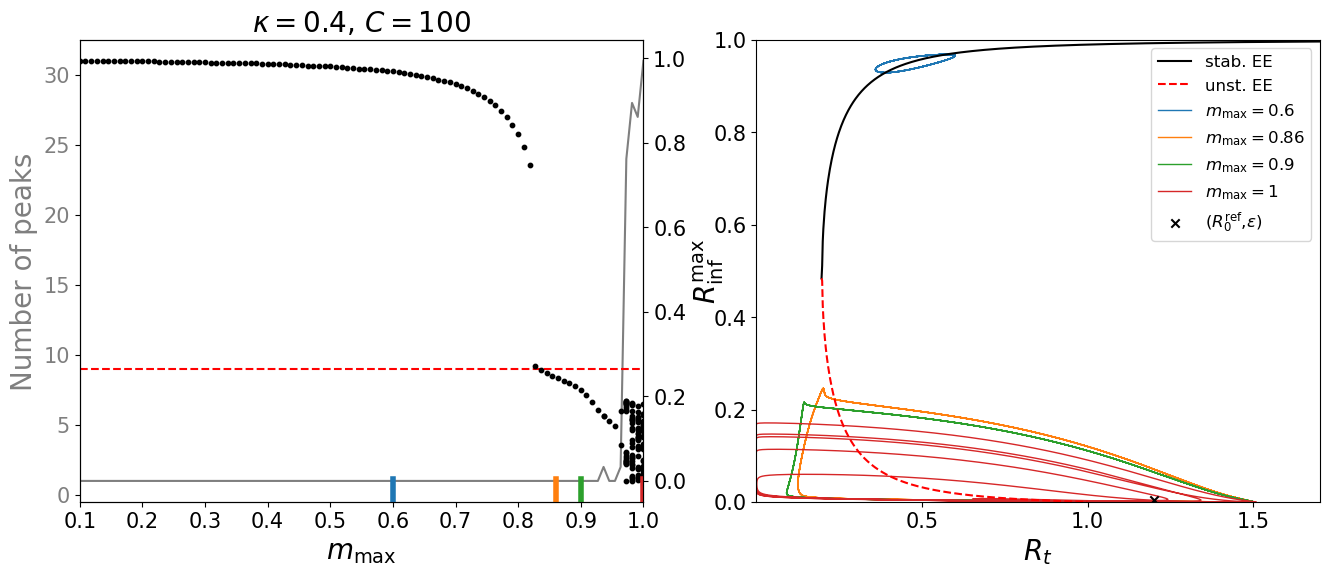

Finished mmax=0.2
Finished mmax=0.8


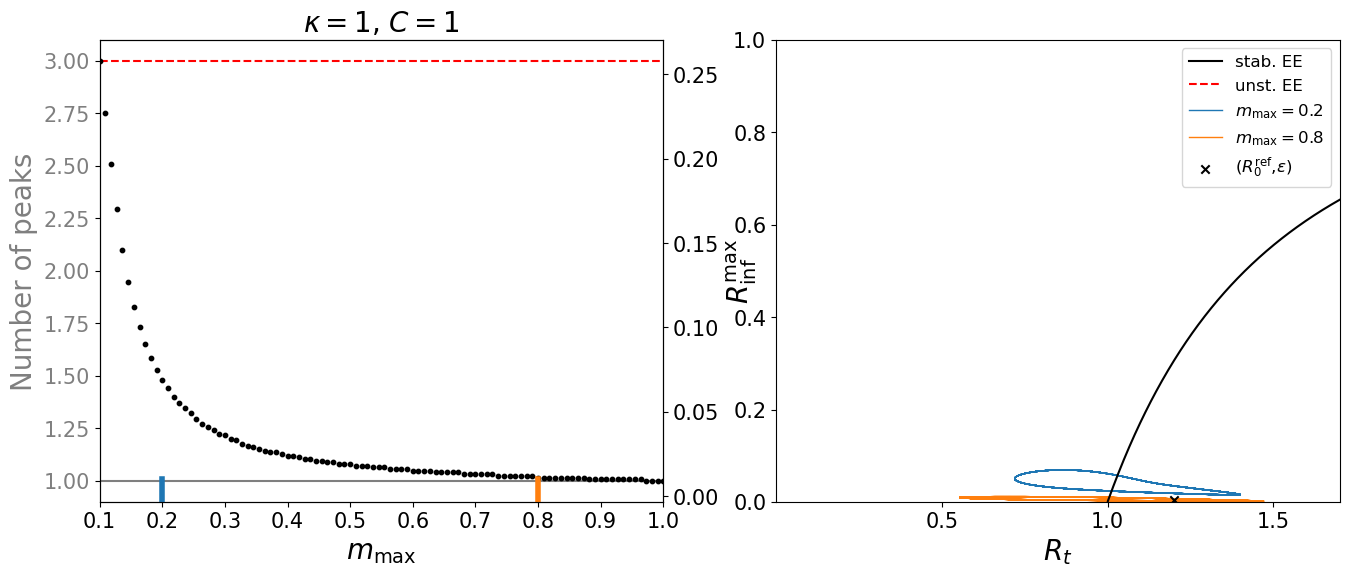

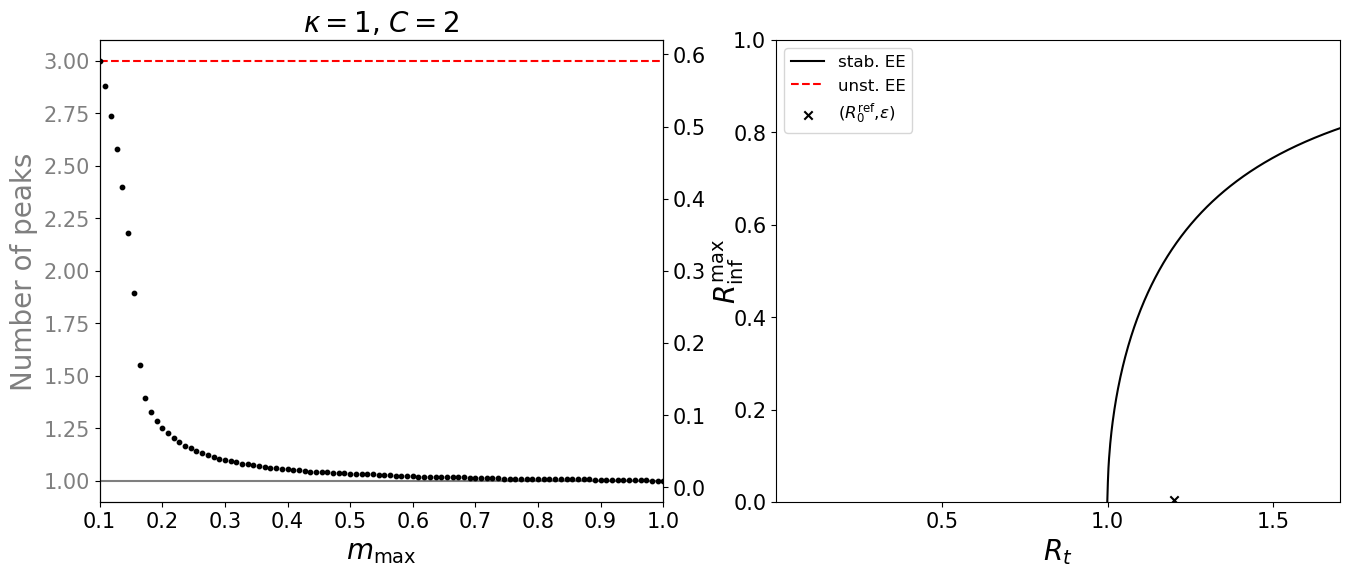

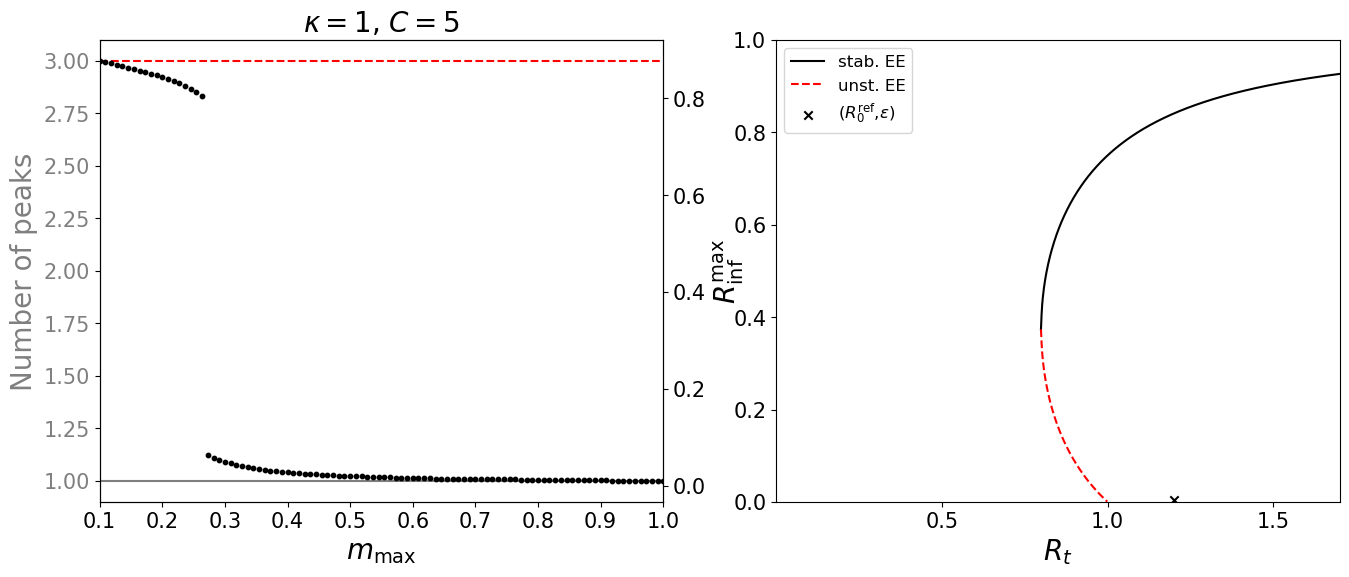

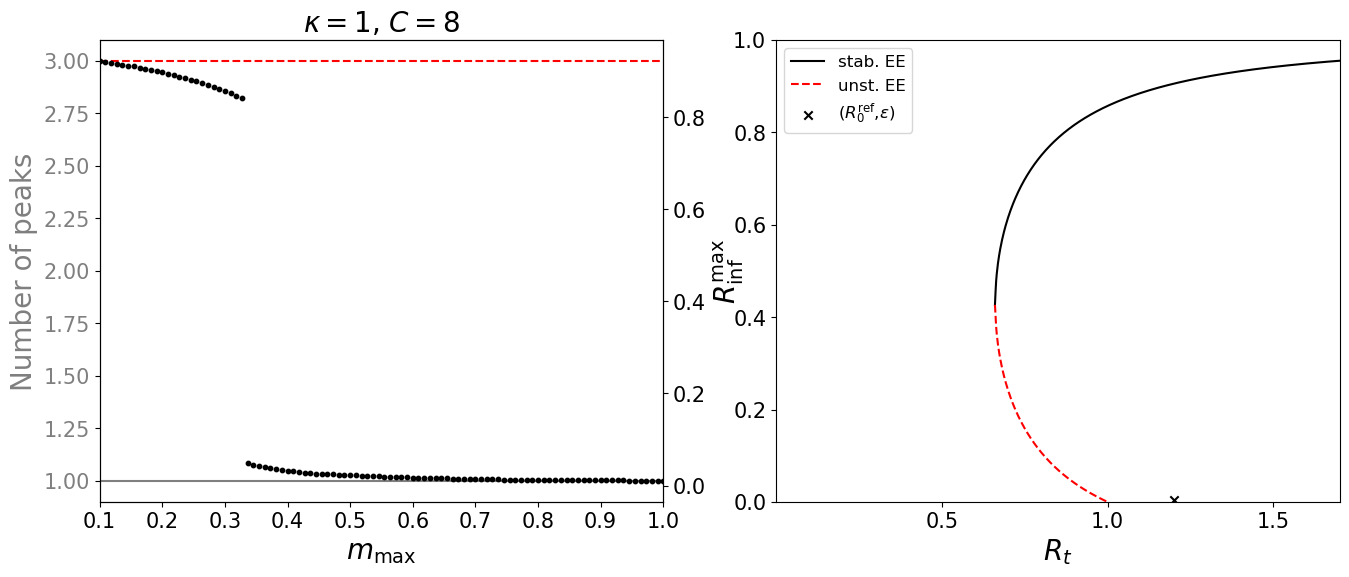

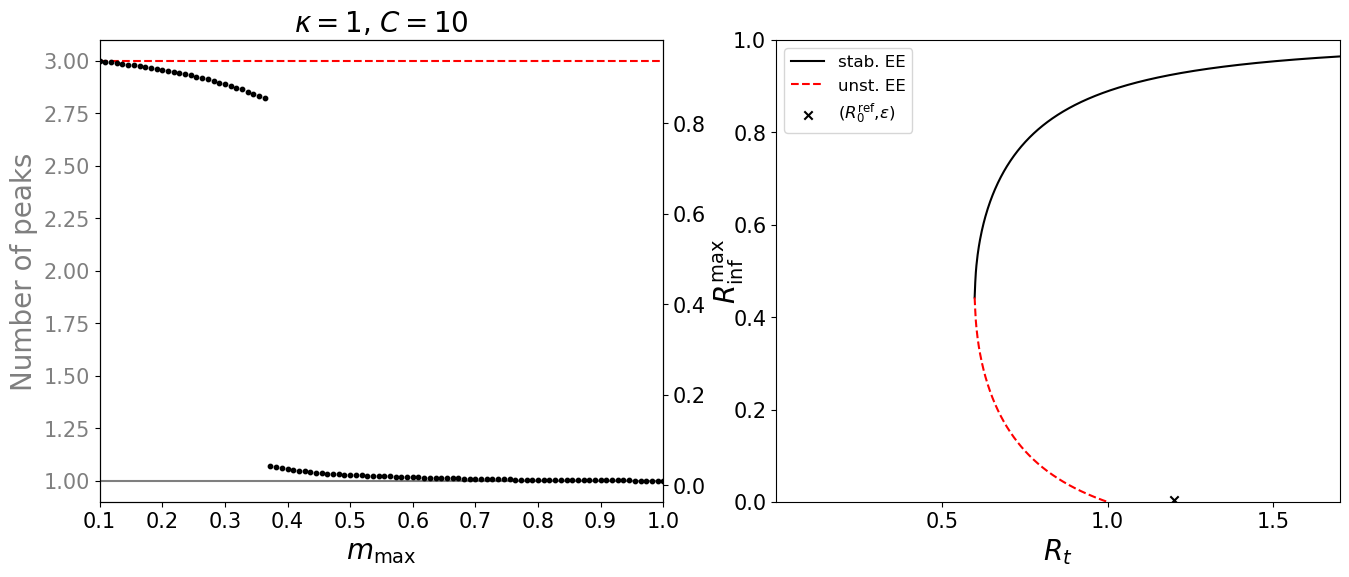

Finished mmax=0.2
Finished mmax=0.8


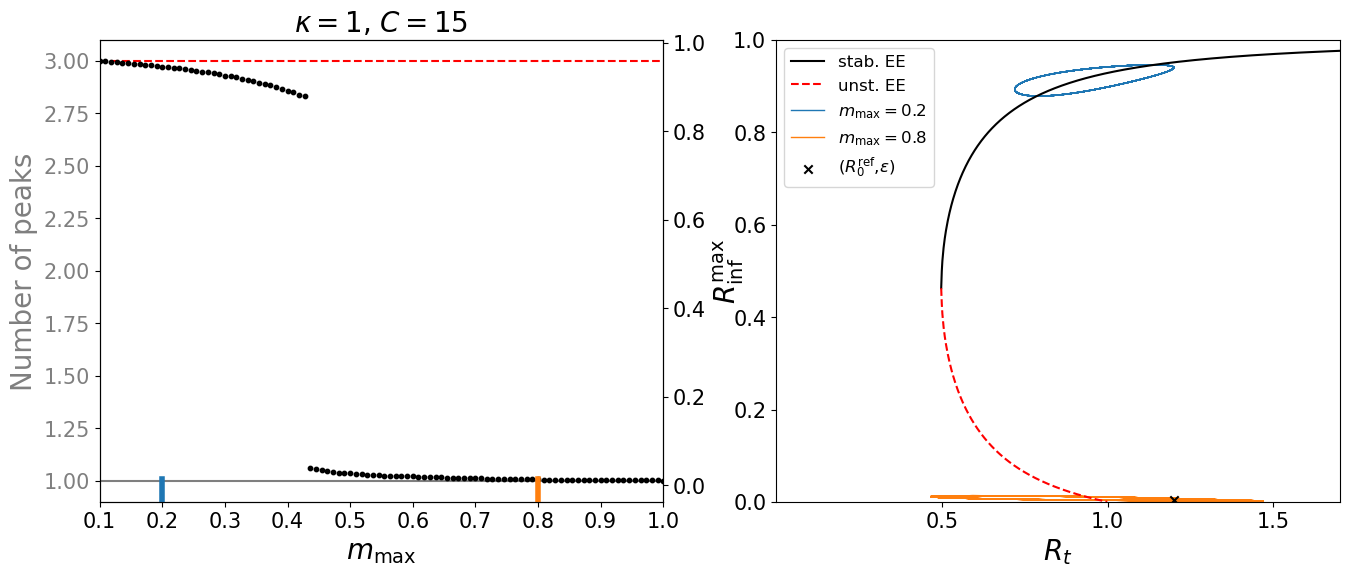

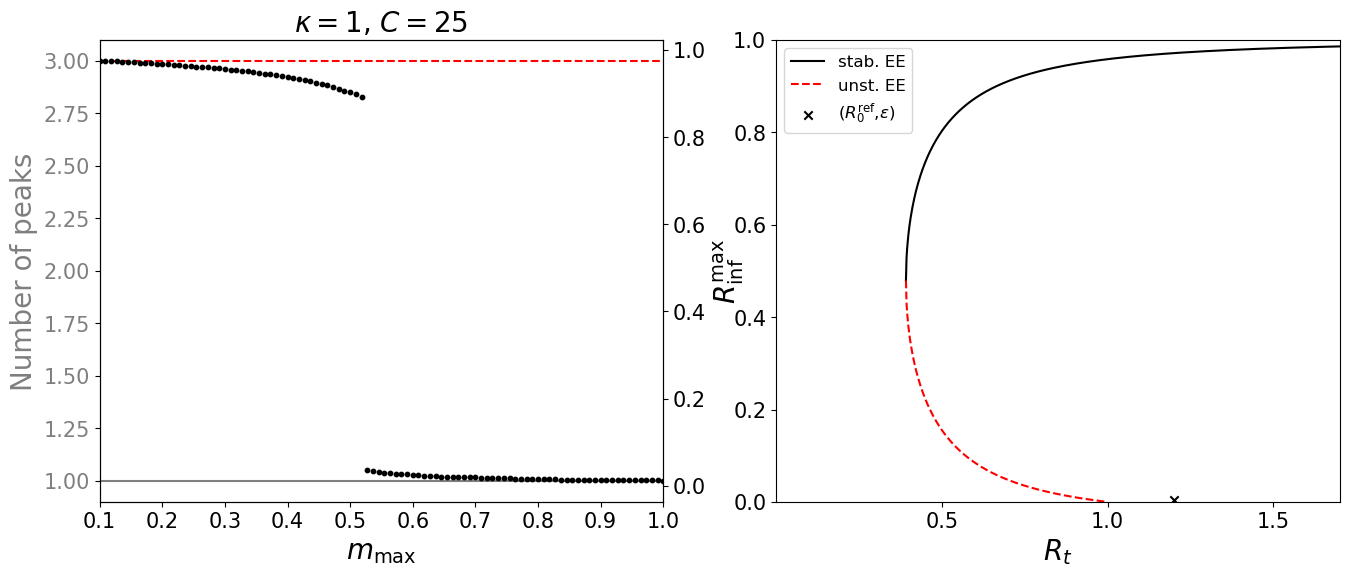

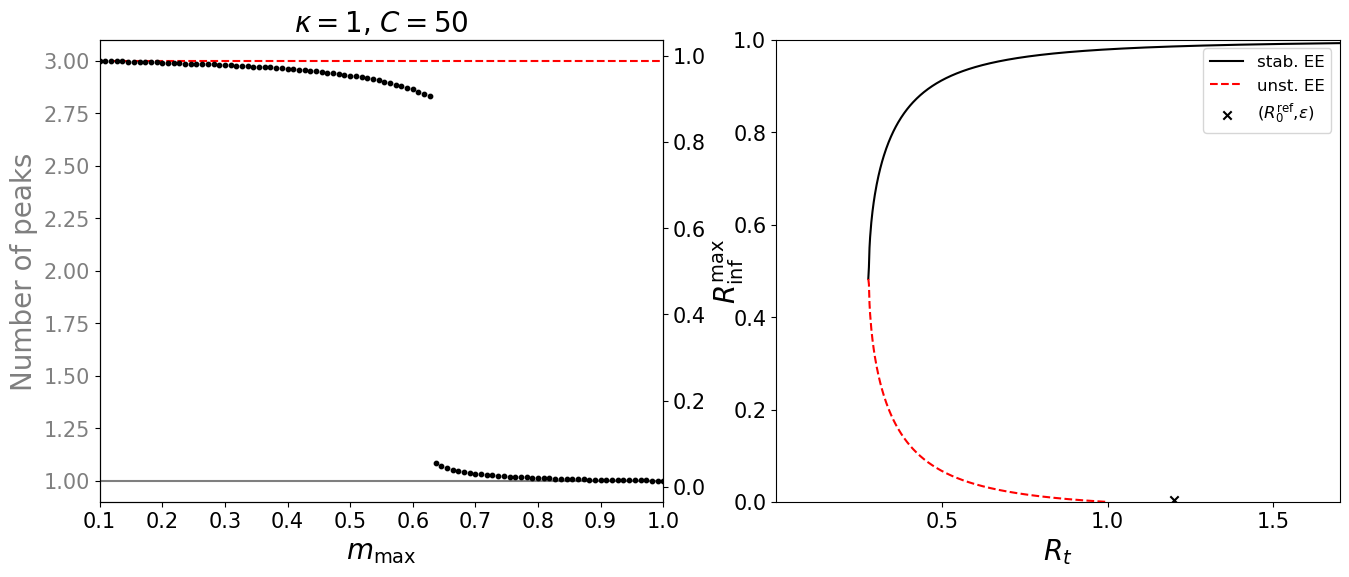

Finished mmax=0.2
Finished mmax=0.8


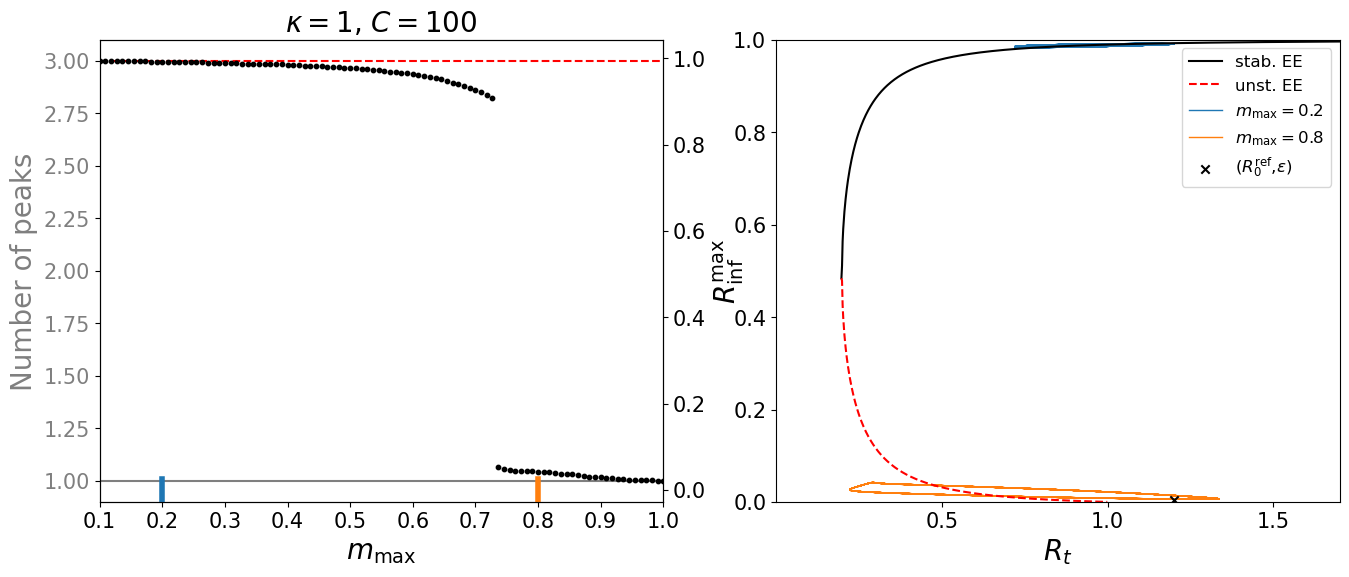

In [ ]:
# New thresh=e-3

fraction = [0.2,0.3,0.35,0.4,1] # add fractions after they have been simulated

mmax_list = [[[.2,.5,.61,.9], [.2,.5,.6,.9], [0.2,0.4,0.55,0.7,1], [None],    [0.2,0.5,0.7], [.4,.6,.7,.9], [.4,.75,.9,.95], [.6,.85,.95], [.6,.85,.9,.92]],
            [[.2,.7,.9],     [None],         [0.2,0.4,0.58,0.64,1], [None], [.3,.5,.6,.7],   [.4,.6,.7,.97], [.4,.67,.8,.9], [.78,.95],    [.86,.9,1]],
            [[.2,.7,.9],     [.9],           [0.2,.23,.3,0.4],             [None], [.6,.8],         [.4,.6,.7,.97], [.4,.67,.8,.9], [.6,.78,.95], [.6,.86,.9,1]],
            [[.2,.5,.7,.9], [.2,.5,.7,.87,.9], [0.2,0.4,0.58,0.64,1], [None], [.4,.46,.5,.55], [.4,.6,.7,.97], [.4,.67,.8,.9], [.6,.78,.95], [.6,.86,.9,1]],
            [[.2,.8],       [None],            [None],                [None], [None],          [.2,.8],        [None,None],    [None,None], [.2,.8]]
             ]

ChaosThresh = [18,13,11,9,3]
# values for 0.35 and 0.4 preliminary (set to the same as for 0.3)

COL = plt.rcParams['axes.prop_cycle'].by_key()['color'][:]
color_leftaxis = 'tab:grey'

for k in range(len(fraction)):
    #if(fraction[k] != 0.35): continue
    Peakcounter = np.load(f'Data_PDOnset/DataSIRSsm_Peakcounter_kappa={fraction[k]}_thresh=e-3_tmax=200yrs.npy')
    
    for i,C in enumerate(C_values):
        #if (C != 5): continue
        fig, ax = plt.subplots(1, 2, figsize=(16, 6))

        Peaks = np.load(f'Data_PDOnset/DataSIRSsm_Peaks_kappa={fraction[k]}_C={C}_thresh=e-3_tmax=200yrs.npy')
        ax[0].plot(mmax_values, Peakcounter[i,:], label=f'C={C}',c=color_leftaxis)
        ax[0].axhline(y=ChaosThresh[k],c='r', ls='--')
        ax[0].set_title(rf'$\kappa=${fraction[k]}, $C=${C}')
        ax[0].set_xlabel(r'$m_{\rm max}$')
        ax[0].set_ylabel('Number of peaks', c=color_leftaxis)
        ax[0].tick_params(axis='y', labelcolor=color_leftaxis)
        ax[0].set_xlim(mmax_values[0], mmax_values[-1])

        ax2 = ax[0].twinx()
        ax2.scatter(Peaks[:,:,0], Peaks[:,:,1], label=f'C={C}', c='k', s=10)
        ax2.set_ylabel(r'$R_{\rm inf}^{\rm max}$')

        for mmax_idx, mmax in enumerate(mmax_list[k][i]): 
            if(mmax!=None): ax2.axvline(x=mmax, ymin=-.05, ymax=.05, c=COL[mmax_idx], lw=4)
        PlotTrajectories(ax[1], p, mmax_list[k][i], fraction[k], C)
        plt.show()

Finished mmax=0.2
Finished mmax=0.23
Finished mmax=0.3
Finished mmax=0.4


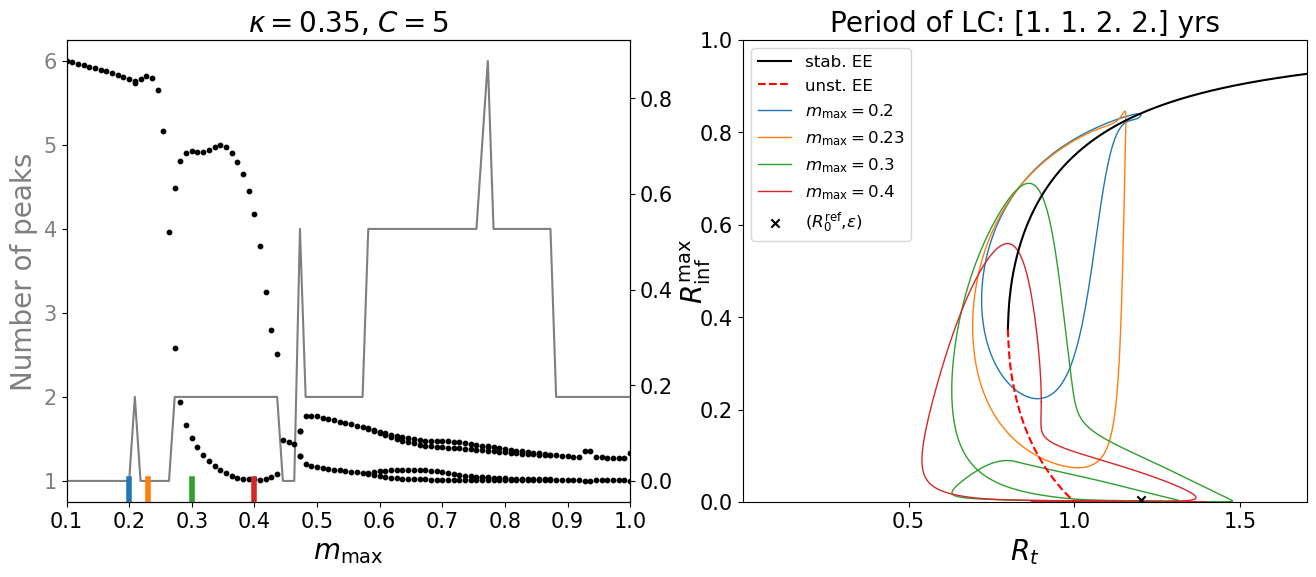

Finished mmax=0.4


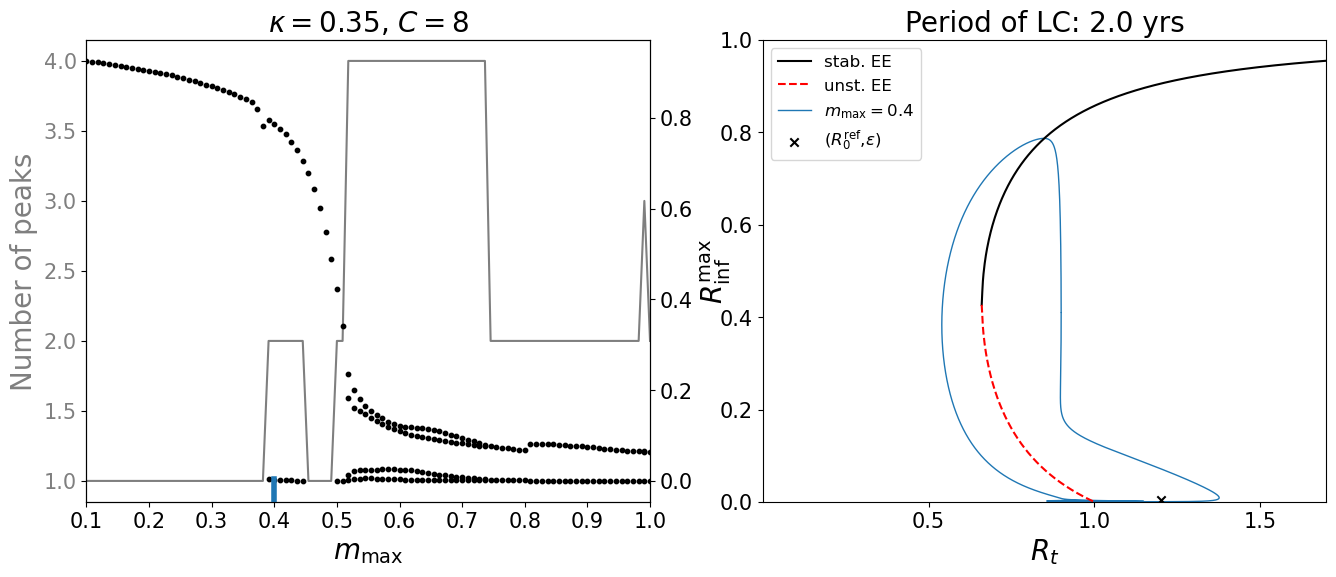

Finished mmax=0.5


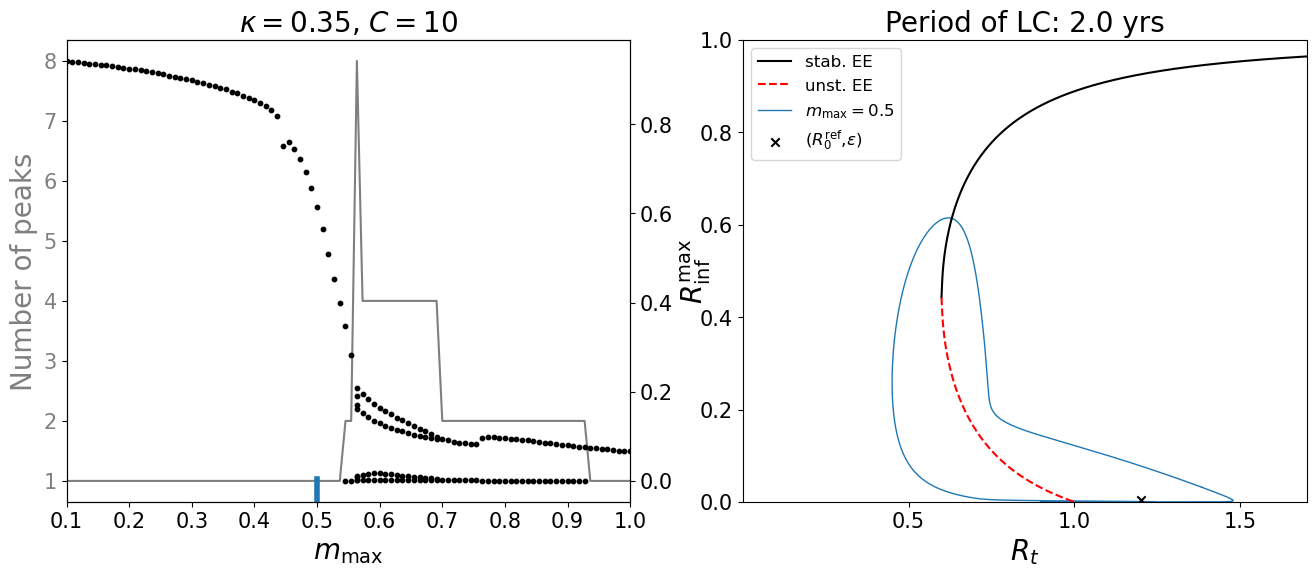

Finished mmax=0.6


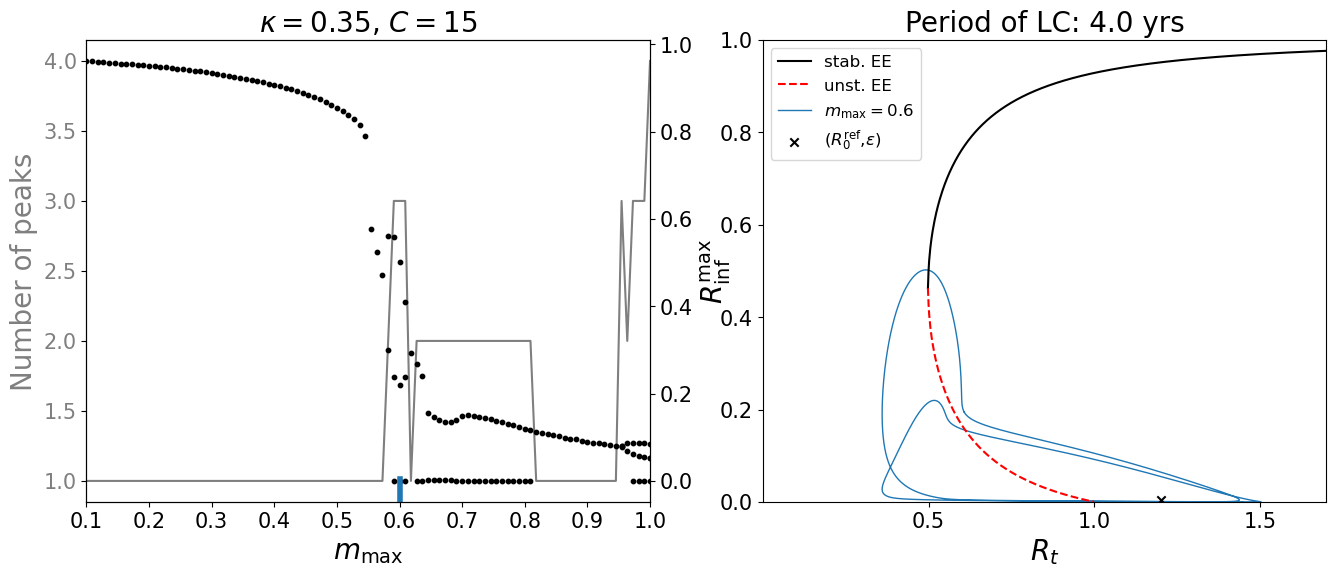

In [ ]:
# Check periods after splittings (New thresh=e-3)

fraction = [0.35] # add fractions after they have been simulated
C_values_red = [5,8,10,15]

mmax_list = [
            [[0.2,.23,.3,0.4], [0.4], [.5], [.6]],
             ]

tmax = 40*360
LCPeriod = [np.array([360,360,2*360,2*360]),2*360,2*360,4*360]

COL = plt.rcParams['axes.prop_cycle'].by_key()['color'][:]
color_leftaxis = 'tab:grey'

for k in range(len(fraction)):
    Peakcounter = np.load(f'Data_PDOnset/DataSIRSsm_Peakcounter_kappa={fraction[k]}_thresh=e-3_tmax=200yrs.npy')
    
    for i,C in enumerate(C_values_red):
        fig, ax = plt.subplots(1, 2, figsize=(16, 6))

        Peaks = np.load(f'Data_PDOnset/DataSIRSsm_Peaks_kappa={fraction[k]}_C={C}_thresh=e-3_tmax=200yrs.npy')

        C_values_idx = np.where(np.array(C_values) == C)[0][0]
        ax[0].plot(mmax_values, Peakcounter[C_values_idx,:], label=f'C={C}',c=color_leftaxis)
        ax[0].set_title(rf'$\kappa=${fraction[k]}, $C=${C}')
        ax[0].set_xlabel(r'$m_{\rm max}$')
        ax[0].set_ylabel('Number of peaks', c=color_leftaxis)
        ax[0].tick_params(axis='y', labelcolor=color_leftaxis)
        ax[0].set_xlim(mmax_values[0], mmax_values[-1])

        ax2 = ax[0].twinx()
        ax2.scatter(Peaks[:,:,0], Peaks[:,:,1], label=f'C={C}', c='k', s=10)
        ax2.set_ylabel(r'$R_{\rm inf}^{\rm max}$')

        for mmax_idx, mmax in enumerate(mmax_list[k][i]): 
            if(mmax!=None): ax2.axvline(x=mmax, ymin=-.05, ymax=.05, c=COL[mmax_idx], lw=4)
        PlotTrajectories(ax[1], p, mmax_list[k][i], fraction[k], C, tmax=tmax, cut_input=(tmax-LCPeriod[i])/p['stepsize'])
        ax[1].set_title(rf'Period of LC: {LCPeriod[i]/360} yrs')
        plt.show()

Finished mmax=0.9


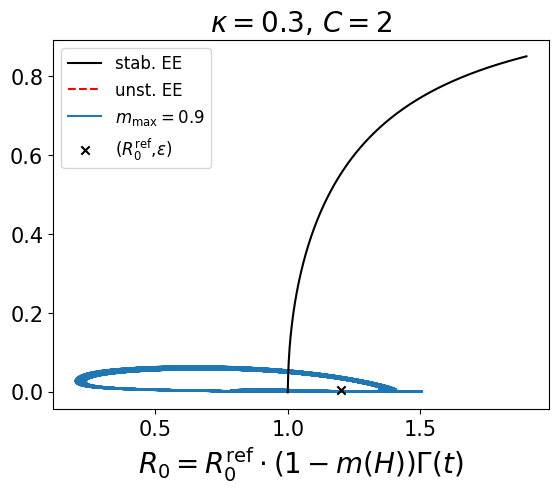

Finished mmax=0.92


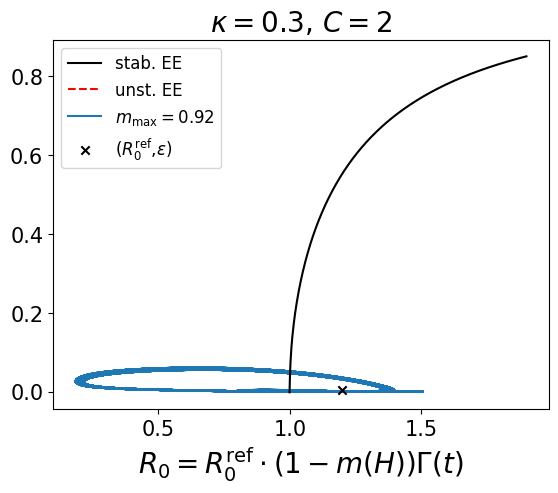

Finished mmax=0.73


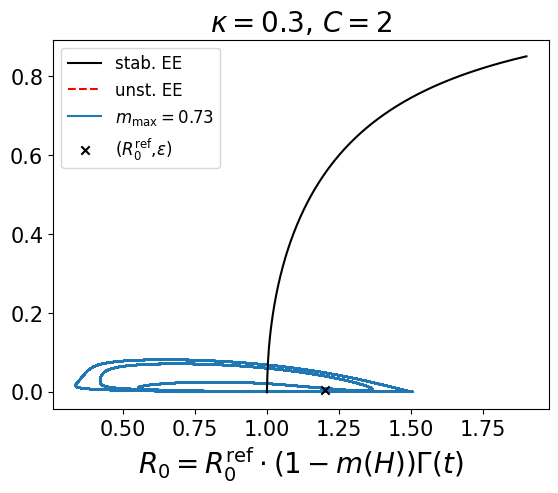

Finished mmax=0.64


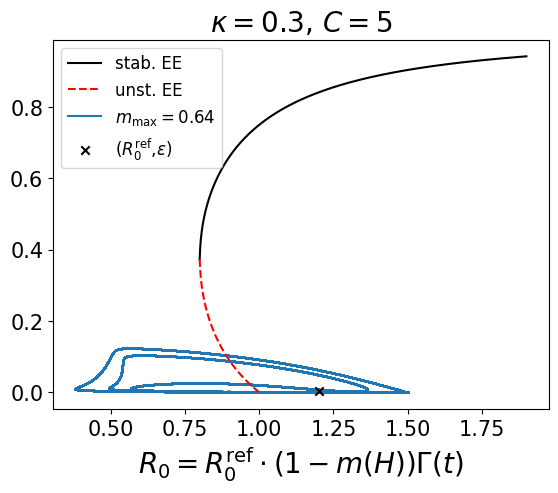

In [81]:
plt.show()
PlotTrajectories(plt.gca(), p, [.73], .3, 2, tmax=300*360)
plt.show()
PlotTrajectories(plt.gca(), p, [.64], .3, 5, tmax=300*360)
plt.show()

Finished mmax=0.87


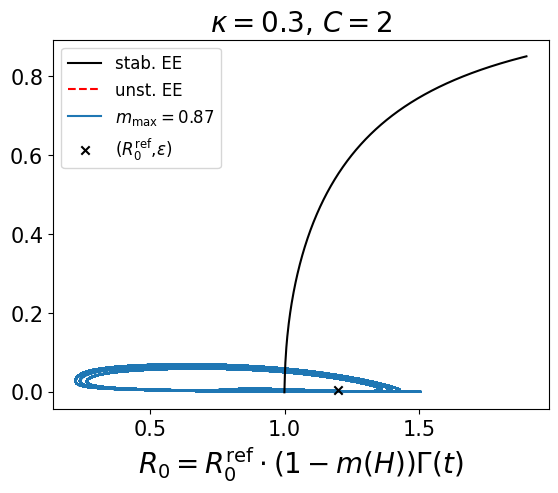

Finished mmax=0.9


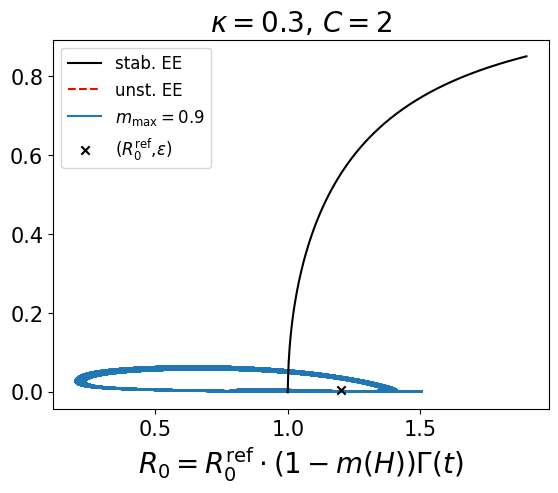

Finished mmax=0.92


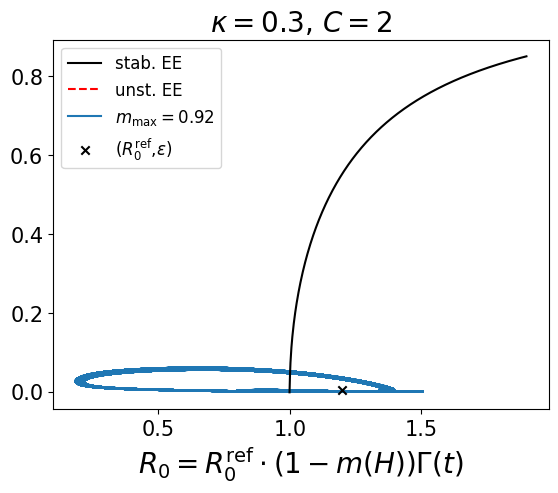

In [83]:
plt.show()
PlotTrajectories(plt.gca(), p, [.87], .3, 2, tmax=1000*360)
plt.show()
PlotTrajectories(plt.gca(), p, [.9], .3, 2, tmax=1000*360)
plt.show()
PlotTrajectories(plt.gca(), p, [.92], .3, 2, tmax=1000*360)
plt.show()

tolerances lowered for kappa = 0.3 and mmax = 0.9545454545454545


C:\Users\Rodrigo Amaral Lind\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\integrate\_ivp\ivp.py:621: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


tolerances lowered for kappa = 0.3 and mmax = 0.9636363636363636
tolerances lowered for kappa = 0.3 and mmax = 0.9727272727272727
tolerances lowered for kappa = 0.3 and mmax = 0.9818181818181817
tolerances lowered for kappa = 0.3 and mmax = 0.9909090909090909
tolerances lowered for kappa = 0.3 and mmax = 1.0
1 / 2
tolerances lowered for kappa = 0.3 and mmax = 0.9545454545454545
tolerances lowered for kappa = 0.3 and mmax = 0.9636363636363636
tolerances lowered for kappa = 0.3 and mmax = 0.9727272727272727
tolerances lowered for kappa = 0.3 and mmax = 0.9818181818181817
tolerances lowered for kappa = 0.3 and mmax = 0.9909090909090909
tolerances lowered for kappa = 0.3 and mmax = 1.0
2 / 2
>>> 1 / 1
Finished mmax=0.2
Finished mmax=0.5
Finished mmax=0.7
Finished mmax=0.9


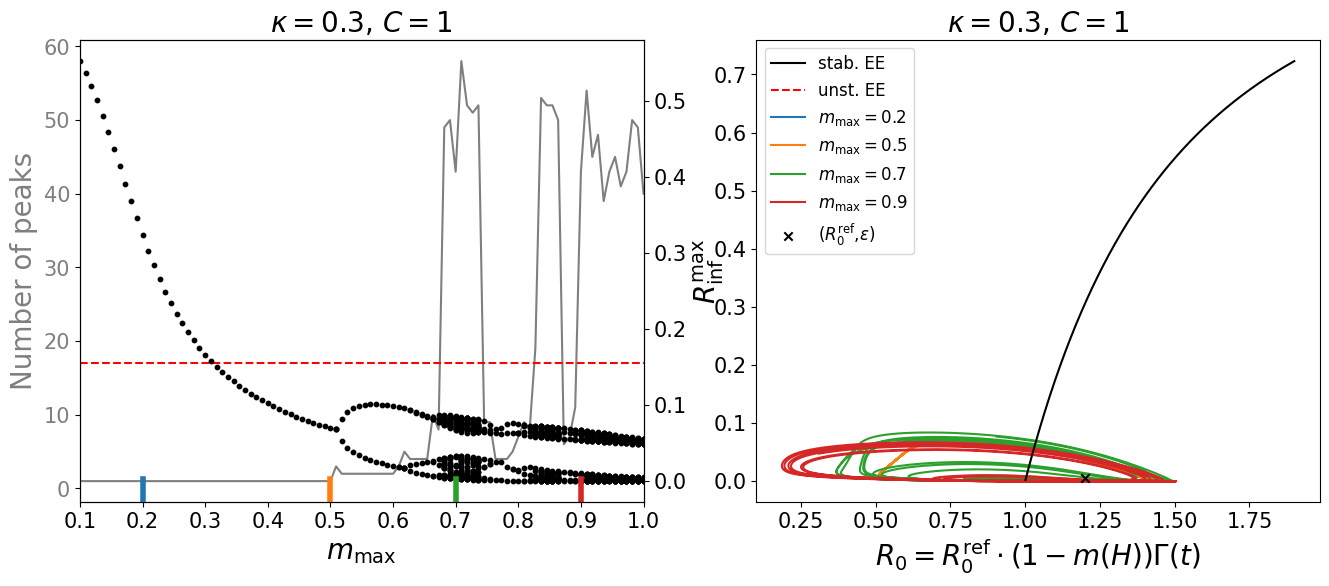

Finished mmax=0.2
Finished mmax=0.5
Finished mmax=0.7
Finished mmax=0.87
Finished mmax=0.9


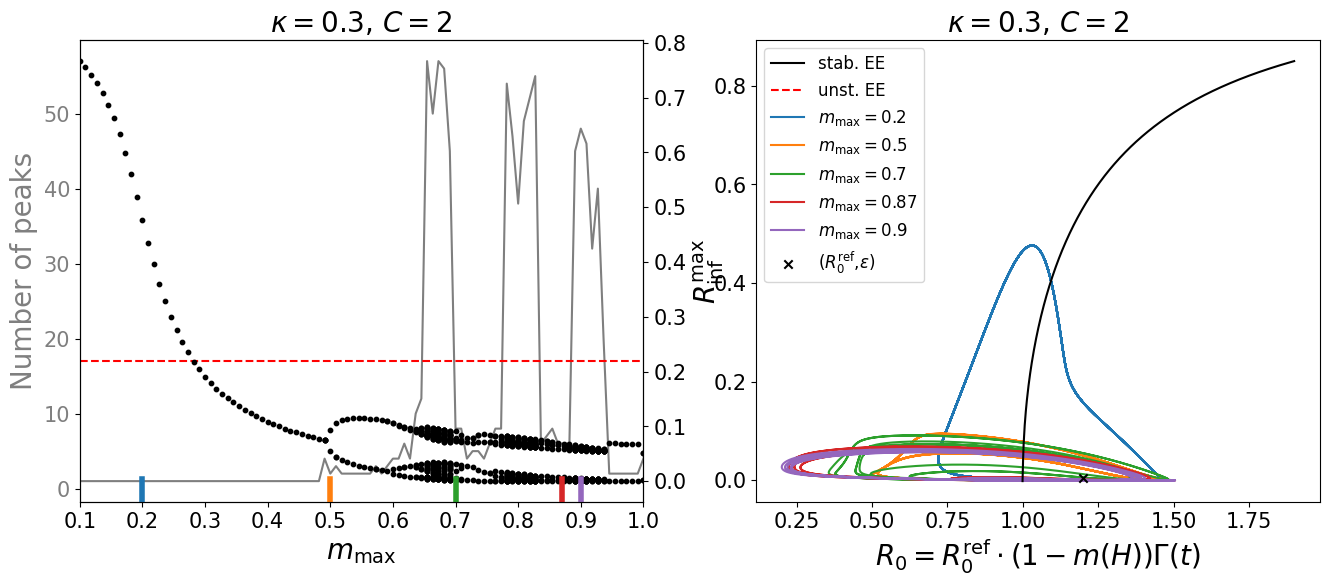

In [ ]:
fraction = [0.3]
C_values_ = [1,2]
mmax_values = np.linspace(0.1,1,100)
FindPDOnsets(fraction, C_values_, mmax_values, p, tmax=200*360)

mmax_list = [
            [[.2,.5,.7,.9], [.2,.5,.7,.87,.9]]
             ]

ChaosThresh = 17

COL = plt.rcParams['axes.prop_cycle'].by_key()['color'][:]
color_leftaxis = 'tab:grey'

for k in range(len(fraction)):
    Peakcounter = np.load(f'Data_PDOnset/DataSIRSsm_Peakcounter_kappa={fraction[k]}_thresh=e-4_tmax=200yrs_only2Cs.npy')
    
    for i,C in enumerate(C_values_):
        fig, ax = plt.subplots(1, 2, figsize=(16, 6))

        Peaks = np.load(f'Data_PDOnset/DataSIRSsm_Peaks_kappa={fraction[k]}_C={C}_thresh=e-4_tmax=200yrs_only2Cs.npy')
        ax[0].plot(mmax_values, Peakcounter[i,:], label=f'C={C}',c=color_leftaxis)
        ax[0].axhline(y=ChaosThresh,c='r', ls='--')
        ax[0].set_title(rf'$\kappa=${fraction[k]}, $C=${C}')
        ax[0].set_xlabel(r'$m_{\rm max}$')
        ax[0].set_ylabel('Number of peaks', c=color_leftaxis)
        ax[0].tick_params(axis='y', labelcolor=color_leftaxis)
        ax[0].set_xlim(mmax_values[0], mmax_values[-1])

        ax2 = ax[0].twinx()
        ax2.scatter(Peaks[:,:,0], Peaks[:,:,1], label=f'C={C}', c='k', s=10)
        ax2.set_ylabel(r'$R_{\rm inf}^{\rm max}$')

        for mmax_idx, mmax in enumerate(mmax_list[k][i]): 
            if(mmax!=None): ax2.axvline(x=mmax, ymin=-.05, ymax=.05, c=COL[mmax_idx], lw=4)
        PlotTrajectories(ax[1], p, mmax_list[k][i], fraction[k], C)
        plt.show()

#### Examples For Paper:

Finished mmax=0.2
Finished mmax=0.47
Finished mmax=0.6
tolerances lowered for kappa = 0.2 and mmax = 0.9


c:\Users\PCUser\miniconda3\envs\MYENV\Lib\site-packages\scipy\integrate\_ivp\ivp.py:623: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


Finished mmax=0.9


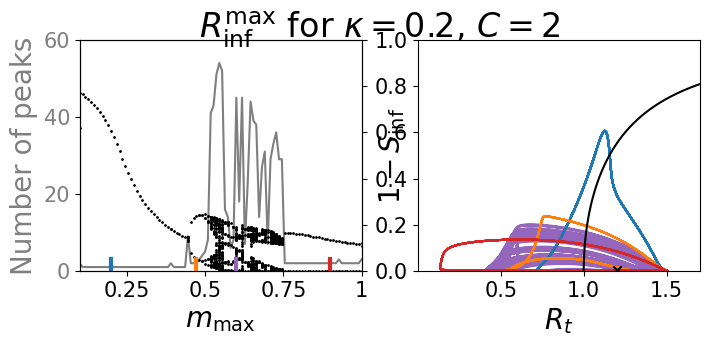

Finished mmax=0.15
Finished mmax=0.58
tolerances lowered for kappa = 0.2 and mmax = 0.98


c:\Users\PCUser\miniconda3\envs\MYENV\Lib\site-packages\scipy\integrate\_ivp\ivp.py:623: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


at mmax= 0.98 ERROR: Solver stopped due to negative population.
Trying longer tmax=520.0 yrs instead...
Finished mmax=0.98


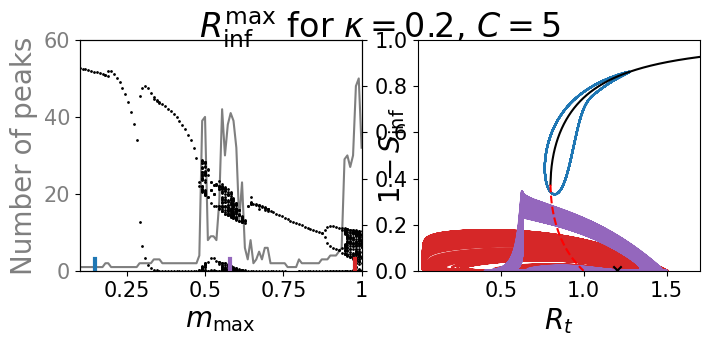

Finished mmax=0.4
Finished mmax=0.6
tolerances lowered for kappa = 0.2 and mmax = 0.75


c:\Users\PCUser\miniconda3\envs\MYENV\Lib\site-packages\scipy\integrate\_ivp\ivp.py:623: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


Finished mmax=0.75
tolerances lowered for kappa = 0.2 and mmax = 0.8
Finished mmax=0.8


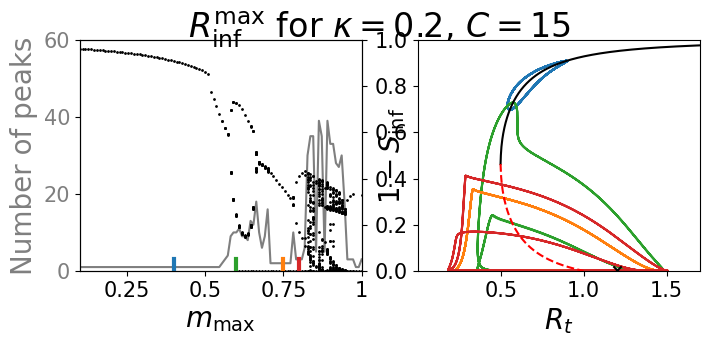

Finished mmax=0.4
tolerances lowered for kappa = 0.2 and mmax = 0.75


c:\Users\PCUser\miniconda3\envs\MYENV\Lib\site-packages\scipy\integrate\_ivp\ivp.py:623: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


Finished mmax=0.75
tolerances lowered for kappa = 0.2 and mmax = 0.8
Finished mmax=0.8


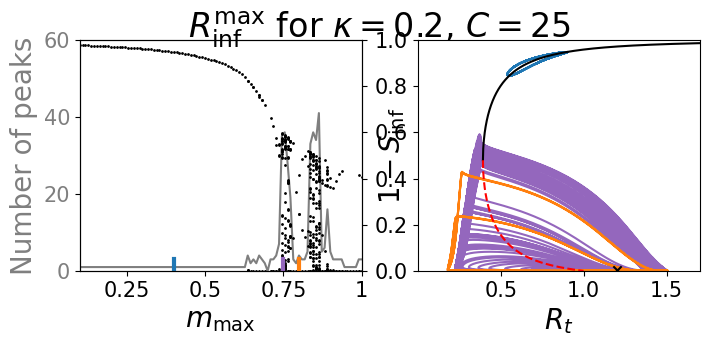

Finished mmax=0.8
Finished mmax=0.9


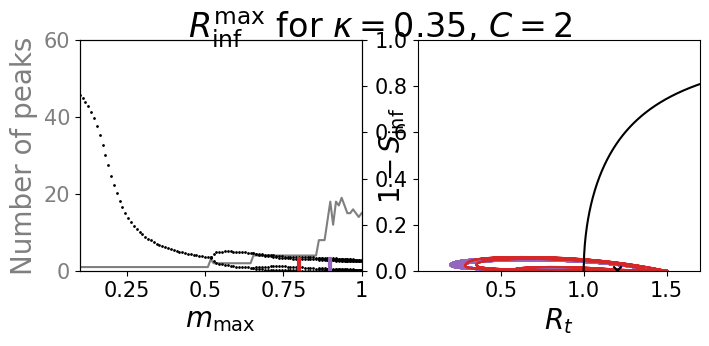

Finished mmax=0.3
Finished mmax=0.4


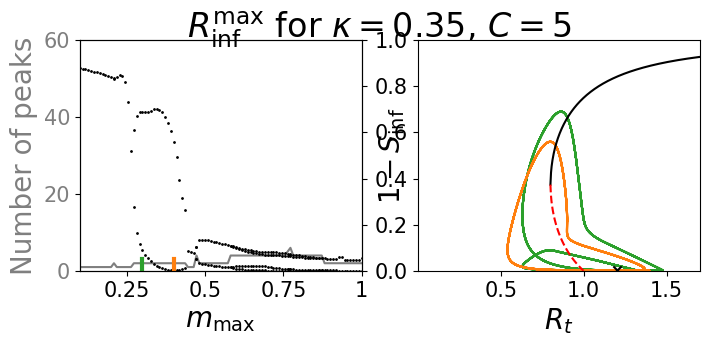

Finished mmax=0.4
Finished mmax=0.55
Finished mmax=0.6
Finished mmax=0.7


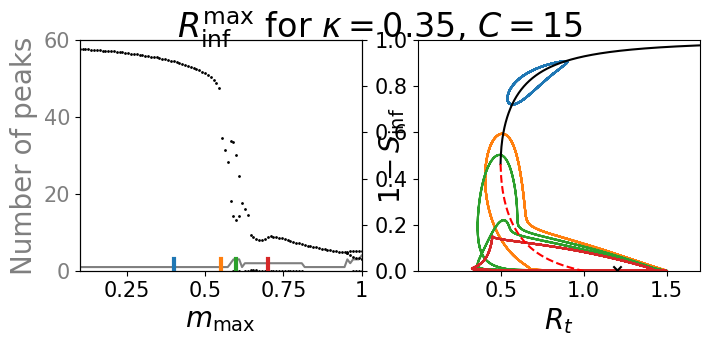

Finished mmax=0.655
Finished mmax=0.67


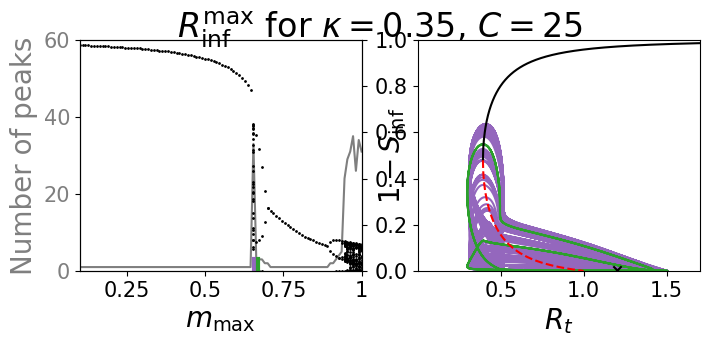

In [21]:
C_values = [1,2,5,15,25,50,100]

fraction = [0.2,0.2,0.2,0.2,0.35,0.35,.35,.35]
C_values_toplot = [2,5,15,25,2,5,15,25]
mmax_values = np.linspace(0.1,1,100)

TMAX_list = [[40*360,40*360,500*360,40*360], [40*360,500*360,500*360],  [40*360,40*360,40*360,40*360], [40*360,500*360,40*360], [40*360,500*360], [40*360,40*360], [40*360,40*360,40*360,40*360], [500*360,40*360]]
mmax_list = [[.2,.47,.6,.9], [.15,.58,.98], [.4,.6,.75,.8], [.4,.75,.8], [.8,.9], [.3,.4], [.4,.55,.6,.7], [.655,.67]]
COL_list = [['tab:blue','tab:orange','tab:purple','tab:red'], ['tab:blue','tab:purple','tab:red'], ['tab:blue','tab:green','tab:orange','tab:red'], ['tab:blue','tab:purple','tab:orange'], ['tab:red','tab:purple'], ['tab:green','tab:orange'], ['tab:blue','tab:orange','tab:green','tab:red'], ['tab:purple','tab:green']]

# ChaosThresh = 17

COL = plt.rcParams['axes.prop_cycle'].by_key()['color'][:]
color_leftaxis = 'tab:grey'

for i_toplot,C in enumerate(C_values_toplot):
    #if(i_toplot != 7): continue
    k = i_toplot
    i = C_values.index(C)

    Peakcounter = np.load(f'Data_PDOnset/DataSIRSsm_Peakcounter_kappa={fraction[k]}_thresh=e-3_tmax=200yrs.npy')
    Peaks = np.load(f'Data_PDOnset/DataSIRSsm_Peaks_kappa={fraction[k]}_C={C}_thresh=e-3_tmax=200yrs.npy')
    
    fig, ax = plt.subplots(1, 2, figsize=(8, 3))
    ax[0].plot(mmax_values, Peakcounter[i,:], label=f'C={C}',c=color_leftaxis)
    #ax[0].axhline(y=ChaosThresh,c='r', ls='--')
    fig.suptitle(r'$R_{\rm inf}^{\rm max}$'+rf' for $\kappa=${fraction[k]}, $C=${C}')
    ax[0].set_xlabel(r'$m_{\rm max}$')
    ax[0].set_ylabel('Number of peaks', c=color_leftaxis)
    ax[0].tick_params(axis='y', labelcolor=color_leftaxis)
    ax[0].set_xlim(mmax_values[0], mmax_values[-1])
    ax[0].set_ylim(0, 60)
    ax[0].set_xticks([0.25,0.5,0.75,1],labels=['0.25','0.5','0.75','1'])

    ax2 = ax[0].twinx()
    ax2.scatter(Peaks[:,:,0], Peaks[:,:,1], label=f'C={C}', c='k', s=1)
    ax2.set_ylabel(r'$1-S_{\rm inf}$') # ^{\rm max}
    ax2.set_ylim(0,1)
    ax2.set_yticklabels([])

    for mmax_idx, mmax in enumerate(mmax_list[i_toplot]): 
        if(mmax!=None): ax2.axvline(x=mmax, ymin=-.05, ymax=.05, c=COL_list[i_toplot][mmax_idx], lw=3)

    PlotTrajectories(ax[1], p, mmax_list[i_toplot], fraction[k], C, tmax=TMAX_list[i_toplot], LEGEND=False, COL_list=COL_list[i_toplot])
    plt.savefig(f'img/SIRSsm_ExampleForPaper_Peaks_kappa={fraction[k]}_C={C}_thresh=e-3_tmax=200yrs.pdf')
    plt.show()

### Parameter Space plot mmax vs C

In [26]:
fraction = [0.2,0.25,0.3,0.35]
C_values = np.logspace(-1,2,100)
mmax_values = np.linspace(0.1,1,100)
tmax = 200*360
ChaosThresh = [20,18,13,11]

In [27]:
Peakcounter, Peaks_trimmed = FindPDOnsets(fraction, C_values, mmax_values, p, tmax=tmax, HeatmapLabel=True)

Found existing data for kappa= 0.2 , C= 0.1
1 / 100
Found existing data for kappa= 0.2 , C= 0.10722672220103231
2 / 100
Found existing data for kappa= 0.2 , C= 0.11497569953977356
3 / 100
Found existing data for kappa= 0.2 , C= 0.12328467394420663
4 / 100
Found existing data for kappa= 0.2 , C= 0.1321941148466029
5 / 100
Found existing data for kappa= 0.2 , C= 0.1417474162926805
6 / 100
Found existing data for kappa= 0.2 , C= 0.1519911082952934
7 / 100
Found existing data for kappa= 0.2 , C= 0.16297508346206444
8 / 100
Found existing data for kappa= 0.2 , C= 0.17475284000076838
9 / 100
Found existing data for kappa= 0.2 , C= 0.1873817422860384
10 / 100
Found existing data for kappa= 0.2 , C= 0.20092330025650468
11 / 100
Found existing data for kappa= 0.2 , C= 0.2154434690031884
12 / 100
Found existing data for kappa= 0.2 , C= 0.23101297000831597
13 / 100
Found existing data for kappa= 0.2 , C= 0.24770763559917108
14 / 100
Found existing data for kappa= 0.2 , C= 0.26560877829466867
15 /

kappa=0.2:
Peakcounter max: 124.0
Peakcounter second max: 83.0
Peakcounter first max: 124.0


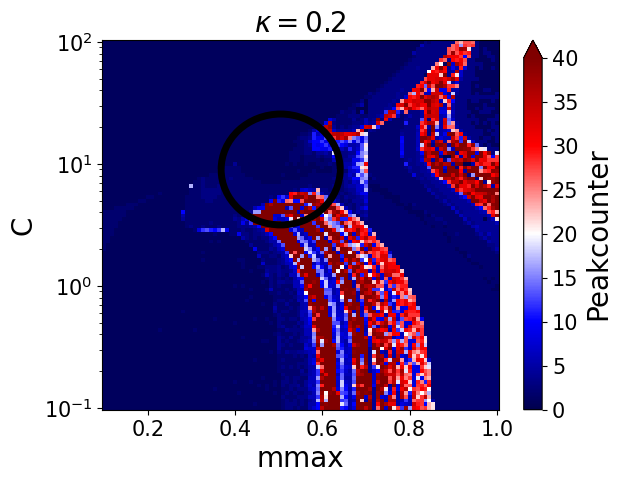

kappa=0.25:
Peakcounter max: 69.0
Peakcounter second max: 59.0
Peakcounter first max: 69.0


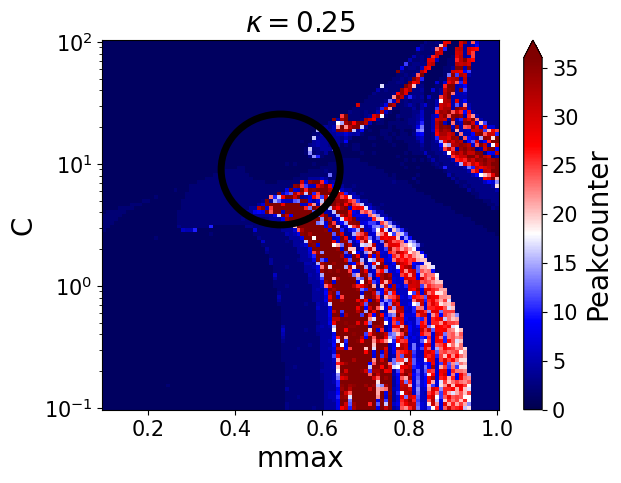

kappa=0.3:
Peakcounter max: 46.0
Peakcounter second max: 45.0
Peakcounter first max: 46.0


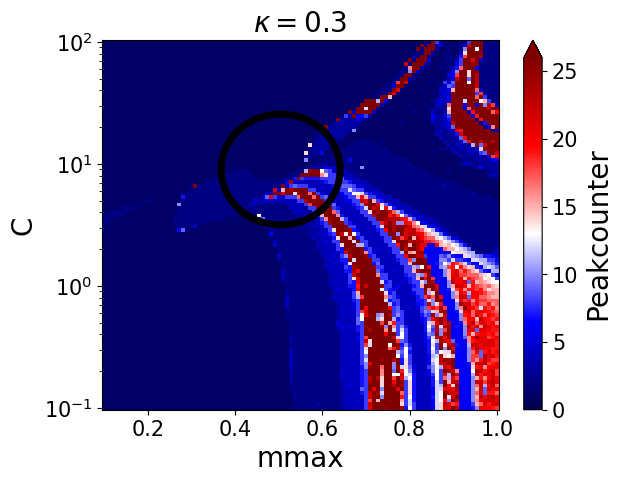

kappa=0.35:
Peakcounter max: 40.0
Peakcounter second max: 38.0
Peakcounter first max: 40.0


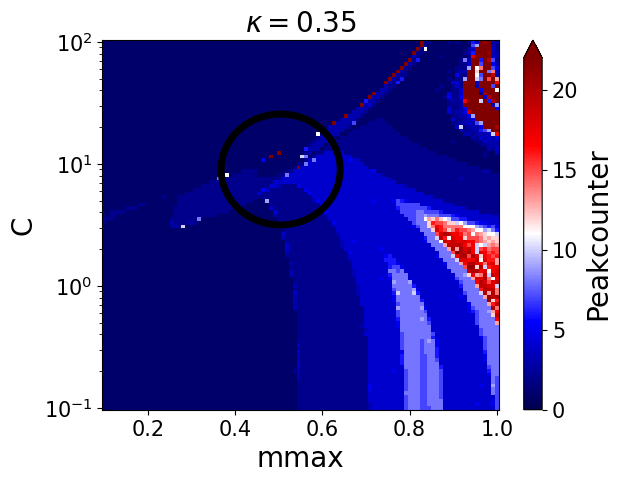

In [37]:
for k in range(len(fraction)):

    Peakcounter = np.load(f"Data_PDOnset/DataSIRSsm_PeakcounterHeatmap_kappa={fraction[k]}_thresh=e-3_tmax=200yrs.npy")
    #print(fraction[k],Peakcounter)
    Peakcounter_max = np.max(Peakcounter.flatten())
    # second max
    Peakcounter_second_max = np.partition(Peakcounter.flatten(), -2)[-2]
    Peakcounter_first_max = np.partition(Peakcounter.flatten(), -1)[-1]

    print(f"kappa={fraction[k]}:")
    print("Peakcounter max:", Peakcounter_max)
    print("Peakcounter second max:", Peakcounter_second_max)
    print("Peakcounter first max:", Peakcounter_first_max)

    plt.pcolormesh(mmax_values, C_values, Peakcounter, shading='auto', cmap='seismic')
    # put colobarmax at second max 84, middle at 20 and bottom at 0
    plt.clim(vmin=0, vmax=ChaosThresh[k]*2)

    ax = plt.gca()
    circle = plt.Circle((0.45, 0.65), radius=0.15, transform=ax.transAxes, fill=False, color='k', lw=5)
    ax.add_patch(circle)

    plt.yscale('log')
    plt.xlabel('mmax')
    plt.ylabel('C')
    plt.title(fr'$\kappa=${fraction[k]}')

    cbar = plt.colorbar(label='Peakcounter', extend='max')
    plt.savefig(f'img/Peakcounter_heatmap_kappa={fraction[k]}_thresh=e-3_tmax=200yrs.pdf', bbox_inches='tight')
    plt.show()